# Same-day-expiry nearest-out-of-the-money call and put, 15:30 → 16:00

One trade per expiration day. At 15:30 ET the **straddle** is the pair of
**nearest out-of-the-money** legs, bought or sold together as one position:

- call: the smallest listed strike $K_c \ge S$ with a live midpoint quote
- put: the largest listed strike $K_p \le S$ with a live midpoint quote

When the index sits exactly on a strike the two legs share it (a true
straddle); otherwise the pair is one strike wide (strictly, a strangle).
The straddle is held to the close and settled in cash against the official
S&P 500 close (yfinance `^GSPC`): the call pays
$\max(S_{\mathrm{close}}-K_c,0)$ and the put pays
$\max(K_p-S_{\mathrm{close}},0)$.

The signal compares the forecast of realized variance over the final
half hour with the variance the option market quotes for that same
half hour, both in variance units:
$s=\widehat{RV}-(\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2})^2$, where
$\widehat{RV}=(m^2+\hat\sigma^2)B$ is the model's forecast mapped onto
the realized scale by a recalibration estimated from past data only
(§7). The position rules are scored on the same 866 days. The headline
is the **$\mathrm{sign}(s)$** portfolio, which sells the straddle when the market's
quoted variance exceeds the forecast and buys it when the forecast
exceeds the price: on the
block-diagonal ridge forecast — the ridge fitted on the FOMC panel, this
notebook's panel of record — it earns an annualized Sharpe ratio of
1.34 ($t = 2.48$). The **always-short** portfolio, which uses no
forecast, is the control, at a Sharpe ratio of 0.20.

The notebook runs as follows. Sections 1–6 build the instrument and its
return; §7 loads the variance forecasts and recalibrates them; §8 puts
the quoted implied volatility in the same units; §9 forms the signal and
the position; §10 tabulates the rules across the eight forecast
tables and tests each portfolio against the control day by day, then
compares the per-bar forecasts with their pooled twins as variance
forecasts and scores positions sized by the forecast gap instead of
$\pm1$;
§11 shifts the forecast in time to show the look-ahead cliff; §12 regresses the settlement return on the 15:30 signal; §13 adds up
the profit and loss; §14 is parked, its always-short comparison carried
by §10; §15 compounds each rule at a fixed 3% of wealth per day; §16 diagnoses the buy days; §17 asks whether the forecast needs more than the VIX;
§18 sets the trade's weight beside the S&P and shows what the trade's daily return moves with; §19 checks one row by hand. A
defined-risk variant (wings on the days the portfolio sells) is parked and
explored in the experimental notebook.

Volatility-scale views of the forecasts ($\hat y\sqrt{B}$, $m\sqrt{B}$)
are in `atm_straddle_volmap.ipynb` where present and otherwise in
`atm_straddle_experimental.ipynb`; ensembles and alternative weightings
are in `atm_straddle_experimental.ipynb`; the every-half-hour version of
this trade is in `atm_straddle_intraday.ipynb`.

Every cell reads from `data/` or from a table built by the cell before
it, and prints each table before using it.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import statsmodels.api as sm

def find_repo(start: Path) -> Path:
    for q in [start.resolve(), *start.resolve().parents]:
        if (q / "data" / "spxw_chain.parquet").exists():
            return q
    raise FileNotFoundError("repo root not found")

REPO = find_repo(Path.cwd())
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl   # the shared helpers: early-close filter, recalibration, rule rows, BSM inversion
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
# derived-input cache: every entry is keyed on the source file's
# size+mtime (and the request), so a changed input can never serve a
# stale hit. Delete the directory to force a cold rebuild.
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the option chain (15:30 and 16:00 ET only)

The source file, `data/spxw_chain.parquet`, holds a quote for every
30-minute time stamp. This trade needs only the 15:30 quotes, which are
the entry prices; the 16:00 rows are kept solely to compare the tape's
underlying price against the official close. The load therefore reads
the time stamps first, keeps those two Eastern times of day, and only
then loads the remaining columns for those rows.

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = [
    "expiration",
    "timestamp",
    "strike",
    "cp",
    "bid",
    "ask",
    "mid",
    "underlying_price",
    "impl_volatility",
    "hours_to_expiration",
]
_st = os.stat(path)
_ck = CACHE / f"chain_15301600v2_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
    print(f"cache hit {_ck.name} (source size+mtime matched; "
          "full-file stamp scan skipped)")
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[
        ((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))
    ].unique()
    print("unique timestamps in file", ts.nunique())
    print("15:30/16:00 ET stamps kept", len(keep))
    del ts, et
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    for _old in CACHE.glob("chain_15301600*.parquet"):
        _old.unlink()
    chain.to_parquet(_ck)
print("rows", f"{len(chain):,}")
print("columns", list(chain.columns))
print("timestamp", chain["timestamp"].min(), "->", chain["timestamp"].max())
print("expirations", chain["expiration"].nunique())
print(chain.head(3))


cache hit chain_15301600v2_80630573_1790200965970312800.parquet (source size+mtime matched; full-file stamp scan skipped)
rows 1,171,254
columns ['expiration', 'timestamp', 'strike', 'cp', 'bid', 'ask', 'mid', 'underlying_price', 'impl_volatility', 'hours_to_expiration']
timestamp 2020-01-03 20:30:00+00:00 -> 2025-12-31 21:00:00+00:00
expirations 1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility  hours_to_expiration
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000             0.500000
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000             0.000000
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000             0.500000


## 2. Times of day and the same-day-expiry flag

The vendor's time stamps are in UTC; the trading session runs on New
York time. A quote row is same-day expiry (0DTE) when the Eastern
calendar date of its time stamp equals the option's expiration date.
Every row in this file already is, so the flag is a check rather than
a filter; the count below confirms it.

In [3]:
# ~3M rows share ~4k unique stamps: convert clocks once per unique
# value and take() back, instead of per-row strftime/tz work.
codes, uts = pd.factorize(chain["timestamp"])
assert (codes >= 0).all(), "null timestamp in chain"
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where(
    (uet.hour == 15) & (uet.minute == 30), "15:30",
    np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"),
)
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
assert (ecodes >= 0).all(), "null expiration in chain"
uexp_d = (
    pd.DatetimeIndex(uexp)
    .tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT")
    .normalize()
)
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
print("0DTE rows", f"{int(chain['is_0dte'].sum()):,}", "/", f"{len(chain):,}")
print("ET hour counts on 0DTE:")
print(chain.loc[chain["is_0dte"], "et"].dt.hour.value_counts().sort_index().to_string())
print("15:30 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "15:30"), "timestamp"].nunique())
print("16:00 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "16:00"), "timestamp"].nunique())


0DTE rows 1,171,254 / 1,171,254
ET hour counts on 0DTE:
et
15    585627
16    585627
15:30 0DTE stamps 1291


16:00 0DTE stamps 1291


## 3. Keep only same-day-expiry rows at those two times

The 15:30 quote is the entry. The 16:00 rows serve only the
tape-versus-close check; settlement uses the official close from
yfinance (`^GSPC`), never a 16:00 option quote. The load already dropped
the other hours; the expiry flag passes every row, so this step only
keeps the two times of day. The file also carries an `early_close`
column, but it is set on every row and says nothing; the usable flag
for the twelve half sessions is the sign of the chain's hours to
expiration at 15:30, applied in §4.

In [4]:
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
print("rows", f"{len(book_chain):,}")
print(book_chain.groupby("hhmm").agg(rows=("strike", "size"), days=("expiration", "nunique"), stamps=("timestamp", "nunique")))
print(book_chain.head(3))
del chain


rows 1,171,254


         rows  days  stamps
hhmm                       
15:30  585627  1291    1291
16:00  585627  1291    1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility  hours_to_expiration  \
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000             0.500000   
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000             0.000000   
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000             0.500000   

                         et   hhmm                   et_date                  exp_date  is_0dte  
0 2020-01-03 15:30:00-05:00  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
1 2020-01-03 16:00:00-05:00  16:00 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     

## 4. Nearest out-of-the-money call and put at 15:30

The index level $S$ is the 15:30 print. Among quotes with a finite,
positive midpoint:

- call: the smallest strike $K_c \ge S$
- put: the largest strike $K_p \le S$

Twelve days in the file are half sessions: the market closed at 13:00
and the vendor carried the 13:00 quotes forward to a full grid, so
their "15:30" rows are post-close placeholders and the chain's own
hours-to-expiration is negative there. They are dropped first — the
same rule the intraday notebook applies — and listed; six of them fall
inside the forecast sample, and the five that carry a 16:00 forecast
row are the days this filter takes out of the scored frame (§7 names
them), while 2021-11-26, also a half session, has no 16:00 forecast row
and was never scored. The number of
days that then lose a leg is printed. The entry price is
$\mathrm{mid}(K_c) + \mathrm{mid}(K_p)$.

In [5]:
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
# half sessions: the market closed at 13:00 and the vendor carried the 13:00 quotes forward, so the
# 15:30 row sits after expiry (hours to expiration <= 0); the shared rule drops the day
half_days = asl.early_close_days(e)
print("half-session days dropped (15:30 row after the close):", len(half_days),
      [str(d.date()) for d in half_days])
e = e[~pd.to_datetime(e["expiration"]).dt.normalize().isin(half_days)].copy()
n_days = e["expiration"].nunique()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()
live["S"] = live["underlying_price"].astype(float)
spot = live.dropna(subset=["S"]).groupby("expiration")["S"].first()
print("15:30 0DTE days", n_days, "with a spot", int(spot.notna().sum()))
print("15:30 0DTE rows", f"{len(e):,}", "with finite mid>0", f"{len(live):,}",
      f"({len(live) / max(len(e), 1):.1%} of rows)")

c = live[live["cp"] == "C"].copy()
p = live[live["cp"] == "P"].copy()
c["S"] = c["expiration"].map(spot)
p["S"] = p["expiration"].map(spot)
c = c[np.isfinite(c["S"])]
p = p[np.isfinite(p["S"])]

c_otm = c[c["strike"] >= c["S"]].copy()
c_otm["k_gap"] = c_otm["strike"].astype(float) - c_otm["S"]
c_pick = (
    c_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
p_otm = p[p["strike"] <= p["S"]].copy()
p_otm["k_gap"] = p_otm["S"] - p_otm["strike"].astype(float)
p_pick = (
    p_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
print("days with a nearest-OTM call (K>=S, live mid)", len(c_pick))
print("days with a nearest-OTM put  (K<=S, live mid)", len(p_pick))
print("days missing OTM call", n_days - len(c_pick), "missing OTM put", n_days - len(p_pick))

atm = c_pick.merge(p_pick, on="expiration", suffixes=("_c", "_p"))
atm["S"] = atm["S_c"].astype(float)
atm["K_c"] = atm["strike_c"].astype(float)
atm["K_p"] = atm["strike_p"].astype(float)
atm["entry"] = atm["mid_c"].astype(float) + atm["mid_p"].astype(float)
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
atm["same_strike"] = atm["K_c"] == atm["K_p"]
print("days with both legs", len(atm), "dropped", n_days - len(atm))
print("frac same strike (spot on a listed K)", float(atm["same_strike"].mean()))
print("median K_c - S", float((atm["K_c"] - atm["S"]).median()),
      "median S - K_p", float((atm["S"] - atm["K_p"]).median()))
print(atm[["expiration", "S", "K_c", "K_p", "mid_c", "mid_p", "entry", "same_strike"]].head(8))
print("---")
print(atm[["S", "K_c", "K_p", "entry"]].describe())


half-session days dropped (15:30 row after the close): 12 ['2020-11-27', '2020-12-24', '2021-11-26', '2022-11-25', '2023-07-03', '2023-11-24', '2024-07-03', '2024-11-29', '2024-12-24', '2025-07-03', '2025-11-28', '2025-12-24']
15:30 0DTE days 1279 with a spot 1279
15:30 0DTE rows 579,097 with finite mid>0 579,097 (100.0% of rows)


days with a nearest-OTM call (K>=S, live mid) 1279
days with a nearest-OTM put  (K<=S, live mid) 1279
days missing OTM call 0 missing OTM put 0
days with both legs 1279 dropped 0
frac same strike (spot on a listed K) 0.0007818608287724785
median K_c - S 2.5400390625 median S - K_p 2.4599609375
  expiration            S          K_c          K_p     mid_c     mid_p     entry  same_strike
0 2020-01-03  3238.300049  3240.000000  3235.000000  1.300000  1.250000  2.550000        False
1 2020-01-06  3240.540039  3245.000000  3240.000000  0.200000  1.450000  1.650000        False
2 2020-01-08  3266.530029  3270.000000  3265.000000  0.525000  1.000000  1.525000        False
3 2020-01-10  3267.570068  3270.000000  3265.000000  1.150000  1.300000  2.450000        False
4 2020-01-13  3282.340088  3285.000000  3280.000000  0.550000  0.675000  1.225000        False
5 2020-01-15  3284.679932  3285.000000  3280.000000  1.950000  0.675000  2.625000        False
6 2020-01-17  3324.280029  3325.000000  

## 5. Exit: cash settlement at the official close

Each leg settles in cash at its intrinsic value against the official
S&P 500 close (`^GSPC` from yfinance), not against a 16:00 option
quote:

- call: $\max(S_{\mathrm{close}}-K_c, 0)$
- put: $\max(K_p-S_{\mathrm{close}}, 0)$

If the close lands between $K_p$ and $K_c$, both legs expire worthless
and the settlement is zero. The official close is the settlement value
by the SPXW p.m.-settlement convention; the tape's 16:00 print is only
a check. As a check, the gap between this close and
the 16:00 underlying on the option tape is printed, together with the
days on which the 15:30 print equals the 16:00 tape exactly — the
fingerprint of a frozen tape. After the half sessions are dropped one
day is left, 2023-02-03, where the vendor repeats the 15:30 index print
at 16:00 although the option quotes move on; nothing in the trade reads
that field, which serves only this check. Printed too is the number of days on
which the close and the tape disagree about whether the straddle
expires worthless — the strikes are close to the spot, so a small gap
flips that status on 51 of the 1279 option days.

In [6]:
def load_gspc_close(days: pd.Series) -> pd.Series:
    days = pd.to_datetime(days)
    sessions = pd.DatetimeIndex(sorted(set(days.dt.normalize())))
    start = pd.Timestamp(sessions.min()) - pd.Timedelta("7D")
    end = pd.Timestamp(sessions.max()) + pd.Timedelta("7D")
    # keyed by the request (date range), and accepted only if it has no interior hole against the chain's session dates
    cp = CACHE / f"gspc_close_{start.date()}_{end.date()}.parquet"
    for _old in CACHE.glob("gspc_close.parquet"):
        _old.unlink()
    close = None
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        holes = sessions.difference(cached.index)
        if len(holes) == 0:
            print(f"cache hit {cp.name} (covers {cached.index.min().date()} .. {cached.index.max().date()}; "
                  f"no interior hole against {len(sessions)} chain session dates)")
            close = cached.astype(float)
        else:
            print(f"cache {cp.name} misses {len(holes)} chain session dates ({[str(d.date()) for d in holes[:8]]}); refetching")
    if close is None:
        raw = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False, threads=True)
        close = raw["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        ix = pd.to_datetime(close.index)
        if getattr(ix, "tz", None) is not None:
            ix = ix.tz_convert("America/New_York").tz_localize(None)
        close.index = ix.normalize()
        close = close.astype(float)
        close.rename("close").to_frame().to_parquet(cp)
        holes = sessions.difference(close.index)
        print(f"fetched ^GSPC {close.index.min().date()} .. {close.index.max().date()}; chain session dates without a close: "
              f"{len(holes)} {[str(d.date()) for d in holes[:8]]}")
    return close

atm = atm.reset_index(drop=True)
exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))

x = book_chain[book_chain["hhmm"] == "16:00"]
s_tape = (
    x.dropna(subset=["underlying_price"])
    .groupby("expiration")["underlying_price"]
    .first()
)
atm["S_1600_tape"] = atm["expiration"].map(s_tape).astype(float)
gap = (atm["S_close"] - atm["S_1600_tape"]).abs()
print("yfinance ^GSPC close vs 16:00 chain underlying")
print(pd.DataFrame({
    "S_close": atm["S_close"],
    "S_1600_tape": atm["S_1600_tape"],
    "abs_gap": gap,
}).describe())
print("days missing yfinance close", int(atm["S_close"].isna().sum()))
print("median |close - tape|", float(gap.median()) if gap.notna().any() else float("nan"))
gap1530 = (atm["S"] - atm["S_1600_tape"]).abs()
frozen = atm.loc[gap1530 == 0, "expiration"]
print("days where the 15:30 print equals the 16:00 tape exactly:", int(len(frozen)),
      [str(pd.Timestamp(d).date()) for d in frozen])
worthless_close = (atm["S_close"] <= atm["K_c"]) & (atm["S_close"] >= atm["K_p"])
worthless_tape = (atm["S_1600_tape"] <= atm["K_c"]) & (atm["S_1600_tape"] >= atm["K_p"])
print("days whose expire-worthless status differs between the official close and the 16:00 tape:",
      int(((worthless_close != worthless_tape) & atm["S_1600_tape"].notna()).sum()), "of", int(atm["S_1600_tape"].notna().sum()))

atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
print(atm[["expiration", "S", "K_c", "K_p", "S_close", "S_1600_tape", "pay_c", "pay_p", "entry", "exit"]].head(8))
print("frac settlement 0 (close between K_p and K_c), all option days before the forecast join:", float((atm["exit"] == 0).mean()))
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()


cache hit gspc_close_2019-12-27_2026-01-07.parquet (covers 2019-12-27 .. 2026-01-06; no interior hole against 1279 chain session dates)
yfinance ^GSPC close vs 16:00 chain underlying
           S_close  S_1600_tape      abs_gap
count  1279.000000  1279.000000  1279.000000
mean   4703.901947  4703.978095     0.539881
std    1029.195448  1029.173974     0.574399
min    2237.399902  2236.300049     0.000000
25%    3971.180054  3971.649902     0.169922
50%    4450.379883  4450.250000     0.380127
75%    5569.850098  5568.409912     0.710083
max    6929.939941  6929.830078     5.909912
days missing yfinance close 0
median |close - tape| 0.380126953125
days where the 15:30 print equals the 16:00 tape exactly: 1 ['2023-02-03']
days whose expire-worthless status differs between the official close and the 16:00 tape: 51 of 1279
  expiration            S          K_c          K_p      S_close  S_1600_tape     pay_c      pay_p     entry       exit
0 2020-01-03  3238.300049  3240.000000  3235.0000

## 6. Return $R = \mathrm{exit}/P_{15:30} - 1$

The straddle costs its entry price at 15:30 and pays the two legs'
settlement values in cash at the close; $R$ is that payout divided by
the entry price, minus one.

In [7]:
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
print(atm[["expiration", "K_c", "K_p", "entry", "exit", "R"]].head(8))
print("---")
print(atm["R"].describe())
print("n", len(atm))


           expiration          K_c          K_p     entry       exit         R
day                                                                           
2020-01-03 2020-01-03  3240.000000  3235.000000  2.550000   0.149902 -0.941215
2020-01-06 2020-01-06  3245.000000  3240.000000  1.650000   1.280029 -0.224225
2020-01-08 2020-01-08  3270.000000  3265.000000  1.525000  11.949951  6.836034
2020-01-10 2020-01-10  3270.000000  3265.000000  2.450000   0.000000 -1.000000
2020-01-13 2020-01-13  3285.000000  3280.000000  1.225000   3.129883  1.555006
2020-01-15 2020-01-15  3285.000000  3280.000000  2.625000   4.290039  0.634301
2020-01-17 2020-01-17  3325.000000  3320.000000  2.325000   4.620117  0.987147
2020-01-21 2020-01-21  3325.000000  3320.000000  1.550000   0.000000 -1.000000
---
count    1279.000000
mean       -0.024562
std         1.126012
min        -1.000000
25%        -0.931263
50%        -0.332361
75%         0.410370
max        10.316049
Name: R, dtype: float64
n 1279


## 7. Variance forecasts

**Which half-hour bar.** The forecast table labels every bar by the
time it *ends*: the row labelled 16:00 holds the realized variance of
the 15:30–16:00 bar and the forecast of that bar, issued at 15:30. The
15:30 trade must therefore read the **row labelled 16:00** — the
forecast for the very bar it trades, made with nothing observed after
15:30. The row labelled 15:30 is the forecast of the 15:00–15:30 bar:
also free of look-ahead, but one bar stale. (An earlier version of this
notebook used it.)

**Eight forecast tables**, one stored table each, all from the paper's
pipeline:

- baseline (HAR + calendar OLS);
- block-diagonal ridge — the paper's headline model, fitted on the FOMC
  panel, the design that carries the FOMC calendar columns;
- block-diagonal ridge, without the FOMC columns — the same estimator on
  the earlier panel, carried as a diagnostic row so that the calendar
  channels' contribution to this trade is visible;
- LightGBM and XGBoost on the wide all-features design, frozen settings;
- the lasso on that design with its penalty chosen from past data only,
  and the lasso at a fixed penalty of $10^{-4}$;
- the elastic net, penalties chosen from past data only;
- **the per-bar forecasts** (2026-09-20/21): one regression per
  half-hour bar instead of one for the whole day, defined in full just
  below — ridge on HAR + calendar only; ridge, the fixed lasso and the
  elastic net on all features; and the same three on the 16-column
  live-feasible set.

### What "per-bar ridge" means

The paper's models fit **one** coefficient vector to all 48 half-hour
bars of the day. A per-bar model fits a **separate regression for each
regular-hours bar**. The one this trade uses is the model of the
**15:30–16:00 bar**:

1. **Rows.** Only 15:30–16:00 bars. On each day the model is trained on
   that half hour of the previous 2,000 sessions (about eight years) and
   on nothing else, so its coefficients belong to the last half hour
   alone. The twelve other regular-hours bars have models of their own;
   here they are used only by the recalibration of §7.
2. **Target.** The bar's realized variance over its time-of-day
   baseline, square-rooted and winsorized, $y=\sqrt{RV/B}$ — the same
   target as every model in this notebook.
3. **Inputs**, all known at 15:30. For the target and for each
   exogenous series: its mean over the last 1, 5, 25, 125, 625 and 3,125
   half-hour bars of the full 24-hour series (so "the last 5 bars" is
   the 2½ hours before 15:30, overnight bars included, not the same half
   hour on five earlier days); an is-present flag per series; calendar
   dummies (day of the week, option-expiry day and week, month- and
   quarter-end, and so on). The exogenous series depend on the row:
   none (**HAR + calendar**), the full wide design (**all features**),
   or the 16 series a 15:30 forecaster can rebuild in real time
   (**live-feasible**: ES return moments, volume and trade count from
   minute bars, the VIX, VVIX and VIX3M, the FOMC calendar — no
   constituent cross-section, no message-board sentiment, no
   option-volume series).
4. **Estimator.** Ridge: least squares with an L2 penalty on every
   coefficient except the intercept. The penalty is chosen from
   $\{0.01, 0.1, 1, 10, 100, 1000\}$ using past data only: every 250
   sessions, each value is fitted on the earlier part of the
   2,000-session window and scored by squared error on its last 125
   sessions (after a 25-session gap); the best holds until the next
   choice. The coefficients themselves are re-solved every session.
5. **Output.** The 15:30 prediction of $y$ for the 15:30–16:00 bar,
   turned into a variance by the recalibration of §7. That is the
   $\widehat{RV}$ that $\mathrm{sign}(s)$ compares with the implied
   variance.

Each per-bar model has a **pooled twin**: the identical specification
fitted on all 48 bars of the same 2,000 sessions with one coefficient
vector. The twin enters one paired table below and nothing else, so the
difference there is the coefficients alone. The per-bar lasso and
elastic net differ from the per-bar ridge only in the penalty (L1, or
half L1 and half L2).

**From stored forecast to a variance.** Forecasts are stored on the
fitted scale $y=\sqrt{RV/B}$ ($B$ the time-of-day profile), winsorized.
Each is mapped to a 30-minute variance by a Mincer–Zarnowitz
recalibration fitted on the trailing 250 days only:

- fit $m=a+b\,\hat y$ and the residual variance $\hat\sigma^2$ against
  the unwinsorized realized $\sqrt{RV/B}$, by weighted least squares
  with weights $1/\max(\hat y, q_{10})^2$ ($q_{10}$ the window's tenth
  percentile of $\hat y$);
- $\widehat{RV}=(m^2+\hat\sigma^2)\,B$ — the expected realized variance
  of the 15:30–16:00 bar;
- the fit uses only the bars the paper scores, 10:00 to 16:00; bars
  outside that window are mispredicted by a factor of 50 to 100 and,
  when they were included, pushed the forecast-to-realized ratio from
  1.08 to 1.14.

**Mean, not median.** The map targets the mean of realized variance: the trade is scored on what the position earns, and a long straddle is paid by the right tail.

Housekeeping: closed-form fit shared with the intraday notebook; per-model tables cached on their inputs.

In [8]:
from concurrent.futures import ThreadPoolExecutor

# the model set, its labels and its files all come from the library, so the
# notebook, the intraday deck and the paper's tables can never drift apart
_PATHS = asl.yhat_paths(REPO)
# the paper's eight forecasts, then the per-bar forecasts; their pooled twins
# are loaded too (one paired table reads them) but are not tabulated
TABLED = list(asl.MODEL_ORDER) + list(asl.SUBSAMPLE_ORDER)
TWINS = {t: w for t, w in asl.SUBSAMPLE_TWIN.items() if w is not None and _PATHS[w].exists()}
YHATS = {tag: _PATHS[tag] for tag in TABLED + list(TWINS.values())}
# The recalibration lives in atm_straddle_lib: flat 250-day window, fit
# restricted to the scored session bars (rows labelled 10:30-16:00 ET) so off-session
# dynamics cannot pollute the calibration. Delegate rather than duplicate.
# method="mean" is this notebook's map.
second_order_raw = asl.second_order_raw
load_yhat_1530 = asl.load_yhat_1530


def load_yhat_1530_cached(tag: str, path: Path, need_dates, method: str = "mean") -> pd.DataFrame:
    # cache key = source file size and mtime, the fitting method, and the set of option days
    return asl.load_yhat_1530_cached(tag, path, need_dates, CACHE, method=method)


need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {
        tag: pool.submit(load_yhat_1530_cached, tag, path, need_dates, "mean")
        for tag, path in YHATS.items()
    }
    models = {tag: futs[tag].result() for tag in YHATS}

LABEL = {tag: asl.YHAT_LABEL[tag] for tag in YHATS}
print("models:", len(YHATS))
for _tg in YHATS:
    print(f"  {_tg:<9} {LABEL[_tg]:<48} {YHATS[_tg].name}")
print("option days", len(atm), pd.Timestamp(atm.index.min()), "->", pd.Timestamp(atm.index.max()))
# which of the half sessions dropped in section 4 fall inside the scored range, and which of those
# carry a 16:00 forecast row: those are the days the half-session filter removes from the scored frame
_scored = models["blk2"].index
_hs_in = pd.DatetimeIndex([d for d in half_days if _scored.min() <= d <= _scored.max()])
_t16 = pd.to_datetime(pd.read_parquet(YHATS["blk2"], columns=["t"])["t"], utc=True).dt.tz_convert("America/New_York")
_days16 = pd.DatetimeIndex(_t16[(_t16.dt.hour == 16) & (_t16.dt.minute == 0)].dt.normalize().dt.tz_localize(None).unique())
_hs_scored = _hs_in.intersection(_days16)
print(f"half sessions inside the scored range: {len(_hs_in)} {[str(d.date()) for d in _hs_in]}; "
      f"{len(_hs_scored)} of them carry a 16:00 forecast row and are the days the half-session filter takes out of the scored frame "
      f"{[str(d.date()) for d in _hs_scored]}; the rest have no 16:00 row and were never scored")
for tag, rv in models.items():
    n_ov = atm.index.intersection(rv.index).nunique()
    print(f"{LABEL[tag]}: 15:30 days {len(rv)}  {pd.Timestamp(rv.index.min())} -> {pd.Timestamp(rv.index.max())}  "
          f"days in both {n_ov}  option days with no forecast {len(atm) - n_ov}")
    print(rv.head(3)[["yhat", "baseline", "rv_hat", "rv_raw"]])
    print("median rv_hat", float(rv["rv_hat"].median()),
          "median rv_raw", float(rv["rv_raw"].median()))
    print("---")


models: 22
  a0        baseline (HAR + calendar OLS)                    yhat_a0.parquet
  blk2      block-diagonal ridge                             yhat_blk2_fomc1.parquet
  blk2_inc  block-diagonal ridge, without the FOMC columns   yhat_blk2.parquet
  lgbm      LightGBM                                         yhat_tree00.parquet
  xgb       XGBoost                                          yhat_tree16.parquet
  lasso_t   lasso (causally tuned)                           yhat_b2lasso_tuned.parquet
  lasso_f   lasso (fixed 1e-4)                               yhat_b2lasso_fomc1.parquet
  enet      elastic net (causally tuned)                     yhat_b3enet_tuned.parquet
  sub_base  per-bar ridge (HAR + calendar)                   yhat_sub_ridge_baseline.parquet
  sub_ridge per-bar ridge (all features)                     yhat_sub_ridge_all_features.parquet
  sub_lasso per-bar lasso (all features)                     yhat_sub_lasso_all_features.parquet
  sub_enet  per-bar elastic net (all

### Panels, provenance and exclusions

- Panel of record: the FOMC panel (block ridge, fixed lasso, per-bar forecasts); trees, tuned lasso and elastic net are on the earlier panel.
- Fit mask: session bars 10:30–16:00; early closes and holiday futures-only bars out.
- Profile $B$ still carries post-close bars of early-close days (bound 0.06 Sharpe).
- Sharpe annualized by $\sqrt{252}$ per trade day; the frame ends 2024-04-30 with the forecasts.
- Per-model provenance printed below; tree settings unrecoverable.

In [9]:
# --- panels, provenance, and the frame's exclusions -----------------------
_idx = atm.index
for _t in YHATS:
    _idx = _idx.intersection(models[_t].index)
_idx = pd.DatetimeIndex(_idx).sort_values()
print(f"scored frame: {len(_idx)} days, {_idx.min().date()} -> {_idx.max().date()}, "
      f"identical for all {len(YHATS)} forecasts")

# annualization: the convention, and what this frame actually trades
_tpy = asl.trades_per_year(_idx)
print(f"annualization: PERIODS_PER_YEAR = {asl.PERIODS_PER_YEAR:.0f} (per trade day); this frame trades "
      f"{_tpy:.1f} days a year, so a calendar-time convention would multiply every Sharpe ratio by "
      f"sqrt({_tpy:.1f}/{asl.PERIODS_PER_YEAR:.0f}) = {float(np.sqrt(_tpy / asl.PERIODS_PER_YEAR)):.3f}")
_per_year = pd.Series(1, index=_idx).groupby(_idx.year).size()
print("days traded per calendar year, and that year's calendar-time scale factor sqrt(n/252):")
print(pd.DataFrame({"days": _per_year,
                    "sqrt(n/252)": np.sqrt(_per_year / asl.PERIODS_PER_YEAR)}).to_string(
                        float_format=lambda x: f"{x:.3f}"))

# the unscored tail
_unscored = atm.index.difference(_idx)
print(f"expiration days with no forecast row: {len(_unscored)}, "
      f"{_unscored.min().date()} -> {_unscored.max().date()}; "
      f"{int((_unscored > _idx.max()).sum())} of them fall after the panel's last day "
      f"{_idx.max().date()} - the most recent tape in the sample is the part that is unscored")

# the fit mask, counted on the panel of record
_pt = pd.read_parquet(YHATS["blk2"], columns=["t"])
_pet = pd.to_datetime(_pt["t"], utc=True).dt.tz_convert("America/New_York")
_pmins = (_pet.dt.hour * 60 + _pet.dt.minute).to_numpy()
_pdate = _pet.dt.normalize().dt.tz_localize(None)
_lo, _hi = asl.FIT_MASK_MINUTES
_inwin = (_pmins >= _lo) & (_pmins <= _hi)
_sess = set(pd.DatetimeIndex(_pdate[_pmins == 16 * 60]).unique())
_ec = set(pd.to_datetime(list(asl.EARLY_CLOSE_DATES)))
_is_sess = _pdate.isin(_sess).to_numpy()
_is_ec = _pdate.isin(_ec).to_numpy()
_ecl = _inwin & _is_ec                  # every in-window row on a 13:00 early close
_hol = _inwin & ~_is_ec & ~_is_sess     # the rest: dates that never print a 16:00 stamp
print(f"fit mask on {YHATS['blk2'].name}: {int(_inwin.sum())} rows carry a stamp inside 10:30-16:00. "
      f"Excluded: {int(_ecl.sum())} rows on {int(_pdate[_ecl].nunique())} of the "
      f"{len(asl.EARLY_CLOSE_DATES)} early-close dates on the 2001-2025 calendar, and {int(_hol.sum())} rows on "
      f"{int(_pdate[_hol].nunique())} further dates with no 16:00 stamp (exchange holidays, whose rows here are "
      f"futures-only bars, and a few dates whose tape stops early); {int((_hol | _ecl).sum())} rows in all, "
      f"{100.0 * float((_hol | _ecl).sum()) / float(_inwin.sum()):.2f}% of the in-window rows, leaving "
      f"{int(_inwin.sum()) - int((_hol | _ecl).sum())}")

# how many scored days sit inside the twenty sessions after an early close that
# still carries a post-close 16:00 bar (the profile's contamination window)
_sess_days = pd.DatetimeIndex(sorted(_sess))
_ec16 = [d for d in sorted(_ec) if d in _sess]
_post: set = set()
for _d in _ec16:
    _p = int(_sess_days.searchsorted(_d, side="right"))
    _post.update(_sess_days[_p:_p + 20])
print(f"early-close dates that still carry a post-close 16:00 bar in this panel: {len(_ec16)}; "
      f"scored days inside the twenty sessions after one of them: "
      f"{int(pd.Index(_idx).isin(_post).sum())} of {len(_idx)}")

# the FOMC release feed
_feed_end = pd.Timestamp("2023-11-01")
_fomc_dead = [d for d in pd.to_datetime(list(asl.FOMC_STATEMENT_DAYS))
              if d > _feed_end and d in set(_idx)]
print(f"FOMC release feed ends {_feed_end.date()}: {int((_idx > _feed_end).sum())} of {len(_idx)} "
      f"scored days ({100.0 * float((_idx > _feed_end).mean()):.1f}%) fall after it; the scored FOMC "
      f"statement days that carry no release signal are {[str(d.date()) for d in _fomc_dead]}")
print('the panel\'s FOMC release channel is a dead constant over the whole panel (the rolling '
      'winsorization clips a single-bar event), so "FOMC in the design" means the FOMC-day flag and '
      'the bars until and since the meeting, not a release surprise')

# --- the provenance table -------------------------------------------------
_WINDOW = "24,000 bars, about 480 sessions"
PROVENANCE = {
    "a0": {
        "panel": "earlier panel; no exogenous columns, so the same forecast on either panel",
        "window": _WINDOW, "refit": "every bar",
        "hyperparameters": "none (ordinary least squares on the HAR ladder and the calendar block)",
        "code provenance": "no campaign record; dumped from the earlier chunk tree"},
    "blk2": {
        "panel": "FOMC panel (the panel of record), 1,264 design columns",
        "window": _WINDOW, "refit": "every bar",
        "hyperparameters": "block penalties, backbone 1 and exogenous 100, recorded in the chunk meta",
        "code provenance": "run main-a95517c1 on carc-d1, 2026-08-27; code identified by file fingerprint, not by commit"},
    "blk2_inc": {
        "panel": "earlier panel (no FOMC calendar columns), 1,144 design columns",
        "window": _WINDOW, "refit": "every bar",
        "hyperparameters": "block penalties, backbone 1 and exogenous 100",
        "code provenance": "no campaign record"},
    "lgbm": {
        "panel": "earlier panel (FOMC-panel run pending)",
        "window": _WINDOW,
        "refit": "every bar on one cluster and every 10 bars on the other; the cadence is not recorded per chunk",
        "hyperparameters": "arm 00, hand-picked from a 20-arm bank; the frozen menu file is on neither disk nor git history, so the settings are unrecoverable",
        "code provenance": "no campaign record"},
    "xgb": {
        "panel": "earlier panel (FOMC-panel run pending)",
        "window": _WINDOW,
        "refit": "every bar on one cluster and every 10 bars on the other; the cadence is not recorded per chunk",
        "hyperparameters": "arm 16, hand-picked from the same 20-arm bank; settings unrecoverable; predictions stored as float32",
        "code provenance": "no campaign record"},
    "lasso_t": {
        "panel": "earlier panel (FOMC-panel run pending)",
        "window": _WINDOW, "refit": "every bar; reseeded and retuned every 250 solves",
        "hyperparameters": "penalty chosen from past data only, on the 125 bars ending at the trade bar after a 25-bar embargo",
        "code provenance": "no campaign record"},
    "lasso_f": {
        "panel": "FOMC panel (the panel of record)",
        "window": _WINDOW, "refit": "every bar",
        "hyperparameters": "fixed penalty 1e-4",
        "code provenance": "run main-a95517c1 on carc-d1, 2026-08-27; dumped 2026-09-05"},
    "enet": {
        "panel": "earlier panel (FOMC-panel run pending)",
        "window": _WINDOW, "refit": "every bar; reseeded and retuned every 250 solves",
        "hyperparameters": "penalties chosen from past data only, same validation tail as the tuned lasso",
        "code provenance": "no campaign record"},
}
_SUB_WINDOW = "2000 sessions of the bar's own rows, refit every session"
_POOL_WINDOW = "2000 sessions x 48 bars, one coefficient vector, refit every session"
_SUB_CODE = ("Hoffman2 subsection campaign 2026-09-20/21 (specs/causal_tune_linear.py, SEGMENT = one bar, "
             "LAG_SCOPE = global); arms in results/linear_subsection/arms_hoffman2, stacked by "
             "experiments/build_subsection_yhat.py; rv_raw carried from the production table")
for _t, _bucket, _est, _pool in (
    ("sub_base", "HAR + calendar (no exogenous columns)", "ridge", False),
    ("sub_ridge", "all features", "ridge", False),
    ("sub_lasso", "all features", "recursive lasso, identifiability fix e4e9358", False),
    ("sub_enet", "all features", "elastic net", False),
    ("pool_base", "HAR + calendar (no exogenous columns)", "ridge", True),
    ("pool_ridge", "all features", "ridge", True),
    ("pool_lasso", "all features", "recursive lasso, identifiability fix e4e9358", True),
    ("pool_enet", "all features", "elastic net", True),
    ("sub_live_ridge", "live-feasible set (ES moments and liquidity, VIX family, FOMC calendar; 16 columns)", "ridge", False),
    ("sub_live_lasso", "live-feasible set (16 columns)", "recursive lasso, identifiability fix e4e9358", False),
    ("sub_live_enet", "live-feasible set (16 columns)", "elastic net", False),
    ("pool_live_ridge", "live-feasible set (16 columns)", "ridge", True),
    ("pool_live_lasso", "live-feasible set (16 columns)", "recursive lasso, identifiability fix e4e9358", True),
    ("pool_live_enet", "live-feasible set (16 columns)", "elastic net", True),
):
    PROVENANCE[_t] = {
        "panel": "FOMC panel (the panel of record), " + _bucket,
        "window": _POOL_WINDOW if _pool else _SUB_WINDOW, "refit": "every session",
        "hyperparameters": _est + ", penalty tuned from past data every 250 solves (the spec's TUNE_PER)",
        "code provenance": _SUB_CODE}
prov = pd.DataFrame([
    {"model": LABEL[t], "file": YHATS[t].name,
     "rows": int(len(pd.read_parquet(YHATS[t], columns=["t"]))), **PROVENANCE[t]}
    for t in YHATS
])
for _r in prov.to_dict("records"):
    print(_r["model"])
    for _k, _v in _r.items():
        if _k != "model":
            print(f"    {_k:<16} {_v}")
prov.to_csv(OUT / "model_provenance.csv", index=False)
print("saved", OUT / "model_provenance.csv")


scored frame: 866 days, 2020-01-03 -> 2024-04-30, identical for all 22 forecasts
annualization: PERIODS_PER_YEAR = 252 (per trade day); this frame trades 200.3 days a year, so a calendar-time convention would multiply every Sharpe ratio by sqrt(200.3/252) = 0.892
days traded per calendar year, and that year's calendar-time scale factor sqrt(n/252):
      days  sqrt(n/252)
2020   158        0.792
2021   158        0.792
2022   219        0.932
2023   248        0.992
2024    83        0.574
expiration days with no forecast row: 413, 2024-05-01 -> 2025-12-31; 413 of them fall after the panel's last day 2024-04-30 - the most recent tape in the sample is the part that is unscored


fit mask on yhat_blk2_fomc1.parquet: 69298 rows carry a stamp inside 10:30-16:00. Excluded: 510 rows on 48 of the 55 early-close dates on the 2001-2025 calendar, and 573 rows on 125 further dates with no 16:00 stamp (exchange holidays, whose rows here are futures-only bars, and a few dates whose tape stops early); 1083 rows in all, 1.56% of the in-window rows, leaving 68215
early-close dates that still carry a post-close 16:00 bar in this panel: 28; scored days inside the twenty sessions after one of them: 94 of 866


FOMC release feed ends 2023-11-01: 122 of 866 scored days (14.1%) fall after it; the scored FOMC statement days that carry no release signal are ['2023-12-13', '2024-01-31', '2024-03-20']
the panel's FOMC release channel is a dead constant over the whole panel (the rolling winsorization clips a single-bar event), so "FOMC in the design" means the FOMC-day flag and the bars until and since the meeting, not a release surprise
baseline (HAR + calendar OLS)
    file             yhat_a0.parquet
    rows             276317
    panel            earlier panel; no exogenous columns, so the same forecast on either panel
    window           24,000 bars, about 480 sessions
    refit            every bar
    hyperparameters  none (ordinary least squares on the HAR ladder and the calendar block)
    code provenance  no campaign record; dumped from the earlier chunk tree
block-diagonal ridge
    file             yhat_blk2_fomc1.parquet
    rows             276317
    panel            FOMC panel (the

## 8. Putting implied volatility on the same footing as realized variance

The option chain carries an implied-volatility column for each leg. Its
units decide whether the signal makes sense, and the reading used here
rests on two sources.

- **The field's definition.** The intraday SPXW chain and its
  implied-volatility field are Chris Jones's data, and the field is a
  **one-hour standard deviation** of the index return — not an
  annualized volatility, which is the convention of end-of-day vendors
  such as OptionMetrics and does not apply to this chain. At the money
  the values are about $0.003$: read as annualized that is nearly a
  hundred times too small for quotes that price roughly 20% annualized
  volatility; read as a one-hour standard deviation it is exactly right.
  The field is censored: the vendor solves for it by bisection on
  $[0.0005,\,0.025]$ and, when the search does not converge, reports a
  node of that bracket (the two bounds, their geometric mean
  $0.00354$, and a few nodes below it). A non-converged solve returns
  the node *exactly*, so a leg counts as censored only on an exact hit;
  the middle node is itself an ordinary volatility level, and a looser
  band would censor genuine quotes. Exact hits are counted below, over
  every quote the chain loaded and over the picked legs: the nodes are
  common in the file at large, but on this frame the only censored legs
  are the ten on the five high-volatility days of March 2020, which sit
  on the upper bound.
- **A check against the market's own prices.** Pricing the 15:30
  straddle with the Black–Scholes–Merton formula (Black and Scholes,
  1973; Merton, 1973) over the remaining half hour, with the one-hour
  figure scaled to thirty minutes, reproduces the quoted midpoint to
  quote precision, while the other candidate readings — a thirty-minute,
  a daily, or an annualized standard deviation — miss by large factors.
  The check is run below on the days where both legs sit inside the
  bounds, and on the days where a leg sits on the cap the implied
  volatility is recovered by inverting the straddle midpoint with the
  same formula on the index level, matching the vendor's convention, so
  no censored value enters the signal.

Scaling to the window that remains at 15:30:

$$
\mathrm{IV}_{30}=\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2},\qquad
\mathrm{iv\_var}=\mathrm{IV}_{30}^{2}=(\mathrm{IV}_{\mathrm{hourly}})^{2}/2,
$$

about $4.5\times 10^{-6}$ at the median of the scored days,

the same scale as the realized-variance forecast $\widehat{RV}$. Because
thirty minutes is all that remains at 15:30, this is also the implied
variance of the rest of the session.

In [10]:
from scipy.stats import norm

# IV_NODES holds the
# bisection's bracket nodes (the bounds, their geometric mean, and the nodes below it),
# and a leg counts as censored only when it sits on one EXACTLY (asl.IV_NODE_RTOL).
IV_LO, IV_HI = asl.IV_VENDOR_BOUNDS   # the vendor field's bracket
IV_NODES = np.array(asl.IV_VENDOR_NODES)

# The implied variance: the two vendor legs, censored of the bisection's bracket nodes; on a
# censored day the straddle midpoint is re-inverted for the volatility instead.
# A non-converged bisection returns the node EXACTLY, so the library censors on an exact hit
# (asl.IV_NODE_RTOL = 1e-5); a wider band would censor ordinary quotes sitting near the middle
# node, which is itself a typical implied-volatility level.


def on_vendor_node(v: pd.Series) -> np.ndarray:
    # True where the vendor reported a bracket node rather than a solved volatility
    return (asl.censor_vendor_iv(v).isna() & v.notna()).to_numpy()


def iv_hourly_15_30(frame: pd.DataFrame) -> pd.DataFrame:
    # hourly implied volatility of the straddle at 15:30: the mean of the two quoted legs,
    # replaced on a censored day by the volatility that reproduces the straddle midpoint
    out = pd.DataFrame(index=frame.index)
    out["iv_c"] = pd.to_numeric(frame["impl_volatility_c"], errors="coerce").astype(float)
    out["iv_p"] = pd.to_numeric(frame["impl_volatility_p"], errors="coerce").astype(float)
    out["iv_capped"] = on_vendor_node(out["iv_c"]) | on_vendor_node(out["iv_p"])
    out["iv_hourly_quoted"] = out[["iv_c", "iv_p"]].mean(axis=1)
    cap = out["iv_capped"] & (frame["entry"] > 0)
    out["inv30"] = np.nan
    out.loc[cap, "inv30"] = [
        asl.bsm_invert_package_vol(S, Kc, Kp, m, hours_remaining=0.5)
        for S, Kc, Kp, m in zip(frame.loc[cap, "S"], frame.loc[cap, "K_c"], frame.loc[cap, "K_p"], frame.loc[cap, "entry"])
    ]
    out["iv_hourly"] = out["iv_hourly_quoted"]
    out.loc[cap, "iv_hourly"] = out.loc[cap, "inv30"].map(asl.hourly_iv_from_total_vol)   # total vol over 0.5 h -> the vendor's hourly convention
    return out

_iv_tab = iv_hourly_15_30(atm)
for _c in ("iv_c", "iv_p", "iv_capped", "iv_hourly_quoted", "iv_hourly"):
    atm[_c] = _iv_tab[_c]


def package_price(s30, S, Kc, Kp):
    # Black-Scholes-Merton value of the nearest-OTM call + put over the remaining half hour,
    # zero rate, total volatility s30 over the window
    d1c = (np.log(S / Kc) + s30 ** 2 / 2) / s30
    d1p = (np.log(S / Kp) + s30 ** 2 / 2) / s30
    return (S * norm.cdf(d1c) - Kc * norm.cdf(d1c - s30)) + (Kp * norm.cdf(-(d1p - s30)) - S * norm.cdf(-d1p))


# the check: on days with both legs inside the bounds, the quoted field prices the straddle
ok_q = ~atm["iv_capped"] & np.isfinite(atm["iv_hourly_quoted"]) & (atm["entry"] > 0)
model_px = package_price(atm.loc[ok_q, "iv_hourly_quoted"] / np.sqrt(2.0), atm.loc[ok_q, "S"], atm.loc[ok_q, "K_c"], atm.loc[ok_q, "K_p"])
ratio = model_px / atm.loc[ok_q, "entry"]
print(f"legs inside the vendor bounds on {int(ok_q.sum())} days: model price / quoted midpoint at the hourly-SD reading, "
      f"median {ratio.median():.4f}, 5th-95th pct {ratio.quantile(0.05):.4f}-{ratio.quantile(0.95):.4f}")
# days with a leg on a bound: the routine recovered the implied volatility from the midpoint instead
cap = atm["iv_capped"] & (atm["entry"] > 0)
inv30 = _iv_tab.loc[cap, "inv30"]
_hit = lambda x, v: int((np.abs(pd.to_numeric(x, errors="coerce").astype(float) - v) <= asl.IV_NODE_RTOL * v).sum())
print("exact node hits across every quote the chain loaded (all strikes, both stamps):",
      {f"{v:.6g}": _hit(book_chain["impl_volatility"], v) for v in IV_NODES})
print("censored legs by node among the picked legs (call, put):",
      {f"{v:.6g}": (_hit(atm["iv_c"], v), _hit(atm["iv_p"], v)) for v in IV_NODES})
print(f"days with a picked leg on a censoring node: {int(cap.sum())} "
      f"({[str(pd.Timestamp(d).date()) for d in atm.loc[cap, 'expiration']][:12]}{'...' if int(cap.sum()) > 12 else ''}); implied volatility recovered by inversion on "
      f"{int(np.isfinite(inv30).sum())} of them; recovered / capped value median "
      f"{float((atm.loc[cap, 'iv_hourly'] / atm.loc[cap, 'iv_hourly_quoted']).median()) if cap.any() else float('nan'):.3f}")
atm["iv_30"] = atm["iv_hourly"] / np.sqrt(2.0)
atm["iv_var"] = atm["iv_30"] ** 2
atm["iv_var_dropcens"] = atm["iv_var"].where(~atm["iv_capped"])   # the other treatment: censored days dropped, reported in section 9
print(atm[["S", "K_c", "K_p", "entry", "iv_hourly", "iv_30", "iv_var"]].head(8))
print("---")
print(atm[["iv_hourly", "iv_30", "iv_var"]].describe())
print("scored-day medians: iv_hourly", float(atm["iv_hourly"].median()), "iv_var", float(atm["iv_var"].median()))
print("days without a usable implied volatility (dropped in section 9)", int(atm["iv_hourly"].isna().sum()))


legs inside the vendor bounds on 1274 days: model price / quoted midpoint at the hourly-SD reading, median 1.0000, 5th-95th pct 0.9969-1.0062


exact node hits across every quote the chain loaded (all strikes, both stamps): {'0.025': 712064, '0.0005': 268855, '0.00353553': 13945, '0.00132957': 90, '0.000815345': 13, '0.000638492': 4, '0.000565019': 0, '0.000531516': 1}
censored legs by node among the picked legs (call, put): {'0.025': (5, 5), '0.0005': (0, 0), '0.00353553': (0, 0), '0.00132957': (0, 0), '0.000815345': (0, 0), '0.000638492': (0, 0), '0.000565019': (0, 0), '0.000531516': (0, 0)}
days with a picked leg on a censoring node: 5 (['2020-03-13', '2020-03-16', '2020-03-18', '2020-03-20', '2020-03-23']); implied volatility recovered by inversion on 5 of them; recovered / capped value median 1.236
                      S          K_c          K_p     entry  iv_hourly     iv_30    iv_var
day                                                                                       
2020-01-03  3238.300049  3240.000000  3235.000000  2.550000   0.002523  0.001784  0.000003
2020-01-06  3240.540039  3245.000000  3240.000000  1.650

## 9. The signal and the $\mathrm{sign}(s)$ position

Both quantities are now in variance units. The signal is the gap between the forecast and the implied variance,
$s_t=\widehat{RV}_t-\bigl(\mathrm{IV}_{\mathrm{hourly},t}/\sqrt{2}\bigr)^{2}$.
The position is long the straddle when the signal is positive and short otherwise: $q_t=+1$ if $s_t>0$ and $q_t=-1$ if not. The position's return is $q_t R_t$.

The cell also scores the other treatment of the censored implied
volatilities: drop those days instead of re-inverting the straddle
midpoint (§8). Five of the 866 scored days carry a censored leg — the
March 2020 days on the vendor's upper bound; on the remaining 861 the
block-diagonal ridge portfolio earns an annualized Sharpe ratio of
1.37 ($t = 2.54$) against 1.34 on all 866, and no forecast's Sharpe
ratio moves by more than $0.06$ between the two treatments, so the
choice does not carry the result.

In [11]:
def make_book(rv: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    px = atm.join(rv[["rv_hat"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_hourly", "iv_var", "entry"])
    px = px[(px["rv_hat"] > 0) & (px["iv_hourly"] > 0)]   # a capped leg was replaced by the inverted value in section 8
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    px["R_p"] = px["pos"] * px["R"]
    mu = float(px["R_p"].mean())
    sd = float(px["R_p"].std())
    r_short = -px["R"]
    stats = pd.Series({
        "n_days": len(px),
        "frac_long": float((px["pos"] > 0).mean()),
        "frac_short": float((px["pos"] < 0).mean()),
        "mean_Rp": mu,
        "Sharpe_ann": mu / sd * np.sqrt(asl.PERIODS_PER_YEAR) if sd > 0 else float("nan"),
        "mean_Rp always-short": float(r_short.mean()),
        "Sharpe_ann always-short": float(r_short.mean() / r_short.std() * np.sqrt(asl.PERIODS_PER_YEAR)),
        "start": pd.Timestamp(px.index.min()),
        "end": pd.Timestamp(px.index.max()),
    })
    return px, stats

books, stat_cols = {}, {}
for tag, rv in models.items():
    px, st = make_book(rv)
    books[tag] = px
    stat_cols[tag] = st
    px.to_parquet(OUT / f"daily_{tag}.parquet")
    print("wrote", OUT / f"daily_{tag}.parquet")

print(pd.DataFrame(stat_cols).rename(columns=LABEL).to_string())
print("---")
# the other treatment of the censored implied volatilities: drop those days instead of inverting the midpoint
drop_rows = {}
for tag, rv in models.items():
    px = books[tag]
    keep = px["iv_var_dropcens"].notna()
    rp = px.loc[keep, "R_p"]
    drop_rows[LABEL[tag]] = {"n_days": int(keep.sum()), "Sharpe_ann": float(rp.mean() / rp.std() * np.sqrt(asl.PERIODS_PER_YEAR)),
                             "t": float(rp.mean() / rp.std() * np.sqrt(len(rp)))}
print(f"sign(s) with the {int((~books['blk2']['iv_var_dropcens'].notna()).sum())} censored-implied days dropped instead of re-inverted (per model):")
print(pd.DataFrame(drop_rows).T.to_string())
print("---")
print("hand-check baseline (HAR + calendar OLS) (R_p = R if pos==1, else -R):")
print(books["a0"][["entry", "exit", "R", "rv_hat", "iv_hourly", "iv_30", "iv_var", "signal", "pos", "R_p"]].head(8))


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_a0.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_blk2.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_blk2_inc.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lgbm.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_xgb.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_t.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_f.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_enet.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_sub_base.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_sub_ridge.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_sub_lasso.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_sub_enet.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_sub_live_ridge.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_sub_live_lasso.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_sub_live_enet.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_pool_base.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_pool_ridge.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_pool_lasso.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_pool_enet.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_pool_live_ridge.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_pool_live_lasso.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_pool_live_enet.parquet
                        baseline (HAR + calendar OLS) block-diagonal ridge block-diagonal ridge, without the FOMC columns             LightGBM              XGBoost lasso (causally tuned)   lasso (fixed 1e-4) ela

               entry       exit         R    rv_hat  iv_hourly     iv_30    iv_var    signal       pos       R_p
2020-01-03  2.550000   0.149902 -0.941215  0.000004   0.002523  0.001784  0.000003  0.000001  1.000000 -0.941215
2020-01-06  1.650000   1.280029 -0.224225  0.000002   0.001734  0.001226  0.000002  0.000000  1.000000 -0.224225
2020-01-08  1.525000  11.949951  6.836034  0.000002   0.001839  0.001300  0.000002  0.000001  1.000000  6.836034
2020-01-10  2.450000   0.000000 -1.000000  0.000003   0.002450  0.001732  0.000003  0.000000  1.000000 -1.000000
2020-01-13  1.225000   3.129883  1.555006  0.000001   0.001675  0.001184  0.000001 -0.000000 -1.000000 -1.555006
2020-01-15  2.625000   4.290039  0.634301  0.000003   0.002376  0.001680  0.000003  0.000000  1.000000  0.634301
2020-01-17  2.325000   4.620117  0.987147  0.000002   0.002223  0.001572  0.000002 -0.000001 -1.000000 -0.987147
2020-01-21  1.550000   0.000000 -1.000000  0.000002   0.001805  0.001276  0.000002  0.000001  1.

## 10. Rule table, grouped by strategy

Each rule is scored on the same days and on the same long-straddle return $R$ (midpoint quote at 15:30 to cash settlement); only the position $q_t$ differs. There is one block per rule, with **the eight forecast tables as rows**, scored on the days common to all eight portfolios. Fills are at the midpoint quote. The always-short rule uses no forecast, so its eight rows are identical and it is shown as a single row.

**The rules** (each returns $R'_t = q_t R_t$):

- **always short:** $q_t=-1$ every day; no forecast is used.
- **$\mathrm{sign}(s)$:** $q_t=\mathrm{sign}(s_t)$ with
  $s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^{2}$ — long the straddle when the
  forecast exceeds implied variance, short otherwise.

Both rules are scored on the same $n$ days.

The columns are the usual summary statistics (count, mean, standard deviation, minimum, quartiles, maximum), skewness, excess kurtosis, the $t$-statistic of the mean, $t=\sqrt{n}\cdot\mathrm{mean}/\mathrm{std}$, and the count and share of buy days (days with $q_t>0$). The $t$-statistic uses the raw daily mean and standard deviation, not the annualized Sharpe ratio.

Excess kurtosis (the `ex_kurt` column) follows Fisher's definition: the fourth standardized moment minus 3, so a normal distribution scores 0 rather than 3. Positive values mean fatter tails than a normal with the same variance; ordinary (Pearson) kurtosis is this value plus 3.

The annualized Sharpe ratio (the `Sharpe_ann` column) is $\mathrm{mean}/\mathrm{std}\times\sqrt{252}$ on the daily $R'$; every other moment column is daily and unannualized. At fixed $n$ the $t$-statistic and the Sharpe ratio carry the same information ($t=\mathrm{Sharpe}\times\sqrt{n/252}$); both are shown so the table can be read either way.

Only the scoring is restricted to the common days; each portfolio itself is built on all of its own days.

days per model: {'baseline (HAR + calendar OLS)': 866, 'block-diagonal ridge': 866, 'block-diagonal ridge, without the FOMC columns': 866, 'LightGBM': 866, 'XGBoost': 866, 'lasso (causally tuned)': 866, 'lasso (fixed 1e-4)': 866, 'elastic net (causally tuned)': 866, 'per-bar ridge (HAR + calendar)': 866, 'per-bar ridge (all features)': 866, 'per-bar lasso (all features)': 866, 'per-bar elastic net (all features)': 866, 'per-bar ridge (live-feasible set)': 866, 'per-bar lasso (live-feasible set)': 866, 'per-bar elastic net (live-feasible set)': 866}
common days: 866 2020-01-03 00:00:00 -> 2024-04-30 00:00:00


rule_sizes matches atm_straddle_lib.rule_sizes on all 5 rules and 15 forecasts; 2 of them are tabulated


always short
                     n      mean       std        min       25%       50%       75%       max      skew    ex_kurt    t_mean  Sharpe_ann     n_buy   pct_buy
all models  866.000000  0.014475  1.127614 -10.316049 -0.448603  0.327356  0.928103  1.000000 -2.311621  10.891894  0.377762    0.203779  0.000000  0.000000
---
sign(s)
                                                         n      mean       std       min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
baseline (HAR + calendar OLS)                   866.000000  0.068589  1.125616 -5.422480 -0.643066  0.158665  0.881654  10.316049  0.579415  10.707406  1.793181    0.967310  286.000000  33.025404
block-diagonal ridge                            866.000000  0.094736  1.123716 -5.422480 -0.717045  0.129832  0.869517  10.316049  0.917037  10.612224  2.480957    1.338322  346.000000  39.953811
block-diagonal ridge, without the FOMC columns  866.000000  0.089981  1.1

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\rule_hists_blk2.png


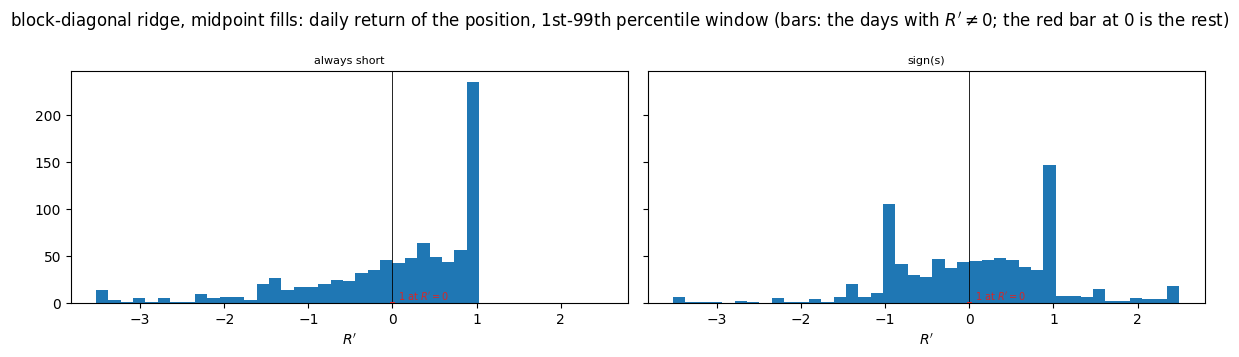

In [12]:
def rule_sizes(px: pd.DataFrame) -> dict[str, pd.Series]:
    long_day = px["signal"].to_numpy(float) > 0   # s == 0 is a short day, as in section 9
    # FOMC statement days and month-end sessions, from the exchange calendar alone
    is_event = asl.event_day_mask(px.index, REPO).to_numpy(bool)
    return {
        "always short": pd.Series(-1.0, index=px.index),
        "sign(s)": px["pos"],
        # the one-sided legs of sign(s): they partition the days, so
        # long only + short only = sign(s) day by day; parked from the tables
        # below, kept here because the library carries them
        "heaviside(s): long only": pd.Series(np.where(long_day, 1.0, 0.0), index=px.index),
        "heaviside(s): short only": pd.Series(np.where(long_day, 0.0, -1.0), index=px.index),
        # parked from the tables (2026-09-24), kept here because the library carries it
        "sign(s), flat on event days": pd.Series(
            np.where(is_event, 0.0, px["pos"].to_numpy(float)), index=px.index),
    }


def rule_row(r: pd.Series, size: pd.Series) -> pd.Series:
    r = pd.Series(r).astype(float)
    size = pd.Series(size, index=r.index).astype(float)
    x = r.dropna()
    n = int(len(x))
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    n_buy = int((size > 0).sum())
    n_sz = int(size.notna().sum())
    return pd.Series({
        "n": n,
        "mean": mu,
        "std": sd,
        "min": float(x.min()),
        "25%": float(x.quantile(0.25)),
        "50%": float(x.median()),
        "75%": float(x.quantile(0.75)),
        "max": float(x.max()),
        "skew": float(x.skew()),
        "ex_kurt": float(x.kurt()),
        "t_mean": mu / sd * np.sqrt(n) if sd > 0 else float("nan"),
        "Sharpe_ann": mu / sd * np.sqrt(asl.PERIODS_PER_YEAR) if sd > 0 else float("nan"),
        "n_buy": n_buy,
        "pct_buy": 100.0 * n_buy / n_sz if n_sz else float("nan"),
    })


order = [
    "always short",
    "sign(s)",
]
assert order == list(asl.RULE_ORDER), "the deck's rule order and the library's disagree"
cols = ["n", "mean", "std", "min", "25%", "50%", "75%", "max",
        "skew", "ex_kurt", "t_mean", "Sharpe_ann", "n_buy", "pct_buy"]
MODEL_ORDER = list(TABLED)  # the paper's eight forecasts, then the per-bar forecasts

common = None
for tag in MODEL_ORDER:
    idx = books[tag].index
    common = idx if common is None else common.intersection(idx)
common = common.sort_values()
print("days per model:", {LABEL[t]: len(books[t]) for t in MODEL_ORDER})
print("common days:", len(common),
      pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))

# the notebook's positions must be the library's, to the bit, on every rule
for _tag in MODEL_ORDER:
    _lib = asl.rule_sizes(books[_tag], REPO)
    _mine = rule_sizes(books[_tag])
    assert set(_mine) == set(_lib), set(_mine) ^ set(_lib)
    for _name in _lib:
        _d = float((_mine[_name] - _lib[_name]).abs().max())
        assert _d == 0.0, (_tag, _name, _d)
print(f"rule_sizes matches atm_straddle_lib.rule_sizes on all {len(_lib)} rules and "
      f"{len(MODEL_ORDER)} forecasts; {len(order)} of them are tabulated")

rule_tabs = {}
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    rule_tabs[tag] = pd.DataFrame({
        name: rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in order
    }).T[cols]
    rule_tabs[tag].to_csv(OUT / f"rule_table_{tag}.csv")

for name in order:
    if name == "always short":
        # takes no forecast: every model row is identical, so print one
        # anonymous row (and assert the identity instead of trusting it)
        base = rule_tabs[MODEL_ORDER[0]].loc[name]
        for tag in MODEL_ORDER[1:]:
            assert np.allclose(rule_tabs[tag].loc[name], base), name
        tab = pd.DataFrame({"all models": base}).T[cols]
    else:
        tab = pd.DataFrame(
            {LABEL[tag]: rule_tabs[tag].loc[name] for tag in MODEL_ORDER}
        ).T[cols]
    print(name)
    print(tab.to_string())
    print("---")
    # slug: runs of non-alphanumerics collapse to one underscore
    # ("always short" -> always_short, "sign(s)" -> sign_s)
    safe = "_".join("".join(ch if ch.isalnum() else " " for ch in name).split())
    tab.to_csv(OUT / f"rule_by_strategy_{safe}.csv")
print("saved per-model rule_table_*.csv and per-rule rule_by_strategy_*.csv in", OUT)

fig, axes = plt.subplots(1, len(order), figsize=(12, 3.6), sharex=True, sharey=True)
px = books["blk2"]
sizes = rule_sizes(px)
pooled = pd.concat([sizes[name] * px["R"] for name in order], axis=0).dropna()
lo, hi = float(pooled.quantile(0.01)), float(pooled.quantile(0.99))
# 40 bins of the 1st-99th percentile width, but laid on multiples of the width
# so that an edge falls exactly on 0.0: a zero return is then never pooled with
# an ordinary day of small |R'|. The zero returns are drawn separately.
w = (hi - lo) / 40.0
bins = np.arange(np.floor(lo / w), np.ceil(hi / w) + 1) * w
n_flat = {name: int(((sizes[name] == 0.0) & px["R"].notna()).sum()) for name in order}
n_zero = {name: int(((sizes[name] * px["R"]).dropna() == 0.0).sum()) for name in order}
print("flat days (q = 0) per rule, block-diagonal ridge, on its own",
      int(px["R"].notna().sum()), "days:", n_flat)
print("days with R' exactly 0, which is what the bar at zero counts (the flat days "
      "plus any day the straddle itself returned exactly nothing):", n_zero)
for ax, name in zip(axes.ravel(), order):
    x = (sizes[name] * px["R"]).dropna()
    nz = x[x != 0.0]
    ax.hist(nz.clip(bins[0], bins[-1]), bins=bins, color="C0", edgecolor="none")
    if n_zero[name]:
        ax.bar([0.0], [n_zero[name]], width=0.35 * w, color="C3", edgecolor="none", zorder=3)
        ax.annotate(f"{n_zero[name]} at $R'=0$", xy=(0.0, n_zero[name]),
                    xytext=(4, 2), textcoords="offset points", fontsize=7, color="C3")
    ax.axvline(0.0, color="k", lw=0.6)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel(r"$R'$")
fig.suptitle("block-diagonal ridge, midpoint fills: daily return of the position, 1st-99th percentile window "
             r"(bars: the days with $R'\neq 0$; the red bar at 0 is the rest)")
fig.tight_layout()
fig.savefig(OUT / "rule_hists_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "rule_hists_blk2.png")
display(fig)
plt.close(fig)


### Beating the control, and telling the forecasts apart

The rule table gives each portfolio's own $t$-statistic against zero.
That is not the question the table is read for. The question is whether
the $\mathrm{sign}(s)$ portfolio beats the always-short control — and the
two portfolios hold the identical position on every day the rule stays
short, so the comparison has to be paired, day by day.

The cell tests three differences on the common days:

- each $\mathrm{sign}(s)$ portfolio minus the always-short control;
- each exogenous forecast's portfolio minus the baseline's
  (HAR + calendar OLS);
- the block-diagonal ridge minus the same ridge without the FOMC
  columns — what the calendar channels are worth on this trade.

For each it reports the mean daily difference, its plain $t$-statistic,
its $t$-statistic with heteroskedasticity- and autocorrelation-robust
standard errors at lag $\lfloor 1.5\,n^{1/3}\rfloor$, and the difference
of annualized Sharpe ratios with a 95% interval from a circular block
bootstrap (blocks of 21 days, 2,000 draws, one fixed seed), in both the
percentile and the basic form. The same resampled days are used for
every row, so the columns can be compared draw by draw.

Before the differences the cell prints the level: each portfolio's own
annualized Sharpe ratio with the bootstrap standard error of that Sharpe
ratio and its 95% percentile interval, on the same resampled days. That
standard error is the scale against which every difference below should
be read. A separate line prints how often each portfolio takes the same
position as the baseline on the same day.

**The reading.** The improvement over the control is unanimous in point
estimate: every $\mathrm{sign}(s)$ portfolio beats always short, by 0.76
to 1.31 in annualized Sharpe ratio. It is not resolved. The paired
$t$-statistics run from 1.06 to 1.70 plain and from 1.18 to 1.90
autocorrelation-robust, and seven of the eight percentile intervals
include zero; only XGBoost's clears it, and it clears it by a knife
edge — a lower bound of 0.02 on an interval 2.46 wide. The scale those
differences should be read against is the bootstrap standard error of
the level itself: 0.44 to 0.55, on Sharpe ratios of 0.97 to 1.51.

The forecasts cannot be told apart on this trade. Each exogenous
forecast minus the baseline is positive in point estimate and none is
resolved, the largest being the fixed-penalty lasso at 0.54 in Sharpe
ratio with an autocorrelation-robust $t$ of 1.14; the portfolios take
the same position as the baseline on 0.82 to 0.87 of the days. The FOMC
calendar columns are worth 0.07 in Sharpe ratio here ($t$ 0.26,
percentile interval $-0.49$ to $0.63$) — a contribution this trade
cannot see, which is why the diagnostic ridge is reported next to the
ridge of record and not in place of it.

In [13]:
# --- paired tests: every portfolio against the control, and against the baseline
def _interval_reading(lo, hi):
    # a bound within 5% of the interval's width from zero is a knife edge, whichever side of zero it falls
    width = hi - lo
    edge = min(abs(lo), abs(hi)) < 0.05 * width
    if lo > 0 or hi < 0:
        return "knife-edge, excludes zero" if edge else "excludes zero"
    return "knife-edge, includes zero" if edge else "includes zero"


PAIR_BLOCK = 21     # circular block length, in trading days
PAIR_B = 2000       # bootstrap draws
PAIR_SEED = 0


def _sharpe_ann(x) -> float:
    x = np.asarray(x, float)
    return float(x.mean() / x.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR))


# ONE set of resampled day indices, drawn once and reused by every portfolio and
# by the control, so that levels and differences are comparable draw by draw
PAIR_IDX = asl.circular_block_bootstrap_idx(
    np.random.default_rng(PAIR_SEED), len(common), PAIR_BLOCK, PAIR_B
)


def _boot_sharpe(x) -> np.ndarray:
    # the annualized Sharpe ratio of x on each of the PAIR_B resampled day sets
    x = np.asarray(x, float)
    assert len(x) == PAIR_IDX.shape[1], "bootstrap indices and series disagree in length"
    d = x[PAIR_IDX]
    return d.mean(axis=1) / d.std(axis=1, ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)


def _paired(a, b) -> dict:
    # a minus b on the same days: mean difference, plain and HAC t, Sharpe difference
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    d = a - b
    n = len(d)
    sd = float(d.std(ddof=1))
    t_hac, lag = asl.newey_west_t(d)
    boot = _boot_sharpe(a) - _boot_sharpe(b)
    lo, hi = (float(v) for v in np.percentile(boot, [2.5, 97.5]))
    hat = _sharpe_ann(a) - _sharpe_ann(b)
    return {"n": n, "mean_diff": float(d.mean()),
            "t_plain": float(d.mean() / sd * np.sqrt(n)) if sd > 0 else float("nan"),
            "t_hac": t_hac, "hac_lag": lag, "dSharpe": hat,
            "pct_lo": lo, "pct_hi": hi, "basic_lo": 2 * hat - hi, "basic_hi": 2 * hat - lo,
            "interval": _interval_reading(lo, hi)}


_rp = {tag: (rule_sizes(books[tag])["sign(s)"] * books[tag]["R"]).loc[common].astype(float)
       for tag in MODEL_ORDER}
_bench = (-books[MODEL_ORDER[0]]["R"]).loc[common].astype(float)
_pos = {tag: books[tag].loc[common, "pos"] for tag in MODEL_ORDER}

pair_rows = []
for tag in MODEL_ORDER:
    pair_rows.append({"comparison": "sign(s) minus always short", "model": LABEL[tag],
                      **_paired(_rp[tag], _bench),
                      "same_position_as_baseline": float((_pos[tag] == _pos["a0"]).mean())})
for tag in MODEL_ORDER[1:]:
    pair_rows.append({"comparison": "sign(s) minus the baseline's sign(s)", "model": LABEL[tag],
                      **_paired(_rp[tag], _rp["a0"]),
                      "same_position_as_baseline": float((_pos[tag] == _pos["a0"]).mean())})
pair_rows.append({"comparison": "FOMC panel minus earlier panel, same ridge",
                  "model": LABEL["blk2"] + " minus " + LABEL["blk2_inc"],
                  **_paired(_rp["blk2"], _rp["blk2_inc"]),
                  "same_position_as_baseline": float((_pos["blk2"] == _pos["blk2_inc"]).mean())})
# the per-bar forecasts against their pooled twins: the same specification,
# the same window, the same days; only the coefficients differ (one vector per
# bar against one vector over all 48 bars)
for _t, _w in TWINS.items():
    _a = (rule_sizes(books[_t])["sign(s)"] * books[_t]["R"]).loc[common].astype(float)
    _b = (rule_sizes(books[_w])["sign(s)"] * books[_w]["R"]).loc[common].astype(float)
    pair_rows.append({"comparison": "per-bar coefficients minus pooled, same spec",
                      "model": LABEL[_t] + " minus " + LABEL[_w],
                      **_paired(_a, _b),
                      "same_position_as_baseline": float((books[_t].loc[common, "pos"] == books[_w].loc[common, "pos"]).mean())})
for _t, _w in asl.SUBSAMPLE_TWIN.items():
    if _w is None or _w not in TWINS.values():
        print(f"no pooled twin yet for {LABEL[_t]} (its pooled arm has not finished on the cluster)")
# the Sharpe ratio itself, with the sampling spread of the SAME resampled days
level_rows = []
for tag in MODEL_ORDER + ["always short"]:
    _x = _bench if tag == "always short" else _rp[tag]
    _b = _boot_sharpe(_x)
    level_rows.append({"comparison": "Sharpe ratio of the portfolio (level)",
                       "model": "always short (no forecast)" if tag == "always short" else LABEL[tag],
                       "n": len(common), "sharpe": _sharpe_ann(_x),
                       "sharpe_se": float(_b.std(ddof=1)),
                       "sharpe_lo": float(np.percentile(_b, 2.5)),
                       "sharpe_hi": float(np.percentile(_b, 97.5))})
level_tab = pd.DataFrame(level_rows)
print("annualized Sharpe ratio of each portfolio, with the circular block-bootstrap standard error and")
print(f"95% percentile interval (blocks of {PAIR_BLOCK} days, {PAIR_B} draws, one seed, the same resampled days on every row):")
print(level_tab[["model", "n", "sharpe", "sharpe_se", "sharpe_lo", "sharpe_hi"]].to_string(
    index=False, float_format=lambda x: f"{x: .4f}"))
print("---")

diff_tab = pd.DataFrame(pair_rows)
pair_tab = pd.concat([level_tab, diff_tab], ignore_index=True)
_show = ["model", "n", "mean_diff", "t_plain", "t_hac", "hac_lag", "dSharpe",
         "pct_lo", "pct_hi", "basic_lo", "basic_hi", "interval"]
for _cmp, _g in diff_tab.groupby("comparison", sort=False):
    print(_cmp)
    print(_g[_show].to_string(index=False, float_format=lambda x: f"{x: .4f}"))
    print("---")
print("share of days each portfolio takes the same position as the baseline:")
print(diff_tab[diff_tab["comparison"] == "sign(s) minus always short"]
      .set_index("model")["same_position_as_baseline"].to_string(float_format=lambda x: f"{x:.3f}"))
print("the last row of the second block compares the two ridge rows, not a portfolio with the baseline; "
      "the per-bar block compares each per-bar forecast with its own pooled twin")
pair_tab.to_csv(OUT / "paired_tests.csv", index=False)
print("saved", OUT / "paired_tests.csv")


annualized Sharpe ratio of each portfolio, with the circular block-bootstrap standard error and
95% percentile interval (blocks of 21 days, 2000 draws, one seed, the same resampled days on every row):
                                         model   n  sharpe  sharpe_se  sharpe_lo  sharpe_hi
                 baseline (HAR + calendar OLS) 866  0.9673     0.4363     0.1109     1.7952
                          block-diagonal ridge 866  1.3383     0.5476     0.2745     2.4216
block-diagonal ridge, without the FOMC columns 866  1.2707     0.5221     0.2639     2.3064
                                      LightGBM 866  1.4594     0.4970     0.4492     2.4225
                                       XGBoost 866  1.4980     0.5033     0.5095     2.4905
                        lasso (causally tuned) 866  1.4131     0.4816     0.4649     2.3703
                            lasso (fixed 1e-4) 866  1.5098     0.5182     0.4544     2.5036
                  elastic net (causally tuned) 866  1.0225     

### Per-bar against pooled: which is the better variance forecast?

The last block of the paired table compares each per-bar forecast with its
pooled twin on what the trade earns. This subsection compares them as
forecasts. The loss is QLIKE, $y/f-\log(y/f)-1$, for the forecast $f$ of a
bar's realized variance $y$; it is zero for a perfect forecast and
penalizes a forecast that is too low more than one that is too high. It is
computed bar by bar for the 13 regular-hours bars (bar ends 10:00 to
16:00), on the same 866 days as §10.

- **The same map on both sides.** Each table goes through the §7
  recalibration, fitted on its own forecasts, so the 16:00 column is
  exactly the forecast §9 trades. The 10:00 bar (09:30–10:00) lies outside
  the map's fit window; its forecast uses the map fitted on the other
  bars.
- **Session mean**: each day's mean loss over the 13 bars, so every test
  runs on one number per day.
- **% difference**: $100\,(\overline{\mathrm{QLIKE}}_{\text{per-bar}}/\overline{\mathrm{QLIKE}}_{\text{pooled}}-1)$.
  Negative means the per-bar forecast has the lower loss.
- **Interval**: 95% circular block bootstrap of days on the % difference
  (blocks of 21 days, 2,000 draws, the resampled days of the paired tests
  above).
- **DM t**: the Diebold–Mariano statistic, the
  heteroskedasticity- and autocorrelation-robust $t$ of the mean daily
  loss difference (Bartlett kernel, lag $\lfloor 1.5\,n^{1/3}\rfloor$).

The cell opens with three gates. It reproduces, from the stored arm
files, the comparison saved with the per-bar runs (the same forecasts,
each bar recalibrated on its own, all 1,087 sessions from 2020-01-03 to
2024-04-30). It checks that the notebook's per-bar and pooled tables hold
exactly those forecasts. It checks that every table's 16:00 column is
the forecast §9 trades.

In [14]:
# --- per-bar against pooled: forecast loss (QLIKE) bar by bar, through the §7 map, on the §10 days
if str(REPO / "experiments") not in sys.path:
    sys.path.insert(0, str(REPO / "experiments"))
import score_linear_subsection as _sls
import score_linear_subsection_causal as _slc
from compare_mfiv_harlag import _prep as _arm_prep   # the research scorer's own reader and back-transform

QL_BARS = [f"{_h:02d}:{_mm:02d}" for _h in range(10, 17) for _mm in (0, 30) if (_h, _mm) <= (16, 0)]
QL_ARMS = REPO / "results" / "linear_subsection" / "arms_hoffman2"
QL_GATE = ("all_features", "ridge", "sub_ridge", "pool_ridge")   # bucket, estimator, per-bar tag, pooled tag

# GATE 1: the stored research comparison (per-bar minus pooled, each bar recalibrated on its own: the
# "coefficients" rows) reproduced from the arm files, every bar, both of its samples
_bk, _est, _tsub, _tpool = QL_GATE
_stored = pd.read_csv(REPO / "results" / "linear_subsection" / "causal_rescore_hoffman2" / _bk / "subsection_vs_pooled_causal.csv")
_stored = _stored[(_stored["estimator"] == _est) & (_stored["train_win"] == 2000) & (_stored["comparison"] == "coefficients")]
_ref = _arm_prep(QL_ARMS / _bk / _est / "tw2000" / "results_none_rth.csv")
_n_chk, _gate16, _arm_bars = 0, {}, []
for _hh in QL_BARS:
    _seg = "bar" + _hh.replace(":", "")
    _mine = _arm_prep(QL_ARMS / _bk / _est / "tw2000" / f"results_{_seg}.csv")
    _arm_bars.append(_mine)
    _jj = _mine.join(_ref[["pred_clock", "pred_pooled", "pred_raw"]], how="inner", rsuffix="_P").dropna(
        subset=["pred_clock", "pred_clock_P", "pred_pooled_P"])
    _deck = (_jj.index >= _sls.DECK_START) & (_jj.index <= _sls.DECK_END + " 23:59")
    for _smp, _mk in (("common", np.ones(len(_jj), bool)), ("deck period", _deck)):
        _la = _slc.qlike(_jj["true_raw"], _jj["pred_clock"])[_mk]
        _lb = _slc.qlike(_jj["true_raw"], _jj["pred_clock_P"])[_mk]
        _lo, _hi = _sls.day_block_ci(_la - _lb)
        _s = _stored[(_stored["segment"] == _seg) & (_stored["sample"] == _smp)].iloc[0]
        for _mine_v, _theirs in ((int(_mk.sum()), "n"), (_la.mean(), "QLIKE_a"), (_lb.mean(), "QLIKE_b"),
                                 (_lo, "ci_lo"), (_hi, "ci_hi")):
            assert np.isclose(_mine_v, _s[_theirs], rtol=1e-9, atol=1e-12), (_seg, _smp, _theirs, _mine_v, _s[_theirs])
            _n_chk += 1
        if _hh == "16:00" and _smp == "deck period":
            _gate16 = {"n": int(_mk.sum()), "a": float(_la.mean()), "b": float(_lb.mean()), "lo": _lo, "hi": _hi}
print(f"GATE 1  {_n_chk} numbers of the stored per-bar vs pooled comparison ({_bk}, {_est}, 2000-session window, "
      f"subsection_vs_pooled_causal.csv) reproduced from the arm files to 1e-9: 13 bars x 2 samples x "
      f"(rows, QLIKE per-bar, QLIKE pooled, interval low, interval high)")
print(f"        its 16:00 bar on all {_gate16['n']} sessions 2020-01-03..2024-04-30, each bar recalibrated on its own: "
      f"QLIKE {_gate16['a']:.4f} per-bar vs {_gate16['b']:.4f} pooled ({100 * (_gate16['a'] / _gate16['b'] - 1):+.1f}%; "
      f"interval on the mean daily difference {_gate16['lo']:+.4f} to {_gate16['hi']:+.4f})")

# GATE 2: the notebook's per-bar and pooled tables carry exactly the arms' forecasts
_arm_all = pd.concat(_arm_bars)
for _t, _src in ((_tsub, _arm_all), (_tpool, _ref)):
    _tb = pd.read_parquet(YHATS[_t], columns=["t", "yhat"])
    _tb["date"] = pd.to_datetime(_tb["t"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
    _j = _tb.set_index("date")[["yhat"]].join(_src[["pred_adj"]], how="inner")
    assert len(_j) == len(_tb), (_t, len(_j), len(_tb))
    assert float((_j["yhat"] - _j["pred_adj"]).abs().max()) == 0.0, _t
    print(f"GATE 2  {YHATS[_t].name} holds the arm's forecast exactly on all {len(_tb):,} stamps")


# the §7 map on every stamp of each table (load_yhat_panel: the 15:30 loader's fit, every stamp)
def _ql_frame(tag):
    p = asl.load_yhat_panel(YHATS[tag], method="mean")
    p["hhmm"] = p["et"].dt.strftime("%H:%M")
    p = p[p["date"].isin(common) & p["hhmm"].isin(QL_BARS)]
    y = p.pivot(index="date", columns="hhmm", values="rv_raw").reindex(index=common, columns=QL_BARS)
    f = p.pivot(index="date", columns="hhmm", values="rv_hat").reindex(index=common, columns=QL_BARS)
    assert y.notna().all().all() and f.notna().all().all() and (y > 0).all().all() and (f > 0).all().all(), tag
    # GATE 3: the 16:00 column is the forecast §9 trades, to the bit
    assert (f["16:00"] == models[tag].loc[common, "rv_hat"]).all(), tag
    return y, f


from concurrent.futures import ThreadPoolExecutor
_ql_tags = list(TWINS) + list(TWINS.values())
with ThreadPoolExecutor(max_workers=len(_ql_tags)) as _pool:
    _fr = dict(zip(_ql_tags, _pool.map(_ql_frame, _ql_tags)))
QL_Y = {_t: _fr[_t][0] for _t in _ql_tags}
QL_F = {_t: _fr[_t][1] for _t in _ql_tags}
for _t, _w in TWINS.items():
    assert (QL_Y[_t] == QL_Y[_w]).all().all(), (_t, _w)   # the same realized variance on both sides
print(f"GATE 3  all {2 * len(TWINS)} tables give a forecast and a positive realized variance for all {len(QL_BARS)} bars "
      f"on all {len(common)} days; each 16:00 column equals the forecast §9 trades")


def _qlike(y, f):
    r = y / f
    return r - np.log(r) - 1.0


def _ql_pair(qa, qb):
    qa, qb = np.asarray(qa, float), np.asarray(qb, float)
    t_dm, lag = asl.newey_west_t(qa - qb)
    bpct = 100.0 * (qa[PAIR_IDX].mean(axis=1) / qb[PAIR_IDX].mean(axis=1) - 1.0)
    lo, hi = (float(v) for v in np.percentile(bpct, [2.5, 97.5]))
    return {"days": len(qa), "QLIKE per-bar": float(qa.mean()), "QLIKE pooled": float(qb.mean()),
            "difference (%)": float(100.0 * (qa.mean() / qb.mean() - 1.0)), "ci_lo (%)": lo, "ci_hi (%)": hi,
            "DM t": t_dm, "lag": lag}


QL_NAME = {_t: LABEL[_t].replace("per-bar ", "") for _t in TWINS}
ql_rows = []
for _t, _w in TWINS.items():
    _qa, _qb = _qlike(QL_Y[_t], QL_F[_t]), _qlike(QL_Y[_w], QL_F[_w])
    for _hh in QL_BARS:
        ql_rows.append({"forecast": QL_NAME[_t], "bar end": _hh, **_ql_pair(_qa[_hh], _qb[_hh])})
    # the session: each day's mean over the 13 bars, so the test runs on one number per day
    ql_rows.append({"forecast": QL_NAME[_t], "bar end": "session mean", **_ql_pair(_qa.mean(axis=1), _qb.mean(axis=1))})
ql_tab = pd.DataFrame(ql_rows)
ql_tab.to_csv(OUT / "perbar_vs_pooled_qlike.csv", index=False)
_ord = list(QL_NAME.values())
print(f"per-bar forecast minus its pooled twin, QLIKE through the §7 map, on the {len(common)} days of §10.")
print(f"DM t = HAC t of the mean daily loss difference (Bartlett, lag {int(ql_tab['lag'].iloc[0])}); interval = 95% "
      f"circular block bootstrap of days on the % difference (blocks {PAIR_BLOCK}, {PAIR_B} draws, the resampled days "
      "of the paired tests above)")
print("session mean over the 13 bars:")
print(ql_tab[ql_tab["bar end"] == "session mean"].drop(columns=["bar end", "lag"]).set_index("forecast").to_string(
    float_format=lambda x: f"{x:.4f}"))
print("---")
_wide = ql_tab.assign(cell=[f"{p:+6.1f} [{lo:+6.1f},{hi:+6.1f}]" for p, lo, hi in
                            zip(ql_tab["difference (%)"], ql_tab["ci_lo (%)"], ql_tab["ci_hi (%)"])])
with pd.option_context("display.width", 250, "display.max_columns", 20, "display.max_colwidth", 30):
    print("% difference, per-bar vs pooled twin [95% interval], by bar end (negative: the per-bar forecast has the lower loss)")
    print(_wide.pivot(index="bar end", columns="forecast", values="cell")
          .reindex(index=QL_BARS + ["session mean"], columns=_ord).to_string())
    print("---")
    print("DM t by bar end")
    print(ql_tab.pivot(index="bar end", columns="forecast", values="DM t")
          .reindex(index=QL_BARS + ["session mean"], columns=_ord).to_string(float_format=lambda x: f"{x:+.2f}"))
print("---")
_b = ql_tab[ql_tab["bar end"] != "session mean"]
print("bars (of 13) whose interval lies wholly below zero (per-bar better) and wholly above zero (pooled better):")
print(pd.DataFrame({_n: {"per-bar better": int((_g["ci_hi (%)"] < 0).sum()), "pooled better": int((_g["ci_lo (%)"] > 0).sum())}
                    for _n, _g in _b.groupby("forecast", sort=False)}).T.to_string())
print("---")
# the 14:00-14:30 bar holds the FOMC statement (14:00): split its row by statement days
_fomc = asl.fomc_and_monthend(pd.DatetimeIndex(common), REPO)["is_fomc"].fillna(False).to_numpy(bool)
_split = {}
for _t, _w in TWINS.items():
    _qa, _qb = _qlike(QL_Y[_t]["14:30"], QL_F[_t]["14:30"]), _qlike(QL_Y[_w]["14:30"], QL_F[_w]["14:30"])
    _split[QL_NAME[_t]] = {f"FOMC statement days ({int(_fomc.sum())})": 100.0 * (_qa[_fomc].mean() / _qb[_fomc].mean() - 1.0),
                           f"other days ({int((~_fomc).sum())})": 100.0 * (_qa[~_fomc].mean() / _qb[~_fomc].mean() - 1.0),
                           "share of the pooled loss on statement days": float(_qb[_fomc].sum() / _qb.sum())}
print("the 14:30 bar (14:00-14:30) split by FOMC statement days: % difference per-bar vs pooled")
print(pd.DataFrame(_split).T.to_string(float_format=lambda x: f"{x:.3f}"))
print("saved", OUT / "perbar_vs_pooled_qlike.csv")


GATE 1  130 numbers of the stored per-bar vs pooled comparison (all_features, ridge, 2000-session window, subsection_vs_pooled_causal.csv) reproduced from the arm files to 1e-9: 13 bars x 2 samples x (rows, QLIKE per-bar, QLIKE pooled, interval low, interval high)
        its 16:00 bar on all 1087 sessions 2020-01-03..2024-04-30, each bar recalibrated on its own: QLIKE 0.1070 per-bar vs 0.1103 pooled (-2.9%; interval on the mean daily difference -0.0116 to +0.0065)
GATE 2  yhat_sub_ridge_all_features.parquet holds the arm's forecast exactly on all 20,044 stamps
GATE 2  yhat_pool_ridge_all_features.parquet holds the arm's forecast exactly on all 54,056 stamps


GATE 3  all 14 tables give a forecast and a positive realized variance for all 13 bars on all 866 days; each 16:00 column equals the forecast §9 trades


per-bar forecast minus its pooled twin, QLIKE through the §7 map, on the 866 days of §10.
DM t = HAC t of the mean daily loss difference (Bartlett, lag 14); interval = 95% circular block bootstrap of days on the % difference (blocks 21, 2000 draws, the resampled days of the paired tests above)
session mean over the 13 bars:
                                 days  QLIKE per-bar  QLIKE pooled  difference (%)  ci_lo (%)  ci_hi (%)    DM t
forecast                                                                                                        
ridge (HAR + calendar)            866         0.1723        0.1884         -8.5370   -11.0127    -5.9828 -5.9096
ridge (all features)              866         0.1667        0.1738         -4.1143    -9.1997     0.8057 -1.5853
lasso (all features)              866         0.1608        0.1764         -8.8446   -14.0598    -4.1069 -3.3019
elastic net (all features)        866         0.1600        0.1758         -8.9664   -14.1968    -4.2916 -3.2

**Reading (every number from the cell above).**

- Over the whole session every per-bar forecast has the lower loss than
  its pooled twin, by 3.3% to 9.0%. The interval clears zero for three
  of the seven: ridge on HAR + calendar (−8.5%, interval −11.0% to
  −6.0%, DM $t$ −5.9), and the lasso (−8.8%) and elastic net (−9.0%) on
  all features. For the two ridges on the wider sets (all features
  −4.1%, live-feasible −3.8%) and the two live-feasible penalized fits
  the interval includes zero.
- That session gain comes from two bars. At the 14:00–14:30 bar every
  per-bar forecast is 30% to 39% better (DM $t$ −3.5 to −6.3), and at
  15:00 8% to 15% better. The 14:00–14:30 bar is the one that holds the
  FOMC statement (14:00). On the 33 statement days in the frame the
  per-bar loss at that bar is 43% to 78% lower, and those days carry
  45% to 54% of the pooled forecasts' loss at that bar; on the other
  833 days the per-bar gain there is 5% to 16%. The gain at that bar is
  mostly the statement afternoon, which a coefficient vector of its own
  for that half hour can fit and one vector for all 48 bars averages
  over.
- Elsewhere the per-bar fits are often worse. On the wide column sets
  the pooled twin wins several late-morning and midday bars (11:00,
  12:30, 13:00): the per-bar loss is up to 21% higher, with the interval
  above zero on five of the 13 bars for the ridge on all features and
  six for the live-feasible ridge. A per-bar model has one thirteenth of
  the pooled model's rows for the same number of columns.
- On the traded bar (16:00) only the ridge on HAR + calendar resolves a
  gain (−6.3%, interval −10.4% to −1.9%). The ridge on all features is
  −2.6% and the live-feasible ridge +1.6%, both intervals including
  zero. The per-bar forecasts' edge in the paired P&L table is
  therefore not a visibly better forecast of the traded half hour's
  variance on this loss.
- The research comparison reproduced in the first gate recalibrates
  each bar on its own and scores all 1,087 sessions; it gives the same
  picture on the 16:00 bar (−2.9% for the ridge on all features,
  interval on the daily difference including zero).

### Sizing by the size of the forecast gap

$\mathrm{sign}(s)$ bets the same amount every day. The alternative bets
in proportion to the forecast gap $s$ (the variance risk premium with
its sign turned round, $\mathrm{VRP}=-s$), so that the position is large
when the forecast and the price disagree by a lot. Three sizes, each set
from **earlier deck days only**:

- **(a) proportional**: $q_d=s_d/\mathrm{rms}_d$, with $\mathrm{rms}_d$
  the root mean square of $s$ over the deck days before $d$. Unbounded.
- **(b) rank, sign kept**: $q_d=\mathrm{sign}(s_d)\,\hat F_d(|s_d|)$,
  where $\hat F_d(x)$ is the share of earlier deck days whose $|s|$ is at
  most $x$. Between $-1$ and $1$ by construction; it always takes the
  side of $\mathrm{sign}(s)$, and is flat on a day whose $|s|$ is below
  every earlier one.
- **(c) centred rank**: $q_d=2\hat F_d(s_d)-1$, where $\hat F_d(x)$ is the
  share of earlier deck days whose $s$ is at most $x$. Between $-1$ and
  $1$; it can take the side opposite to $\mathrm{sign}(s)$, because a day
  with a slightly negative $s$ can still rank above the median.

Fills are at the midpoint ($q_dR_d$) and crossed (a buy pays the ask, a
sale receives the bid). The gap $s$ starts with the option chain on
2020-01-03, so a size needs a history. The first block scores the 614
days after one year (252 deck days) of history, the warm-up §18's
weights use. The second scores every day from the second (865 days),
with whatever history exists; the first day has none. $\mathrm{sign}(s)$
is rescored on the same days. The test is the annualized Sharpe ratio of
the sized rule minus that of $\mathrm{sign}(s)$, with a 95% percentile
interval from the circular block bootstrap of days (blocks of 21 days,
2,000 draws). A Sharpe ratio does not depend on the scale of the
position, so rules with different average sizes compare directly.

**What earlier work found.** An earlier sizing study on the
block-diagonal ridge tried about thirteen graduated sizes. None beat
$\pm1$, and the centred rank (c) did worse than chance. A later study
sized only the buy days by conviction (the rank of $s$, its top
quintile, Kelly by quintile, doubling at month-end) on the same 614 days
at crossed fills, and no rule was supported. Both concluded that the
sign of $s$ carries the day-scale information and its size adds no
return.

In [15]:
# --- sizing by the size of the forecast gap: position proportional to s, against sign(s)
# Each size uses PRIOR deck days only (strictly before d); s = rv_hat - iv_var is known at 15:30.
#   (a) proportional    q = s / rms,            rms = root mean square of s over prior days (unbounded)
#   (b) rank, sign kept q = sign(s) * F(|s|),   F = share of prior days with |s| <= today's |s|, in [-1, 1]
#   (c) centred rank    q = 2 F(s) - 1,         F = share of prior days with s <= today's s, in [-1, 1]
# Fills: midpoint, q * R; crossed, buy at the ask (q > 0) or sell at the bid (q < 0).
VS_WARMUP = int(asl.PERIODS_PER_YEAR)  # one year of prior deck days, as the causal weights use
VS_RULES = ["(a) proportional s/rms", "(b) rank of |s|, sign kept", "(c) centred rank 2F(s)-1"]
VS_BLOCKS = {f"after {VS_WARMUP}-day warm-up": VS_WARMUP, "from the second day": 1}


def _vs_sizes(s: np.ndarray) -> dict:
    n = len(s)
    k = np.arange(n)
    prior = k[None, :] < k[:, None]  # prior[i, j]: day j is strictly before day i
    n_prior = np.where(k > 0, k, np.nan)  # day 0 has no history
    rms = np.sqrt(np.concatenate([[np.nan], np.cumsum(s ** 2)[:-1]]) / n_prior)
    a = np.abs(s)
    F_abs = ((a[None, :] <= a[:, None]) & prior).sum(axis=1) / n_prior
    F_s = ((s[None, :] <= s[:, None]) & prior).sum(axis=1) / n_prior
    sgn = np.where(s > 0, 1.0, -1.0)  # the deck's pos: s == 0 is short
    return {"sign(s)": sgn, VS_RULES[0]: s / rms, VS_RULES[1]: sgn * F_abs, VS_RULES[2]: 2.0 * F_s - 1.0}


def _vs_crossed(q, ex, bid, ask) -> np.ndarray:
    return np.where(q > 0, q * (ex / ask - 1.0), np.where(q < 0, q * (ex / bid - 1.0), 0.0))


def _vs_boot_sharpe(x, idx) -> np.ndarray:
    d = np.asarray(x, float)[idx]
    return d.mean(axis=1) / d.std(axis=1, ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)


# one set of resampled day indices per block length, reused by every forecast and rule (as the causal weights do)
_vs_idx = {b: asl.circular_block_bootstrap_idx(np.random.default_rng([PAIR_SEED, len(common) - st]),
                                               len(common) - st, PAIR_BLOCK, PAIR_B)
           for b, st in VS_BLOCKS.items()}


def _vs_score(tag: str):
    px = books[tag].loc[common]
    s, R = px["signal"].to_numpy(float), px["R"].to_numpy(float)
    ex, entry = px["exit"].to_numpy(float), px["entry"].to_numpy(float)
    bid = (px["bid_c"] + px["bid_p"]).to_numpy(float)
    ask = (px["ask_c"] + px["ask_p"]).to_numpy(float)
    assert (s == (px["rv_hat"] - px["iv_var"]).to_numpy(float)).all(), tag
    assert np.allclose(R, ex / entry - 1.0, rtol=0, atol=1e-12), tag
    assert (bid > 0).all() and (bid <= entry).all() and (entry <= ask).all(), tag
    Q = _vs_sizes(s)
    # gate: this cell's sign(s) is the deck's sign(s) position, and its returns are the deck's, day by day
    ref_pos = rule_sizes(books[tag])["sign(s)"].loc[common].to_numpy(float)
    ref = (rule_sizes(books[tag])["sign(s)"] * books[tag]["R"]).loc[common].to_numpy(float)
    assert np.array_equal(Q["sign(s)"], ref_pos) and np.array_equal(Q["sign(s)"] * R, ref), tag
    xs = asl.crossed_premium_return(pd.Series(Q["sign(s)"], index=px.index), px["exit"],
                                    pd.Series(bid, index=px.index), pd.Series(ask, index=px.index)).to_numpy(float)
    assert np.allclose(_vs_crossed(Q["sign(s)"], ex, bid, ask), xs, rtol=0, atol=1e-12), tag
    rows = []
    for b, st in VS_BLOCKS.items():
        idx, sl = _vs_idx[b], slice(st, None)
        assert np.array_equal((Q["sign(s)"] * R)[sl], ref[sl]), tag  # the sign(s) rows: the same series, restricted
        base = {"mid": (Q["sign(s)"] * R)[sl], "crossed": _vs_crossed(Q["sign(s)"], ex, bid, ask)[sl]}
        base_boot = {f: _vs_boot_sharpe(x, idx) for f, x in base.items()}
        for rule, q_all in Q.items():
            q = q_all[sl]
            assert np.isfinite(q).all(), (tag, rule, b)
            if rule in VS_RULES[1:]:
                assert (np.abs(q) <= 1.0).all(), (tag, rule, b)  # bounded by construction
            rec = {"tag": tag, "forecast": LABEL[tag], "rule": rule, "block": b, "days": len(q),
                   "mean |q|": float(np.abs(q).mean()), "max |q|": float(np.abs(q).max()),
                   "same sign": float((q * Q["sign(s)"][sl] > 0).mean()),
                   "opposite sign": float((q * Q["sign(s)"][sl] < 0).mean())}
            for f, x in (("mid", q * R[sl]), ("crossed", _vs_crossed(q, ex[sl], bid[sl], ask[sl]))):
                rec[f"Sharpe {f}"] = _sharpe_ann(x)
                if rule == "sign(s)":
                    rec.update({f"dSharpe {f}": np.nan, f"lo {f}": np.nan, f"hi {f}": np.nan,
                                f"basic lo {f}": np.nan, f"basic hi {f}": np.nan, f"reading {f}": ""})
                    continue
                hat = _sharpe_ann(x) - _sharpe_ann(base[f])
                lo, hi = (float(v) for v in np.percentile(_vs_boot_sharpe(x, idx) - base_boot[f], [2.5, 97.5]))
                rec.update({f"dSharpe {f}": hat, f"lo {f}": lo, f"hi {f}": hi,
                            f"basic lo {f}": 2 * hat - hi, f"basic hi {f}": 2 * hat - lo,
                            f"reading {f}": _interval_reading(lo, hi)})
            rows.append(rec)
    return rows, _sharpe_ann(Q["sign(s)"] * R), _sharpe_ann(ref)


_vs_rows, _vs_gate = [], {}
for _tag in MODEL_ORDER:
    _r, _mine, _ref = _vs_score(_tag)
    assert abs(_mine - _ref) < 1e-12, _tag
    _vs_rows += _r
    _vs_gate[_tag] = _mine
vs_tab = pd.DataFrame(_vs_rows)
vs_tab.to_csv(OUT / "vrp_sized_rules.csv", index=False)

print(f"gate: this cell's sign(s) is the deck's sign(s) position on every forecast; its midpoint Sharpe on the {len(common)} days "
      "equals the deck's rule:")
print("  " + "; ".join(f"{LABEL[t]} {v:.3f}" for t, v in _vs_gate.items()))
print(f"gate: bid > 0 and bid <= entry <= ask on all {len(common)} days; crossed sign(s) equals asl.crossed_premium_return; "
      f"the sign(s) rows on each block are the {len(common)}-day series restricted")
print(f"blocks: {VS_WARMUP} prior deck days before the first scored day ({len(common) - VS_WARMUP} days), and every day "
      f"from the second ({len(common) - 1} days): the first day has no prior s to scale by, so {len(common) - 1} days is as "
      f"close to the {len(common)} as a causal size gets")
print(f"paired block bootstrap of days (blocks {PAIR_BLOCK}, {PAIR_B} draws), sized rule minus sign(s) on the same days, "
      "percentile interval\n")

_cols = ["rule", "block", "days", "mean |q|", "max |q|", "same sign", "opposite sign",
         "Sharpe mid", "dSharpe mid", "lo mid", "hi mid", "Sharpe crossed", "dSharpe crossed", "lo crossed", "hi crossed",
         "reading mid", "reading crossed"]
with pd.option_context("display.width", 300, "display.max_columns", 30, "display.float_format", lambda v: f"{v: .3f}"):
    for _tag in ("blk2", "sub_live_ridge"):
        print(LABEL[_tag])
        print(vs_tab.loc[vs_tab["tag"] == _tag, _cols].to_string(index=False))
        print()

    # summary across the forecasts, per rule and block
    _sum = []
    for (_rule, _b), _g in vs_tab[vs_tab["rule"] != "sign(s)"].groupby(["rule", "block"], sort=False):
        _rec = {"rule": _rule, "block": _b, "forecasts": len(_g)}
        for _f in ("mid", "crossed"):
            _d = _g[f"dSharpe {_f}"]
            _rec.update({f"{_f}: dS>0": int((_d > 0).sum()), f"{_f}: CI>0": int((_g[f"lo {_f}"] > 0).sum()),
                         f"{_f}: CI<0": int((_g[f"hi {_f}"] < 0).sum()), f"{_f}: min": _d.min(),
                         f"{_f}: median": _d.median(), f"{_f}: max": _d.max()})
        _sum.append(_rec)
    vs_sum = pd.DataFrame(_sum)
    print(f"across the {len(MODEL_ORDER)} forecasts: count with dSharpe > 0, count whose percentile interval lies above / "
          "below zero, and the spread of dSharpe")
    print(vs_sum.to_string(index=False))
print("\nsaved", OUT / "vrp_sized_rules.csv")


gate: this cell's sign(s) is the deck's sign(s) position on every forecast; its midpoint Sharpe on the 866 days equals the deck's rule:
  baseline (HAR + calendar OLS) 0.967; block-diagonal ridge 1.338; block-diagonal ridge, without the FOMC columns 1.271; LightGBM 1.459; XGBoost 1.498; lasso (causally tuned) 1.413; lasso (fixed 1e-4) 1.510; elastic net (causally tuned) 1.022; per-bar ridge (HAR + calendar) 1.250; per-bar ridge (all features) 1.774; per-bar lasso (all features) 1.440; per-bar elastic net (all features) 1.577; per-bar ridge (live-feasible set) 1.683; per-bar lasso (live-feasible set) 1.576; per-bar elastic net (live-feasible set) 1.699
gate: bid > 0 and bid <= entry <= ask on all 866 days; crossed sign(s) equals asl.crossed_premium_return; the sign(s) rows on each block are the 866-day series restricted
blocks: 252 prior deck days before the first scored day (614 days), and every day from the second (865 days): the first day has no prior s to scale by, so 865 days is as

**Reading (every number from the cell above).**

- **Proportional sizing (a) loses to $\mathrm{sign}(s)$ for all 15
  forecasts**, at both fills and in both blocks. After the warm-up the
  Sharpe difference runs from −1.01 to −0.27 at the midpoint
  (block-diagonal ridge 0.76 against 1.54, interval −2.09 to +0.62). The
  position is concentrated: for the block-diagonal ridge its mean size
  is 0.11 and its largest 2.40, so a few days carry the book. From the
  second day, when the first sizes rest on a history of only a few days
  and reach 29 for the block-diagonal ridge, the loss is resolved for
  11 of the 15 forecasts at the midpoint and 10 crossed.
- **The rank with the sign kept (b) ties $\mathrm{sign}(s)$.** After the
  warm-up 8 of 15 forecasts are above it, median +0.03 at the midpoint
  (+0.04 crossed), range −0.26 to +0.43, and no interval excludes zero:
  block-diagonal ridge +0.05 (−0.73 to +0.86), per-bar live-feasible
  ridge −0.11. From the second day 2 of 15 are above, median −0.13.
- **The centred rank (c) is below $\mathrm{sign}(s)$ for all 15
  forecasts in both blocks** (median −0.38 at the midpoint after the
  warm-up). It takes the side opposite to $\mathrm{sign}(s)$ on 17% of
  the days for the block-diagonal ridge.
- **No sized rule has an interval above zero anywhere**: every rule,
  forecast, block and fill. The only intervals that exclude zero are on
  the losing side.
- **This agrees with the earlier work.** The sign of $s$ is what earns;
  sizing by its magnitude adds nothing measurable, and proportional
  sizing, whose sizes pile onto a few days, costs Sharpe.

## 11. Shifting the forecast in time: the look-ahead cliff

The forecast rows are labelled by the bar they end, and the trade reads
the row labelled 16:00 — issued at 15:30 for the bar it trades (§7).
Shift that choice by $k$ half-hour bars and rescore the
$\mathrm{sign}(s)$ rule with everything else unchanged: $k<0$ reads an
earlier row, a stale forecast that is still free of look-ahead; $k=0$
is the trade; $k>0$ reads a row issued after the close, whose lags
contain the traded bar's realized variance. Read raw, the rows after
the close forecast after-hours bars whose variance is far lower, so
they sit below the implied variance on almost every day and collapse
the rule into always short (Sharpe about $0.2$). For $k>0$ the
later forecast is therefore placed on the traded bar's own scale: the
model's fitted-scale forecast $\hat y$ from the later row, the same
recalibration $m=a+b\,\hat y$ and $\hat\sigma^2$ already fitted for the
trade, and the traded bar's profile $B$,
$\widehat{RV}^{(k)}=(m(\hat y_{16{:}00+30k})^2+\hat\sigma^2)\,B_{16{:}00}$
— so the only thing that changes is what the model had seen. The star
is the end of the road: the traded bar's realized variance in place of
the forecast.

The rule is sharp on both sides of the close. One bar stale, the
block-diagonal ridge forecast falls from 1.34 to 0.48, and no stale
shift reaches its own trade for any forecast except the elastic net,
whose two-bar-stale row (1.04) edges past its bar+0 (1.02) — the one
forecast this test does not separate from its stale copies. One bar
after the close, with the traded bar now inside the lags, the ridge
jumps to 3.11 and the two tree forecasts to 4.09 and 4.26, close to the
realized-variance ceiling of 4.53; the lift fades over the next bars as
the lags move on.

every shift is scored on the 0 days for which every shifted row exists (of 866); on all days the k = 0 rule reproduces the rule table exactly (asserted)
annualized Sharpe of sign(s) with the forecast row shifted; bar+0 is the trade;
every shifted row is placed on the traded bar's scale; realized = the traded bar's realized variance
                                                  bar-11    bar-10     bar-9     bar-8     bar-7     bar-6     bar-5     bar-4     bar-3     bar-2     bar-1     bar+0     bar+1     bar+2     bar+3     bar+4     bar+5     bar+6  realized
baseline (HAR + calendar OLS)                   0.339000 -0.041000  0.249000 -0.245000  0.316000  0.652000  0.632000  0.481000  0.914000  0.449000  0.327000  0.967000  2.711000  2.033000  1.745000  1.282000  0.768000  1.578000  4.531000
block-diagonal ridge                            0.460000  0.565000  0.474000  0.527000  0.435000  0.734000  0.857000  0.823000  1.144000  0.934000  0.481000  1.338000  3.112000  1.282000  1.74

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\forecast_shift_cliff.png


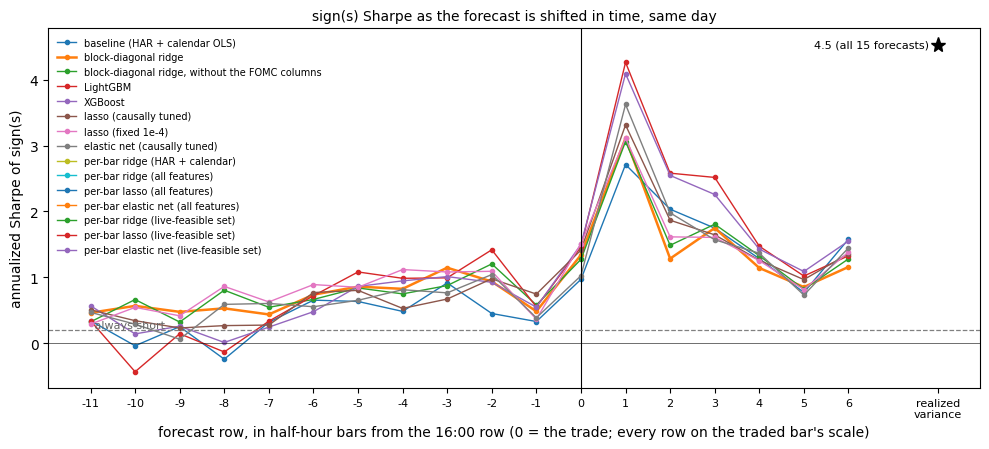

In [16]:
# rescore sign(s) with the forecast row shifted in time; everything else unchanged
BAR_SHIFTS = list(range(-11, 7))   # -11 = the 10:30 row ... 0 = the 16:00 row (the trade) ... +6 = the 19:00 row


def sharpe_ann(x):
    x = pd.Series(x).dropna()
    return float(x.mean() / x.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR))


def load_panel_mz(path):
    # every 30-min row with the trade's recalibration: rv_hat and its pieces m and s2,
    # from the library's fit (same session mask, same early-close drop as the traded row)
    return asl.load_yhat_panel_mz(path)


def shifted_sharpes(tag):
    pan = load_panel_mz(YHATS[tag])
    d = books[tag].loc[common, ["R", "iv_var"]]
    p16 = pan[pan["mins"] == 16 * 60].drop_duplicates("date").set_index("date").sort_index()
    fs = {}
    for k in BAR_SHIFTS:
        sel = pan[pan["mins"] == 16 * 60 + 30 * k].drop_duplicates("date").set_index("date")[["rv_hat", "m", "s2"]]
        j = d.join(sel, how="left").join(p16["baseline"].rename("B16"), how="left")
        # every shifted row is placed on the traded bar's own scale (its profile B at 16:00); at k = 0 this is rv_hat itself
        fs[f"bar{k:+d}"] = j["rv_hat"] if k == 0 else (j["m"] ** 2 + j["s2"]) * j["B16"]
    fs["realized"] = d.join(p16["rv_raw"].rename("f"), how="left")["f"]
    have = pd.concat(fs, axis=1).notna().all(axis=1) & d["R"].notna() & d["iv_var"].notna()
    out = {key: sharpe_ann(np.sign(f[have] - d.loc[have, "iv_var"]).replace(0, -1.0) * d.loc[have, "R"]) for key, f in fs.items()}
    out["n_days"] = int(have.sum())
    out["bar+0_all_days"] = sharpe_ann(np.sign(fs["bar+0"] - d["iv_var"]).replace(0, -1.0) * d["R"])
    return out


with ThreadPoolExecutor(max_workers=len(MODEL_ORDER)) as pool:
    futs = {tag: pool.submit(shifted_sharpes, tag) for tag in MODEL_ORDER}
    shift_tab = pd.DataFrame({LABEL[tag]: futs[tag].result() for tag in MODEL_ORDER}).T
for tag in MODEL_ORDER:
    assert abs(shift_tab.loc[LABEL[tag], "bar+0_all_days"] - rule_tabs[tag].loc["sign(s)", "Sharpe_ann"]) < 1e-9, tag
n_shift_days = int(shift_tab["n_days"].min())
print(f"every shift is scored on the {n_shift_days} days for which every shifted row exists (of {len(common)}); "
      f"on all days the k = 0 rule reproduces the rule table exactly (asserted)")
sharpe_as = float(rule_tabs["blk2"].loc["always short", "Sharpe_ann"])
print("annualized Sharpe of sign(s) with the forecast row shifted; bar+0 is the trade;")
print("every shifted row is placed on the traded bar's scale; realized = the traded bar's realized variance")
print(shift_tab.drop(columns=["n_days", "bar+0_all_days"]).round(3).to_string())
shift_tab.to_csv(OUT / "forecast_shift_cliff.csv")

fig, ax = plt.subplots(figsize=(10, 4.6))
x_star = BAR_SHIFTS[-1] + 2
for tag in MODEL_ORDER:
    lw = 1.8 if tag == "blk2" else 1.0
    ax.plot(BAR_SHIFTS, [shift_tab.loc[LABEL[tag], f"bar{k:+d}"] for k in BAR_SHIFTS], marker="o", ms=3, lw=lw, label=LABEL[tag])
pf = float(shift_tab["realized"].mean())
ax.plot([x_star], [pf], marker="*", ms=11, lw=0, color="k")
ax.annotate(f"{pf:.1f} (all {len(MODEL_ORDER)} forecasts)", (x_star, pf), xytext=(-6, 0), textcoords="offset points", ha="right", va="center", fontsize=8)
ax.axvline(0.0, color="k", lw=0.8)
ax.axhline(sharpe_as, color="0.5", lw=0.9, ls="--")
ax.axhline(0.0, color="k", lw=0.4)
ax.set_ylabel("annualized Sharpe of sign(s)")
ax.set_xticks(BAR_SHIFTS + [x_star])
ax.set_xticklabels([str(k) for k in BAR_SHIFTS] + ["realized\nvariance"], fontsize=8)
ax.set_xlabel("forecast row, in half-hour bars from the 16:00 row (0 = the trade; every row on the traded bar's scale)")
ax.set_title("sign(s) Sharpe as the forecast is shifted in time, same day", fontsize=10)
ax.text(BAR_SHIFTS[0], sharpe_as, " always short", fontsize=8, color="0.4", va="bottom")
ax.legend(fontsize=7, loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(OUT / "forecast_shift_cliff.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "forecast_shift_cliff.png")
display(fig)
plt.close(fig)


## 12. Regressing the settlement return on the 15:30 signal

The signal is fixed at 15:30 and the straddle settles at 16:00 the same
day, so the test pairs $s_t$ with $R_t$; nothing observed after the
decision enters the signal. Per forecast, the least-squares fit

$$R_t = a + b\,s_t + \varepsilon_t$$

with heteroskedasticity-robust standard errors: the table gives $b$, its
$t$-statistic and $R^2$ for the eight forecasts. The slope is a weak
instrument for this relation — a few very large signals carry most of
its leverage — so it is read against the second table, the mean of
$R_t$ on each side of the signal with the $t$-statistic of the
difference, which is the sign(s) rule stated as a statistic.

The figure, for the block-diagonal ridge forecast, shows the fit; the
mean of $R_t$ on each side of the signal, with the always-short
portfolio's mean (the mean of $-R_t$, the rule's benchmark) as the grey
bar — on the sell side the rule earns the red bar's negative; and the
mean of $R_t$ by level of the signal, ten equal-count bins of $s_t$
labelled by their median value in units of $10^{-6}$ (30-minute
variance), coloured by the sign of that median (the bin that straddles
zero is mixed). Means only; the $t$-statistics are in the tables.

The third table takes the magnitude of the signal seriously. Within each
side of the signal — the days the rule sells and the days it buys — the
settlement return is regressed on $s_t$ again, with
heteroskedasticity-robust standard errors. The slopes are not zero.
Within the sell side the slope of $R_t$ on $s_t$ is negative for every
model and resolved for every model ($t$ between $-2.2$ and $-5.7$): the
further below zero the signal sits, the larger the settlement return,
so the short position earns less on the days its signal is most
extreme. Within the buy side the slope is negative too, but resolved
for only two of the eight, the two ridge rows.
The precise claim is therefore narrower than "only the sign matters":
conditional means do vary with the magnitude inside a side, and sizing
the position by $|s_t|$ did not raise the Sharpe ratio when it was
tried. That sizing work is parked and lives in the experimental
notebook; this notebook holds $|q_t| = 1$ every day.

least squares of R_t on the 15:30 signal s_t (heteroskedasticity-robust t):
                                         model                x         a            b       t_b       p_b        R2   n
                 baseline (HAR + calendar OLS) raw s (same day) -0.020779 -2916.439279 -1.887837  0.059048  0.001826 866
                          block-diagonal ridge raw s (same day) -0.019264 -5214.367635 -3.726379  0.000194  0.004522 866
block-diagonal ridge, without the FOMC columns raw s (same day) -0.018782 -5243.061370 -3.932983  0.000084  0.004685 866
                                      LightGBM raw s (same day) -0.015363 -1147.736842 -0.394632  0.693114  0.000170 866
                                       XGBoost raw s (same day) -0.014826  -565.225596 -0.181875  0.855681  0.000037 866
                        lasso (causally tuned) raw s (same day) -0.020118 -4500.569762 -1.884574  0.059487  0.002854 866
                            lasso (fixed 1e-4) raw s (same day) -0.019463 -50

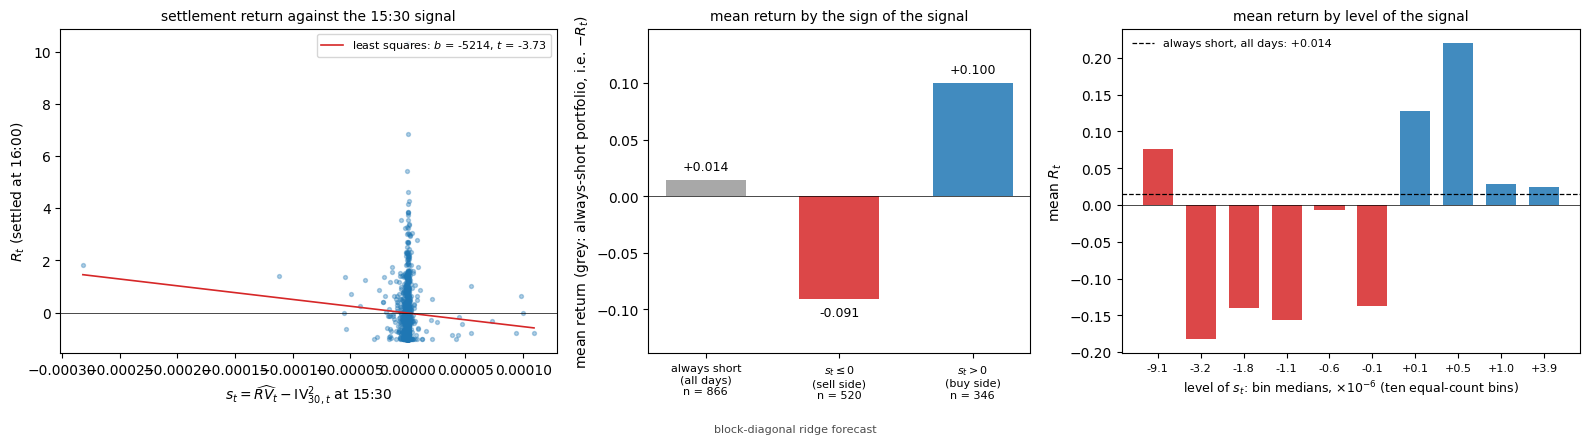

In [17]:
def ls_fit(y, x):
    # least squares with heteroskedasticity-robust (HC0) standard errors
    return sm.OLS(y, sm.add_constant(x)).fit(cov_type="HC0")


reg_rows = []
fig_inputs = None
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    s = px["signal"].astype(float)
    r = px["R"].astype(float)
    ok = np.isfinite(s) & np.isfinite(r)
    fit = ls_fit(r[ok].to_numpy(), s[ok].to_numpy())
    reg_rows.append({"model": LABEL[tag], "x": "raw s (same day)",
                     "a": float(fit.params[0]), "b": float(fit.params[1]),
                     "t_b": float(fit.tvalues[1]), "p_b": float(fit.pvalues[1]),
                     "R2": float(fit.rsquared), "n": int(fit.nobs)})
    if tag == "blk2":
        fig_inputs = (s[ok], r[ok], fit)

reg_tab = pd.DataFrame(reg_rows)
print("least squares of R_t on the 15:30 signal s_t (heteroskedasticity-robust t):")
print(reg_tab.to_string(index=False))
reg_tab.to_csv(OUT / "regression_R_on_signal.csv", index=False)

# the sign split: mean R_t on each side of the signal and the t-statistic of the difference
split_rows = []
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    s = px["signal"].astype(float)
    r = px["R"].astype(float)
    ok = np.isfinite(s) & np.isfinite(r)
    ind = (s[ok] > 0).astype(float).to_numpy()
    fd = ls_fit(r[ok].to_numpy(), ind)
    split_rows.append({"model": LABEL[tag],
                       "mean_R|s<=0": float(r[ok][ind == 0].mean()), "mean_R|s>0": float(r[ok][ind == 1].mean()),
                       "diff": float(fd.params[1]), "t_diff": float(fd.tvalues[1]),
                       "n_sell": int((ind == 0).sum()), "n_buy": int((ind == 1).sum())})
split_tab = pd.DataFrame(split_rows)
print("---")
print("mean R_t by the sign of the 15:30 signal (difference with a heteroskedasticity-robust t):")
print(split_tab.to_string(index=False))
split_tab.to_csv(OUT / "sameday_sign_split.csv", index=False)

# within-side slopes: does the MAGNITUDE of the signal carry anything beyond its sign?
mag_rows = []
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    s = px["signal"].astype(float)
    r = px["R"].astype(float)
    ok = np.isfinite(s) & np.isfinite(r)
    rec = {"model": LABEL[tag]}
    for side, mask in (("sell", ok & (s <= 0)), ("buy", ok & (s > 0))):
        f_ = ls_fit(r[mask].to_numpy(), s[mask].to_numpy())
        rec[f"b_{side}"] = float(f_.params[1])
        rec[f"t_{side}"] = float(f_.tvalues[1])
        rec[f"n_{side}"] = int(mask.sum())
    mag_rows.append(rec)
mag_tab = pd.DataFrame(mag_rows)
print("---")
print("least squares of R_t on s_t WITHIN each side of the signal (heteroskedasticity-robust t):")
print(mag_tab.to_string(index=False))
mag_tab.to_csv(OUT / "within_side_slope.csv", index=False)

s, r, fit = fig_inputs
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={"width_ratios": [1.3, 1, 1.2]})
axes[0].scatter(s, r, s=8, alpha=0.35)
xx = np.linspace(float(s.min()), float(s.max()), 50)
axes[0].plot(xx, fit.params[0] + fit.params[1] * xx, color="C3", lw=1.2,
             label=f"least squares: $b$ = {fit.params[1]:+.0f}, $t$ = {fit.tvalues[1]:+.2f}")
axes[0].axhline(0.0, color="k", lw=0.5)
axes[0].set_xlabel(r"$s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^2$ at 15:30")
axes[0].set_ylabel(r"$R_t$ (settled at 16:00)")
axes[0].set_title("settlement return against the 15:30 signal", fontsize=10)
axes[0].legend(fontsize=8, loc="upper right")

bench_mean = float((-r).mean())   # the always-short portfolio, this notebook's benchmark
stats = [("always short\n(all days)", bench_mean, int(len(r)), "0.6")]
for lab, mask, c in ((r"$s_t \leq 0$" + "\n(sell side)", s <= 0, "C3"),
                     (r"$s_t > 0$" + "\n(buy side)", s > 0, "C0")):
    stats.append((lab, float(r[mask].mean()), int(mask.sum()), c))
top = max(m for _, m, _, _ in stats); bot = min(m for _, m, _, _ in stats)
pad = 0.25 * (top - bot)
for i, (lab, m, n, c) in enumerate(stats):
    axes[1].bar(i, m, color=c, alpha=0.85, width=0.6)
    axes[1].annotate(f"{m:+.3f}", (i, m), xytext=(0, 5 if m >= 0 else -5),
                     textcoords="offset points", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].set_ylim(bot - pad, top + pad)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([f"{lab}\nn = {n}" for lab, _, n, _ in stats], fontsize=8)
axes[1].set_ylabel("mean return (grey: always-short portfolio, i.e. $-R_t$)")
axes[1].set_title("mean return by the sign of the signal", fontsize=10)

# mean return by level of the signal: ten equal-count bins of s_t, labelled by the bin median in units of 1e-6
bins = pd.qcut(s, 10, labels=False, duplicates="drop")
levels = s.groupby(bins).median() * 1e6
means = r.groupby(bins).mean()
axes[2].bar(range(len(means)), means.to_numpy(), color=["C3" if v <= 0 else "C0" for v in levels], alpha=0.85, width=0.7)
axes[2].axhline(bench_mean, color="k", lw=0.9, ls="--", label=f"always short, all days: {bench_mean:+.3f}")
axes[2].axhline(0.0, color="k", lw=0.5)
axes[2].set_xticks(range(len(means)))
axes[2].set_xticklabels([f"{v:+.1f}" for v in levels], fontsize=8)
axes[2].set_xlabel(r"level of $s_t$: bin medians, $\times 10^{-6}$ (ten equal-count bins)", fontsize=9)
axes[2].set_ylabel(r"mean $R_t$")
axes[2].set_title("mean return by level of the signal", fontsize=10)
axes[2].legend(fontsize=8, loc="upper left", frameon=False)
fig.text(0.5, 0.005, "block-diagonal ridge forecast", ha="center", fontsize=8, color="0.3")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(OUT / "regression_R_on_signal_blk2.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 13. Profit and loss, without compounding

Same contracts and positions as the rule table; every series is a daily
quantity, **summed, not compounded**. Notation for one day: position
$q\in\{-1,+1\}$, entry midpoint $P=\mathrm{mid}_c+\mathrm{mid}_p$, bid
and ask sums $P_b$, $P_a$, half-spread $h=\tfrac12(P_a-P_b)$, settlement
payout $X$, contract multiplier $M=100$.

$$
\begin{aligned}
\text{mid premium return}\quad & R' = q\,\Bigl(\frac{X}{P}-1\Bigr) \\[2pt]
\text{crossed spread}\quad & R'_{\times} =
  \begin{cases} X/P_a-1, & q>0 \\ 1-X/P_b, & q<0 \end{cases} \\[2pt]
\text{half-spread cost}\quad & R'_{h} = \frac{q\,\bigl(X-(P+q\,h)\bigr)}{P} = R'-\frac{h}{P} \\[2pt]
\text{index points}\quad & \Pi = q\,(X-P) \\[2pt]
\text{dollars}\quad & \Pi_{\$} = M\,\Pi \\[2pt]
\text{margin-scaled}\quad & R'_{m} = \frac{\Pi_{\$}}{M\,m}
\end{aligned}
$$

with $m$ an exchange-style short-straddle margin, posted every day
whichever way the position points (one capital base, so the row is a
return on the account rather than a mix of two denominators),

$$
m=\max\bigl(0.15\,S-\mathrm{OTM}+P,\;0.10\,S+P,\;0\bigr),\qquad
\mathrm{OTM}=\min\bigl(|S-K_c|,\,|S-K_p|\bigr).
$$

The published series is the first line, filled at the midpoint. The plot
is $\sum_t \Pi_{\$,t}$ for the midpoint and crossed-spread fills.

The crossed-spread row is the one to read next to the midpoint row. It
pays the ask to buy and receives the bid to sell on the way in and
settles in cash on the way out, so it charges the whole quoted spread
once — the worst fill a taker can get, and a bound rather than an
estimate. On the block-diagonal ridge the $\mathrm{sign}(s)$ portfolio
goes from an annualized Sharpe ratio of 1.34 at the midpoint to 0.87 at
the crossed spread ($t$ 1.61), while the always-short control goes from
0.20 to $-0.27$: the control does not survive the spread and the rule
does.

        rule         variant   unit           n       mean         std          min         25%         50%         75%          max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
always short   mid premium R return  866.000000   0.014475    1.127614   -10.316049   -0.448603    0.327356    0.928103     1.000000 -2.311621  10.891894  0.377762    0.203779    0.000000   0.000000
always short  crossed spread return  866.000000  -0.020280    1.170896   -10.954858   -0.499869    0.303299    0.925795     1.000000 -2.361992  11.570511 -0.509689   -0.274946    0.000000   0.000000
always short  half-spread TC return  866.000000  -0.018628    1.128266   -10.369484   -0.482250    0.293699    0.889961     0.988372 -2.314905  10.936648 -0.485857   -0.262090    0.000000   0.000000
always short index-point P&L points  866.000000   0.020287    7.908670   -78.370018   -2.403760    1.759961    3.975000    21.890137 -2.594737  16.009527  0.075486    0.040720    0.000000   0.000000
alway

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\pnl_cum_return_blk2.png


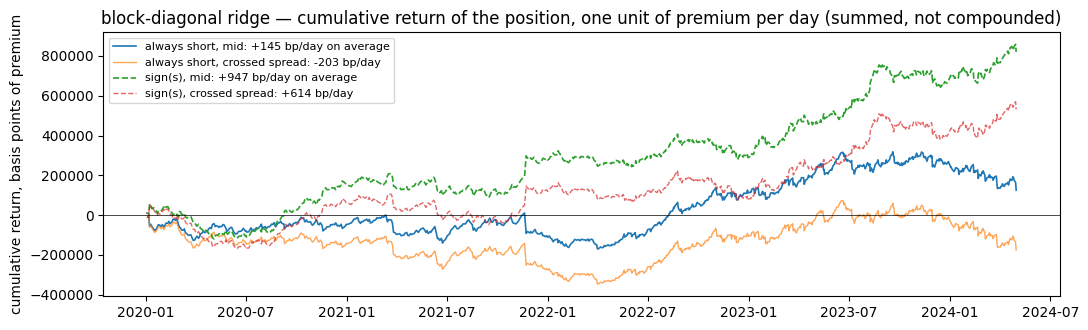

In [18]:
px = books["blk2"].loc[common].copy()
if "bid_entry" not in px.columns:
    px["bid_entry"] = px["bid_c"].astype(float) + px["bid_p"].astype(float)
    px["ask_entry"] = px["ask_c"].astype(float) + px["ask_p"].astype(float)
hs = 0.5 * (px["ask_entry"] - px["bid_entry"])
sizes = rule_sizes(books["blk2"])
rows = []

def add_variant(series, q, rule, variant, unit):
    st = asl.rule_row(series, q)
    rows.append({"rule": rule, "variant": variant, "unit": unit, **st.to_dict()})

for name in order:
    q = sizes[name].loc[common]
    mid = (q * px["R"])
    add_variant(mid, q, name, "mid premium R", "return")
    signq = np.sign(q.replace(0, -1.0))
    crossed = asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * q.abs()
    add_variant(crossed, q, name, "crossed spread", "return")
    trade = px["entry"] + signq * hs
    tc = q * (px["exit"] - trade) / px["entry"]
    add_variant(tc, q, name, "half-spread TC", "return")
    pts = asl.points_pnl(q, px["exit"], px["entry"])
    add_variant(pts, q, name, "index-point P&L", "points")
    usd = pts * asl.SPX_MULTIPLIER
    add_variant(usd, q, name, "dollar P&L", "USD")
    margin_pts = [
        asl.cboe_short_straddle_margin_points(S, Kc, Kp, ent)
        for S, Kc, Kp, ent in zip(px["S"], px["K_c"], px["K_p"], px["entry"])
    ]
    margin_pts = pd.Series(margin_pts, index=px.index)
    capital = margin_pts.to_numpy() * asl.SPX_MULTIPLIER   # the margin is posted every day, whichever way the position points
    mret = usd / np.maximum(capital, 1e-8)
    add_variant(pd.Series(mret, index=px.index), q, name, "margin-scaled", "return")

var_tab = pd.DataFrame(rows)
print(var_tab.to_string(index=False))
var_tab.to_csv(OUT / "pnl_variants_blk2.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.4))
BP = 1e4  # basis points of the entry premium
for name, ls in (("always short", "-"), ("sign(s)", "--")):
    q = sizes[name].loc[common]
    mid_bp = q * px["R"] * BP
    crossed_bp = asl.crossed_premium_return(q, px["exit"], px["bid_entry"], px["ask_entry"]) * BP
    ax.plot(px.index, mid_bp.cumsum(), ls, lw=1.2, label=f"{name}, mid: {mid_bp.mean():+.0f} bp/day on average")
    ax.plot(px.index, crossed_bp.cumsum(), ls, lw=1.0, alpha=0.7, label=f"{name}, crossed spread: {crossed_bp.mean():+.0f} bp/day")
ax.axhline(0.0, color="k", lw=0.5)
ax.set_title("block-diagonal ridge — cumulative return of the position, one unit of premium per day (summed, not compounded)")
ax.set_ylabel("cumulative return, basis points of premium")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "pnl_cum_return_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "pnl_cum_return_blk2.png")
display(fig)
plt.close(fig)


## 14. Information ratio against always-short

**Parked.** The always-short comparison is carried by the paired tests in
§10, which score it day by day on every forecast; the information-ratio
table is held out of the deck.

## 15. Betting a fixed fraction of wealth

Every table so far adds up one unit of premium per day. Here each rule
reinvests: a **fixed** share $f$ of current wealth is deployed as
straddle premium every day, the same number on every day and for every rule,

$$
f = 0.03, \qquad
W_T=\prod_{t}\bigl(1+f\,q_t R_t\bigr), \qquad
g = 252\cdot\overline{\log\bigl(1+f\,R'_t\bigr)},
$$

with $R'_t=q_tR_t$ the rule's daily return and $g$ the annualized
log-growth. The number is a chosen round figure, not fitted. Ruin is one
bad day: wealth reaches zero on the worst day once
$f \ge 1/|\min_t R'_t|$, and the worst single-day wealth factor is
$1+f\min_t R'_t$; both are printed per rule. The bound uses the sample's
worst day, a realized draw rather than a ceiling on what the trade can
lose; and the per-year growth annualizes each calendar year from the
days it traded (83 to 248). The drawdown column, `maxDD_frac`, is the
largest fall of wealth from its running peak as a fraction of that
peak, a different unit from the summed-return drawdowns of §13.

block-diagonal ridge - fixed fraction f = 0.03 of wealth per day, 866 common days
rule              always short     sign(s)
f                     0.030000    0.030000
g_ann                -0.043389    0.574929
terminal              0.861478    7.212006
maxDD_frac           -0.549049   -0.424888
worst_day_factor      0.690519    0.837326
ruin_bound_f          0.096936    0.184417
n                   866.000000  866.000000
saved fixedfrac_summary_<model>.csv in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530
---
terminal wealth across models, every rule
rule                                            always short  sign(s)
model                                                                
baseline (HAR + calendar OLS)                           0.86     3.64
block-diagonal ridge                                    0.86     7.21
block-diagonal ridge, without the FOMC columns          0.86     6.38
elastic net (causally tuned)                            0.8

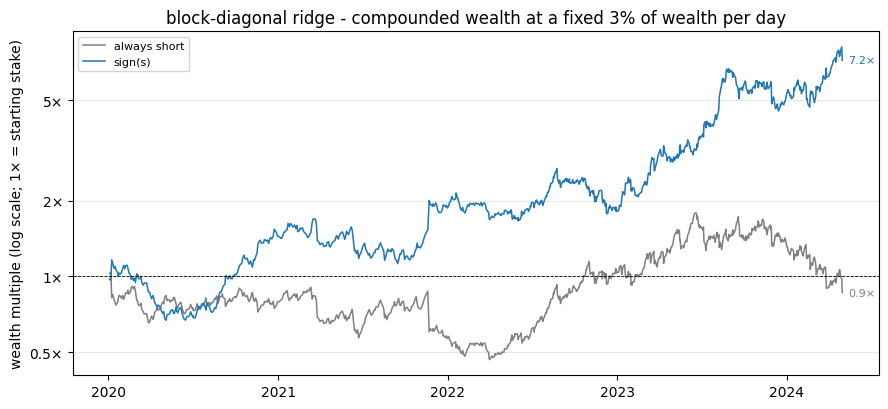

In [19]:
F_FIXED = 0.03  # share of wealth deployed as straddle premium, every day


def wealth_stats(f, r):
    factors = 1.0 + f * np.asarray(r, float)
    assert (factors > 0).all(), "a wealth factor hit zero - ruin"
    w = np.cumprod(factors)
    return pd.Series({
        "f": f,
        "g_ann": float(asl.PERIODS_PER_YEAR) * float(np.mean(np.log(factors))),
        "terminal": float(w[-1]),
        "maxDD_frac": float((w / np.maximum.accumulate(w) - 1.0).min()),   # fall from the running peak, as a fraction of the peak
        "worst_day_factor": float(factors.min()),
        "ruin_bound_f": 1.0 / abs(float(np.min(r))),
        "n": len(r),
    })


def wealth_axis(ax):
    # log-scaled axis labelled in wealth multiples; 1x = the starting stake
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(FixedLocator([0.25, 0.5, 1, 2, 5, 10, 20, 50, 100]))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×"))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.axhline(1.0, color="k", lw=0.6, ls="--")
    ax.grid(axis="y", which="major", alpha=0.3)
    ax.set_ylabel("wealth multiple (log scale; 1× = starting stake)")


ff_rows = {}
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    for name in order:
        rs = (sizes[name] * px["R"]).loc[common].astype(float)
        ff_rows[(name, tag)] = wealth_stats(F_FIXED, rs.to_numpy())
ff_tab = pd.DataFrame(ff_rows).T
ff_tab.index = pd.MultiIndex.from_tuples(ff_tab.index, names=["rule", "model"])
for tag in MODEL_ORDER:
    safe = "".join(ch if ch.isalnum() else "_" for ch in tag).rstrip("_")
    ff_tab.xs(tag, level="model").to_csv(OUT / f"fixedfrac_summary_{safe}.csv")
print(f"block-diagonal ridge - fixed fraction f = {F_FIXED:.2f} of wealth per day, {len(common)} common days")
print(ff_tab.xs("blk2", level="model").T.to_string())
print("saved fixedfrac_summary_<model>.csv in", OUT)
print("---")
print("terminal wealth across models, every rule")
print(ff_tab["terminal"].unstack("rule").rename(index=LABEL).to_string(float_format=lambda x: f"{x:.2f}"))

px = books["blk2"]
print("days traded per calendar year (each year's growth is annualized from these):",
      pd.Series(0, index=common).groupby(common.year).size().to_dict())
for name in ("always short", "sign(s)"):
    rs = (rule_sizes(px)[name] * px["R"]).loc[common].astype(float)
    gy = pd.Series(np.log1p(F_FIXED * rs.to_numpy()), index=rs.index)
    print(f"per-year annualized log-growth, block-diagonal ridge, {name}:")
    print((float(asl.PERIODS_PER_YEAR) * gy.groupby(gy.index.year).mean()).to_string(float_format=lambda x: f"{x:+.3f}"))

import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(9, 4.2))
for name, c in (("always short", "0.5"), ("sign(s)", "C0")):
    rs = (rule_sizes(px)[name] * px["R"]).loc[common].astype(float)
    w = np.cumprod(1.0 + F_FIXED * rs.to_numpy())
    ax.plot(rs.index, w, lw=1.1, color=c, label=name)
    ax.annotate(f"{w[-1]:.1f}×", (rs.index[-1], w[-1]), xytext=(4, 0), textcoords="offset points",
                fontsize=8, va="center", color=c)
wealth_axis(ax)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title(f"block-diagonal ridge - compounded wealth at a fixed {F_FIXED:.0%} of wealth per day")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "fixedfrac_wealth_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "fixedfrac_wealth_blk2.png")
display(fig)
plt.close(fig)


## 16. When does each forecast say buy?

A buy day is one with $q_t>0$. The always-short rule never buys. The
forecasts are compared on the days they share.

                                         model  n_buy    pct_buy  mean_R|buy  mean_R|sell
                 baseline (HAR + calendar OLS)    286  33.025404    0.081928    -0.062012
                          block-diagonal ridge    346  39.953811    0.100443    -0.090939
block-diagonal ridge, without the FOMC columns    355  40.993072    0.092097    -0.088512
                                      LightGBM    290  33.487298    0.132532    -0.088489
                                       XGBoost    279  32.217090    0.141962    -0.088829
                        lasso (causally tuned)    321  37.066975    0.115351    -0.090941
                            lasso (fixed 1e-4)    358  41.339492    0.111636    -0.103348
                  elastic net (causally tuned)    307  35.450346    0.081819    -0.067359
                per-bar ridge (HAR + calendar)    327  37.759815    0.098010    -0.082717
                  per-bar ridge (all features)    316  36.489607    0.151819    -0.110018
          

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\buy_signal_diag_blk2.png


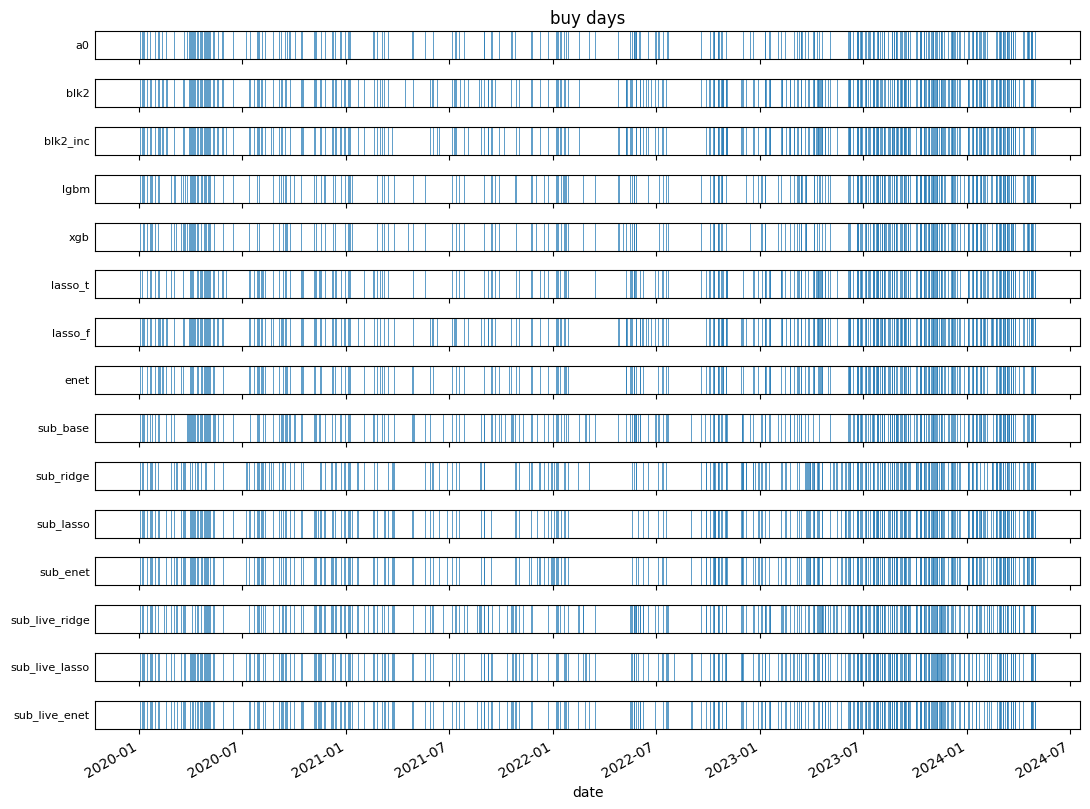

In [20]:
buy = {}
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    buy[tag] = (px["pos"] > 0)
diag_rows = []
for tag in MODEL_ORDER:
    b = buy[tag]
    px = books[tag].loc[common]
    diag_rows.append({
        "model": LABEL[tag],
        "n_buy": int(b.sum()),
        "pct_buy": 100.0 * float(b.mean()),
        "mean_R|buy": float(px.loc[b, "R"].mean()) if b.any() else float("nan"),
        "mean_R|sell": float(px.loc[~b, "R"].mean()),
    })
print(pd.DataFrame(diag_rows).to_string(index=False))
print("always-short n_buy = 0.")

jacc = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
for a in MODEL_ORDER:
    for b in MODEL_ORDER:
        u = buy[a] | buy[b]
        jacc.loc[a, b] = float((buy[a] & buy[b]).sum() / u.sum()) if u.any() else 1.0
jacc.index = [LABEL[t] for t in MODEL_ORDER]
jacc.columns = jacc.index
print("Jaccard of buy-day sets")
print(jacc.round(3).to_string())
jacc.to_csv(OUT / "buy_signal_agreement.csv")
off = jacc.values[np.triu_indices(len(jacc), 1)]
print(f"mean pairwise Jaccard {float(off.mean()):.3f}")

idx = pd.DatetimeIndex(common)
fig, axes = plt.subplots(len(MODEL_ORDER), 1, figsize=(11, 8.2), sharex=True)
for ax, tag in zip(axes, MODEL_ORDER):
    days = idx[buy[tag].to_numpy()]
    ax.vlines(days, 0, 1, color="C0", lw=0.5)
    ax.set_yticks([])
    ax.set_ylabel(tag, rotation=0, ha="right", va="center", fontsize=8)
    ax.set_ylim(0, 1)
axes[-1].set_xlabel("date")
axes[0].set_title("buy days")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "buy_signal_diag_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "buy_signal_diag_blk2.png")
display(fig)
plt.close(fig)


### How often the buy signal is right, and by how much

A **hit** is a day the position makes money: $R_t>0$ on a buy day ($s_t>0$),
$R_t<0$ on a sell day ($s_t\le 0$). The **average win** and the **average
loss** are the means of the position's own return — $R_t$ on a buy day,
$-R_t$ on a sell day — over the days that return is positive and over the days
it is not. The **base rates** are those same three quantities over all the
common days for a long held every day and for a short held every day, with no
forecast used at all.

The figure is one confusion matrix per forecast: the rows are what the signal
said ($s>0$ buy, $s\le 0$ short), the columns what the straddle did ($R>0$,
$R\le 0$), each cell carrying its day count, its share of all days and the mean
$R$ on those days. The diagonal is the hits. The two right-hand cells of every
matrix read the same on every forecast — the short days are the base rate —
and what the signal moves is the top-left cell: the buy days it is right on
are the days with the large positive $R$.

base rates, all 866 common days, no forecast used (days with R exactly 0: 1; share expiring worthless, R = -1: 0.2229):
                            n  hit rate  avg win  avg loss  mean per active day
unconditional long   866.0000    0.3811   1.0724   -0.6836              -0.0145
unconditional short  866.0000    0.6178   0.6849   -1.0692               0.0145

by the side of the signal, in the position's own return (R on a buy day, -R on a sell day):
                                                                n  hit rate  avg win  avg loss  mean per active day  mean R  share R = -1
forecast                                       side                                                                                      
baseline (HAR + calendar OLS)                  buy (s > 0)    286    0.3986   1.2669   -0.7034               0.0819  0.0819        0.2308
                                               sell (s <= 0)  580    0.6259   0.6761   -0.9653               0.0620 -0.0620        0.

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\buy_signal_confusion.png


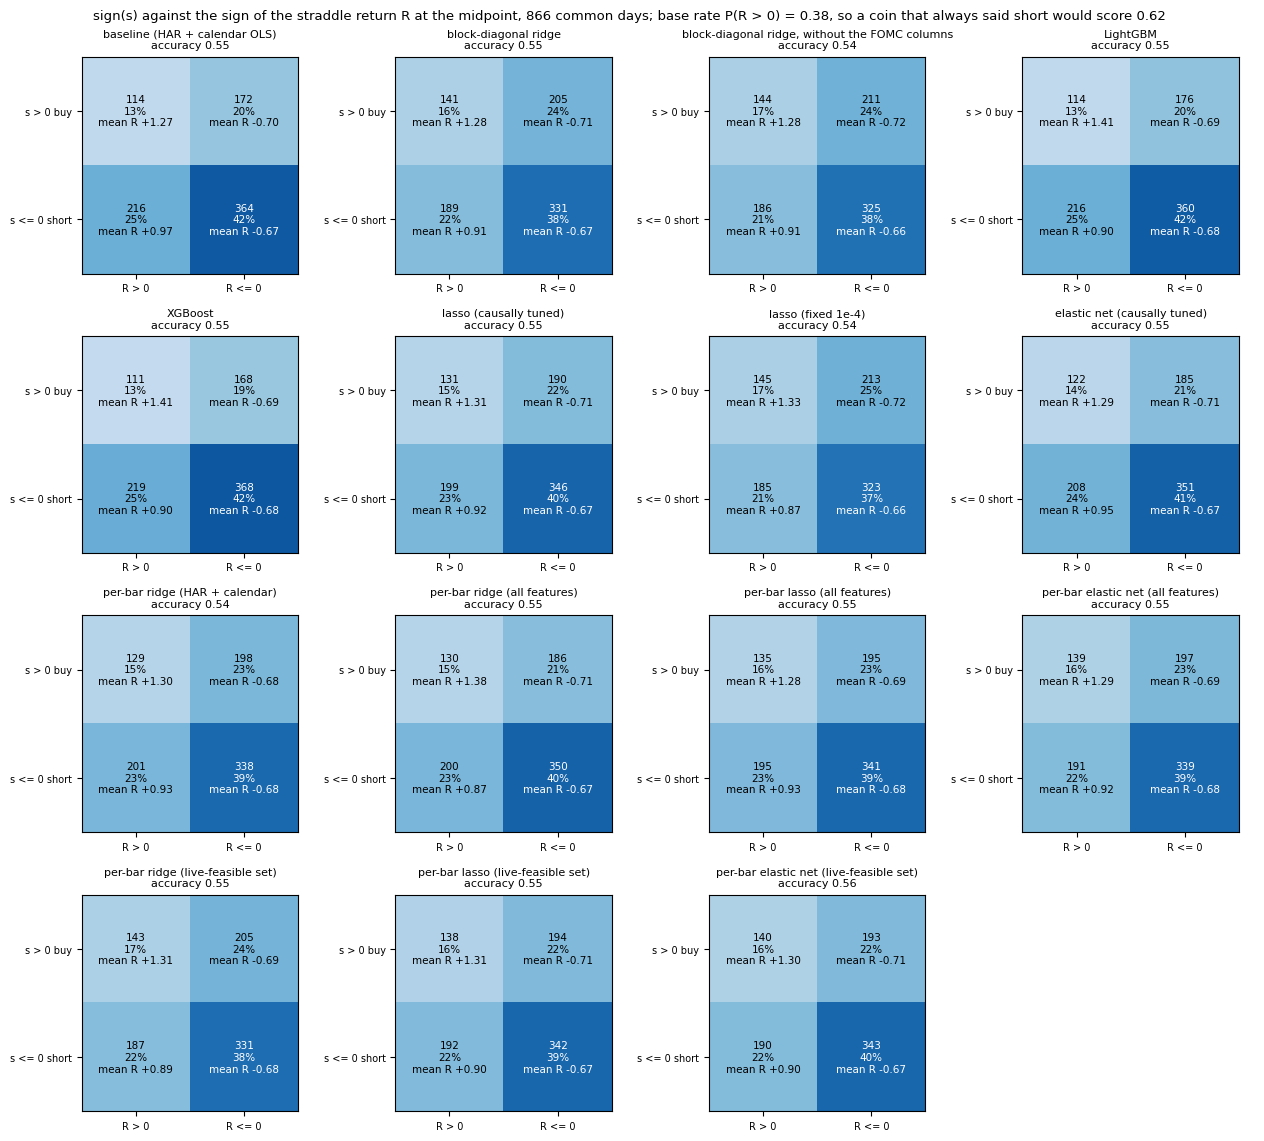

the four cells per forecast (days, share of all days, mean R):
                                                      days                                 mean_R                                   
signal                                         buy (s > 0)       short (s <= 0)       buy (s > 0)           short (s <= 0)          
straddle                                            R <= 0 R > 0         R <= 0 R > 0      R <= 0     R > 0         R <= 0     R > 0
forecast                                                                                                                            
baseline (HAR + calendar OLS)                          172   114            364   216   -0.703000  1.267000      -0.674000  0.970000
block-diagonal ridge                                   205   141            331   189   -0.713000  1.284000      -0.665000  0.915000
block-diagonal ridge, without the FOMC columns         211   144            325   186   -0.716000  1.276000      -0.663000  0.915000
LightG

In [21]:
# --- side by side: is the buy signal picking wins, or picking bigger wins?
# A hit is a day the position makes money: R > 0 on a buy day, R < 0 on a sell
# day. Every column below is the position's own return u -- u = R on a buy day,
# u = -R on a sell day -- so a hit is u > 0 on both sides, the average win is
# the mean of u over the days it is positive, and the average loss the mean of
# u over the days it is not.
def side_stats(u):
    u = np.asarray(u, float)
    win, loss = u[u > 0.0], u[u <= 0.0]
    return {
        "n": int(u.size),
        "hit rate": float((u > 0.0).mean()),
        "avg win": float(win.mean()) if win.size else float("nan"),
        "avg loss": float(loss.mean()) if loss.size else float("nan"),
        "mean per active day": float(u.mean()),
    }


_Rall = books["blk2"].loc[common, "R"].astype(float).to_numpy()
REF = {"unconditional long": side_stats(_Rall), "unconditional short": side_stats(-_Rall)}
ref_tab = pd.DataFrame(REF).T
print(f"base rates, all {len(common)} common days, no forecast used "
      f"(days with R exactly 0: {int((_Rall == 0.0).sum())}; "
      f"share expiring worthless, R = -1: {float((_Rall == -1.0).mean()):.4f}):")
print(ref_tab.to_string(float_format=lambda x: f"{x: .4f}"))

bs_rows = []
for tag in MODEL_ORDER:
    pxc = books[tag].loc[common]
    s = pxc["signal"].astype(float).to_numpy()
    r = pxc["R"].astype(float).to_numpy()
    is_buy = s > 0
    for side, m_, u in (("buy (s > 0)", is_buy, r), ("sell (s <= 0)", ~is_buy, -r)):
        rr = r[m_]
        bs_rows.append({"forecast": LABEL[tag], "side": side, **side_stats(u[m_]),
                        "mean R": float(rr.mean()), "share R = -1": float((rr == -1.0).mean())})
bs_tab = pd.DataFrame(bs_rows).set_index(["forecast", "side"])
print()
print("by the side of the signal, in the position's own return (R on a buy day, -R on a sell day):")
print(bs_tab.to_string(float_format=lambda x: f"{x: .4f}"))
bs_tab.to_csv(OUT / "buy_signal_reading.csv")
print("saved", OUT / "buy_signal_reading.csv")

# --- confusion matrices: one per forecast, sign(s) against the sign of R
# rows: the signal (s > 0 buy, s <= 0 short); columns: the straddle (R > 0, R <= 0).
# Each cell: the day count, its share of all common days, and the mean R on
# those days -- how often, and by how much, in one picture.
_base_up = float((_Rall > 0.0).mean())
conf_rows = []
n_cols = 4
n_rows = int(np.ceil(len(MODEL_ORDER) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.9 * n_rows))
for ax, tag in zip(axes.ravel(), MODEL_ORDER):
    pxc = books[tag].loc[common]
    s = pxc["signal"].astype(float).to_numpy()
    r = pxc["R"].astype(float).to_numpy()
    pred_long = s > 0.0
    act_up = r > 0.0
    cells = {
        (0, 0): pred_long & act_up,       # buy, R > 0   : hit
        (0, 1): pred_long & ~act_up,      # buy, R <= 0  : miss
        (1, 0): ~pred_long & act_up,      # short, R > 0 : miss
        (1, 1): ~pred_long & ~act_up,     # short, R <= 0: hit
    }
    mat = np.array([[cells[(0, 0)].sum(), cells[(0, 1)].sum()],
                    [cells[(1, 0)].sum(), cells[(1, 1)].sum()]], float)
    n = mat.sum()
    ax.imshow(mat, cmap="Blues", vmin=0, vmax=max(n / 2, 1))
    for (i, j), m_ in cells.items():
        v = int(m_.sum())
        mean_r = float(r[m_].mean()) if v else float("nan")
        ax.text(j, i, f"{v}\n{100 * v / n:.0f}%\nmean R {mean_r:+.2f}", ha="center", va="center",
                fontsize=7.5, color="white" if v > n / 3 else "black")
        conf_rows.append({"forecast": LABEL[tag], "signal": "buy (s > 0)" if i == 0 else "short (s <= 0)",
                          "straddle": "R > 0" if j == 0 else "R <= 0", "days": v, "share": v / n, "mean_R": mean_r})
    acc = (mat[0, 0] + mat[1, 1]) / n
    ax.set_title(f"{LABEL[tag]}\naccuracy {acc:.2f}", fontsize=8)
    ax.set_xticks([0, 1], labels=["R > 0", "R <= 0"], fontsize=7)
    ax.set_yticks([0, 1], labels=["s > 0 buy", "s <= 0 short"], fontsize=7)
for ax in axes.ravel()[len(MODEL_ORDER):]:
    ax.axis("off")
fig.suptitle(f"sign(s) against the sign of the straddle return R at the midpoint, {len(common)} common days; "
             f"base rate P(R > 0) = {_base_up:.2f}, so a coin that always said short would score {1 - _base_up:.2f}",
             fontsize=9.5)
fig.tight_layout()
fig.savefig(OUT / "buy_signal_confusion.png", dpi=130, bbox_inches="tight")
print("saved", OUT / "buy_signal_confusion.png")
display(fig)
plt.close(fig)
conf_tab = pd.DataFrame(conf_rows)
conf_tab.to_csv(OUT / "buy_signal_confusion.csv", index=False)
print("the four cells per forecast (days, share of all days, mean R):")
print(conf_tab.pivot_table(index="forecast", columns=["signal", "straddle"], values=["days", "mean_R"], aggfunc="first")
      .reindex([LABEL[t] for t in MODEL_ORDER]).round(3).to_string())


## 17. The VIX bucket alone: does the forecast need more than the VIX?

The live-feasible forecasts of §7 use 16 columns: ES return moments and
liquidity from minute bars, three Cboe indices (VIX, VVIX, VIX3M) and the
FOMC calendar. A live forecaster has to fetch every one of them each
afternoon. This section asks which of them the forecast needs.

Four column sets, each fitted the same way as the live-feasible rows: one
regression per 30-minute bar, refitted on a 2000-session rolling window,
by ridge, lasso and elastic net.

- **HAR + calendar + VIX only**: the realized-variance lags, the calendar
  and the VIX level. No ES moments, no VVIX, no VIX3M.
- **live-feasible minus VVIX and VIX3M**: 14 columns.
- **live-feasible (16 columns)**: the rows already in §10.
- **free feed**: ES 1-minute bar moments (volume included, tick count
  left out), the VIX and the FOMC calendar; 13 columns, all free to pull.

The first cell is a gate. It re-scores the stored forecasts the way the
research comparison scored them, and asserts that every number matches
the stored comparison. That scorer recalibrates each bar on its own and
trades the 16:00-bar forecast. The second cell puts the same forecasts
through this notebook's recalibration (§7) and sign(s) trade (§9), on
the same days as §10. It first checks that its live-feasible rows equal
the §10 rows exactly.

Table columns:

- **16:00 QLIKE vs live-feasible (%)**: forecast loss on the 15:30–16:00
  bar, relative to the live-feasible forecast on the same rows. Negative
  is better.
- **13-bar mean QLIKE vs live-feasible (%)**: the same, averaged over the
  13 bars from 10:00 to 16:00.
- **Sharpe mid / crossed (research scorer)**: the sign(s) trade at the
  midpoint and at the quotes (buy at the ask, sell at the bid),
  annualized.
- **Sharpe mid / crossed (this notebook)**: the same trade through this
  notebook's recalibration; comparable with §10.
- **n days**: days traded.

These forecasts are not added to the eight columns of the other tables.

In [22]:
# --- GATE: the research comparison, re-scored from the stored per-bar fits
if str(REPO / "experiments") not in sys.path:
    sys.path.insert(0, str(REPO / "experiments"))
import compare_mfiv_harlag as _cmh

VX_PULLED = {"vix_only": "vixonly_carc", "live_vix_only": "vixonly_carc", "free_vix_only": "free_carc"}
VX_EST = {"ridge": "ridge", "lasso": "reclasso", "enet": "reclasticnet"}
VX_TW = 2000  # the rolling window, in sessions, of every forecast in this section
_cmp = pd.concat([pd.read_csv(REPO / "results" / "linear_subsection" / f"{_f}_carc" / f"compare_{_f}.csv")
                  for _f in ("vixonly", "free")])
_cmp = _cmp[_cmp["arm"] == "bar1600"].drop_duplicates(["bucket", "estimator"]).set_index(["bucket", "estimator"])
vx_research = {}
for _e, _est in VX_EST.items():
    _root = "linear_subsection_lassofix" if _est == "reclasso" else "linear_subsection"
    _ref = {_s: _cmh.incumbent(_est, VX_TW, _s) for _s in _cmh.BARS}
    _t = _cmh.trade(_ref["bar1600"], None)
    vx_research[("live_feasible", _e)] = {"q16": 0.0, "q13": 0.0, "mid": _t["Sharpe_mid"], "crossed": _t["Sharpe_crossed"],
                                           "n": _t["deck_days"], "key": "live_feasible (incumbent)"}
    for _b, _pulled in VX_PULLED.items():
        _arms = {_s: _cmh.pulled(_pulled, _root, _b, _s, _est, VX_TW) for _s in _cmh.BARS}
        _per = [_cmh.paired_qlike(_arms[_s], _ref[_s], None, None)["pct_vs_ref"] for _s in _cmh.BARS]
        _pq = _cmh.paired_qlike(_arms["bar1600"], _ref["bar1600"], None, None)
        _t = _cmh.trade(_arms["bar1600"], None)
        vx_research[(_b, _e)] = {"q16": _pq["pct_vs_ref"], "q13": float(np.mean(_per)), "mid": _t["Sharpe_mid"],
                                 "crossed": _t["Sharpe_crossed"], "n": _t["deck_days"], "key": _b}
_n_chk = 0
for (_b, _e), _x in vx_research.items():
    _c = _cmp.loc[(_x["key"], _e)]
    for _mine, _theirs in (("q16", "qlike_pct_vs_incumbent_16"), ("q13", "qlike_pct_mean_13_bars"),
                           ("mid", "trade_Sharpe_mid"), ("crossed", "trade_Sharpe_crossed"), ("n", "trade_deck_days")):
        assert np.isclose(_x[_mine], _c[_theirs], rtol=1e-9, atol=1e-12), (_b, _e, _mine, _x[_mine], _c[_theirs])
        _n_chk += 1
print(f"GATE  {_n_chk} numbers of the stored comparison (compare_vixonly.csv, compare_free.csv) reproduced from the "
      f"per-bar fits to 1e-9: 4 column sets x 3 estimators x (16:00 QLIKE, 13-bar QLIKE, Sharpe mid, Sharpe crossed, days)")
_r = vx_research[("vix_only", "ridge")]
_l = vx_research[("live_feasible", "ridge")]
print(f"      ridge, HAR + calendar + VIX only: 16:00 QLIKE {_r['q16']:+.2f}% vs live-feasible, 13-bar mean {_r['q13']:+.2f}%, "
      f"Sharpe mid / crossed {_r['mid']:.2f} / {_r['crossed']:.2f} against {_l['mid']:.2f} / {_l['crossed']:.2f}")


GATE  60 numbers of the stored comparison (compare_vixonly.csv, compare_free.csv) reproduced from the per-bar fits to 1e-9: 4 column sets x 3 estimators x (16:00 QLIKE, 13-bar QLIKE, Sharpe mid, Sharpe crossed, days)
      ridge, HAR + calendar + VIX only: 16:00 QLIKE -5.92% vs live-feasible, 13-bar mean +3.31%, Sharpe mid / crossed 1.48 / 1.00 against 1.90 / 1.44


In [23]:
# --- the same forecasts through this notebook's recalibration and trade, on the §10 days
VX_PATHS = asl.vixonly_yhat_paths(REPO)
vx_rows = []
for (_b, _e), _path in VX_PATHS.items():
    _rv = load_yhat_1530_cached(f"vx_{_e}_{_b}", _path, need_dates, "mean")
    _px, _ = make_book(_rv)
    assert common.difference(_px.index).empty, (_b, _e, len(common.difference(_px.index)))
    _pxc = _px.loc[common]
    _q = _pxc["pos"].to_numpy(float)
    _mid = _q * _pxc["R"].to_numpy(float)
    if _b == "live_feasible":
        # like with like: the same forecast, position and Sharpe as the §10 live-feasible row
        _deck = books[f"sub_live_{_e}"].loc[common]
        assert (_pxc["rv_hat"] == _deck["rv_hat"]).all() and (_pxc["pos"] == _deck["pos"]).all(), _e
        _r10 = float(rule_tabs[f"sub_live_{_e}"].loc["sign(s)", "Sharpe_ann"])
        assert np.isclose(_sharpe_ann(_mid), _r10, rtol=1e-12), (_e, _sharpe_ann(_mid), _r10)
    _ask = (_pxc["ask_c"] + _pxc["ask_p"]).to_numpy(float)
    _bid = (_pxc["bid_c"] + _pxc["bid_p"]).to_numpy(float)
    _ex = _pxc["exit"].to_numpy(float)
    _crs = np.where(_q > 0.0, _ex / _ask - 1.0, -(_ex / _bid - 1.0))
    _x = vx_research[(_b, _e)]
    vx_rows.append({"estimator": _e, "column set": asl.VIXONLY_BUCKET_LABEL[_b],
                    "16:00 QLIKE vs live-feasible (%)": _x["q16"], "13-bar mean QLIKE vs live-feasible (%)": _x["q13"],
                    "Sharpe mid (research scorer)": _x["mid"], "Sharpe crossed (research scorer)": _x["crossed"],
                    "Sharpe mid (this notebook)": _sharpe_ann(_mid), "Sharpe crossed (this notebook)": _sharpe_ann(_crs),
                    "n days": len(common)})
vx_tab = pd.DataFrame(vx_rows).set_index(["estimator", "column set"])
vx_tab.to_csv(OUT / "vix_bucket.csv")
print("GATE  the live-feasible rows equal the §10 sign(s) rows (forecast, position, Sharpe) for all three estimators")
print(f"per-bar forecasts, {VX_TW}-session rolling window; QLIKE and the research-scorer Sharpe ratios from the gate above; "
      f"'this notebook' = §7 recalibration and §9 sign(s) on the {len(common)} common days")
with pd.option_context("display.width", 250, "display.max_columns", 20):
    print(vx_tab.to_string(float_format=lambda v: f"{v:.2f}"))
print("saved", OUT / "vix_bucket.csv")


GATE  the live-feasible rows equal the §10 sign(s) rows (forecast, position, Sharpe) for all three estimators
per-bar forecasts, 2000-session rolling window; QLIKE and the research-scorer Sharpe ratios from the gate above; 'this notebook' = §7 recalibration and §9 sign(s) on the 866 common days
                                                           16:00 QLIKE vs live-feasible (%)  13-bar mean QLIKE vs live-feasible (%)  Sharpe mid (research scorer)  Sharpe crossed (research scorer)  Sharpe mid (this notebook)  Sharpe crossed (this notebook)  n days
estimator column set                                                                                                                                                                                                                                                   
ridge     HAR + calendar + VIX only                                                   -5.92                                    3.31                          1.48               

**Reading (ridge; every number from the two cells above).**

- The VIX alone, with HAR and the calendar, gives the best 16:00
  forecast: QLIKE 5.9% below the live-feasible set. Over the 13 bars it
  is 3.3% worse. It also trades worse: Sharpe 1.48 at the midpoint and
  1.00 crossed, against 1.90 and 1.44 (research scorer). The ES minute-bar
  moments are what the trade uses.
- Dropping VVIX and VIX3M changes nothing measurable: 16:00 QLIKE
  −0.04%, 13-bar mean −0.4%, Sharpe 1.86 / 1.39. The live feed needs
  only the VIX.
- The free feed (ES 1-minute bars, the VIX, the calendar) is within
  noise of the full set: 16:00 QLIKE −0.43%, 13-bar mean −0.01%, Sharpe
  1.83 / 1.36.
- Through this notebook's recalibration the order is the same. Ridge,
  midpoint / crossed: VIX only 1.38 / 0.91, live-feasible 1.68 / 1.22,
  minus VVIX and VIX3M 1.85 / 1.38, free feed 1.89 / 1.42. For all three
  estimators the VIX-only set trades below the live-feasible set, and the
  two sets without VVIX and VIX3M trade above it. No interval is computed
  for these differences.
- The live-feasible ridge earns 1.68 here and 1.90 in the research
  scorer. The research scorer recalibrates the 16:00 bar on its own; this
  notebook fits one map on all 13 bars of the session (§7). The forecasts
  are the same; only the map differs.

## 18. Portfolio weights: the trade beside the S&P

**The question.** An investor already holds the S&P 500. How much of the
15:30 sign(s) trade should sit beside it, and does adding it raise the
portfolio's Sharpe ratio? The weight is set each day from **past days
only**, so every number below could have been known at the time. One
table and one figure.

**The two daily returns**, on the days both exist:

- the trade, $u_d = q_d R_d$: the sign(s) position ($q_d=\pm1$) times
  the return per dollar of premium, $R_d=\mathrm{exit}/\mathrm{premium}-1$,
  at the midpoint;
- the S&P, $m_d$: its close-to-close return, from the official closes
  the settlement uses.

Cash earns nothing, which flatters neither side.

**Which S&P return.** The weight is set against the close-to-close
return $m_d$, because that is what an S&P holder earns. The trade,
though, lives in the last half hour only, so the table also correlates
it with the S&P over the **same window**, 15:30 to the close,
$S_{\mathrm{close}}/S_{15:30}-1$ (the spot at entry and the settlement
close of §4–§5), and with the **size** of each move, $|\cdot|$, since a
straddle is paid by the size of the move rather than its direction.

**How the weight is set on day $d$.** Every estimate uses only the days
before $d$.

1. **Warm-up.** No weight until 252 earlier days exist. After that the
   history expands: all earlier days are used.
2. **Risk scaling.** Each stream is divided by its own standard
   deviation over the earlier days, $\hat\sigma_u$ and $\hat\sigma_m$:
   $z^u_d = u_d/\hat\sigma_u$ and $z^m_d = m_d/\hat\sigma_m$. Each scaled
   stream carries one unit of risk.
3. **Estimates.** From the same earlier days: each stream's daily Sharpe
   ratio, $\widehat{SR}_u$ and $\widehat{SR}_m$ (mean over standard
   deviation, set to 0 if negative), and their correlation $\hat\rho$.
4. **Maximum-Sharpe mix.** For two unit-risk streams, the mix with the
   highest Sharpe ratio puts
   $w_u = (\widehat{SR}_u-\hat\rho\,\widehat{SR}_m)/(1-\hat\rho^{2})$ on
   the trade and
   $w_m = (\widehat{SR}_m-\hat\rho\,\widehat{SR}_u)/(1-\hat\rho^{2})$ on
   the S&P. A negative weight is set to 0: neither stream is ever sold
   short.
5. **Risk share.** The trade's share of the risk budget is
   $s_d = w_u/(w_u+w_m)$, or 0 when both weights are 0.
6. **The day's return.** The portfolio earns
   $(1-s_d)\,z^m_d + s_d\,z^u_d$. It is compared with the S&P alone at
   one unit of risk, $z^m_d$, on the same days.

**In dollars.** A risk share $s_d$ means holding $s_d/\hat\sigma_u$
dollars of straddle premium for every $(1-s_d)/\hat\sigma_m$ dollars of
index: $100\,s_d\,\hat\sigma_m/\big((1-s_d)\,\hat\sigma_u\big)$ dollars of
premium per \$100 of S&P.

**Columns of the table** (one row per forecast):

- `scored days`, `first day`: the days with a weight, after the warm-up.
- `correlation with S&P, 15:30→close`: the daily correlation of the
  trade $u_d$ with the S&P's return over the trade's own window, 15:30
  to the close, over the scored days.
- `correlation with |S&P, 15:30→close|`: the same with the size of that
  move, its absolute value.
- `correlation with S&P, close-to-close`: the daily correlation of the
  trade with $m_d$, the return the weight is set against.
- `correlation with |S&P, close-to-close|`: the same with the size of
  the close-to-close move.
- `trailing correlation (mean)`: $\hat\rho$ as used in step 4, averaged
  over the scored days.
- `mean risk share`, `last risk share`: $s_d$ averaged over the scored
  days, and on the last day.
- `premium $ per $100 S&P (median)`, `(last)`: the same weight in
  dollars, as the median over the scored days and on the last day.
- `Sharpe S&P alone`, `Sharpe combination`: annualized, over the scored
  days.
- `dSharpe`, `ci_lo`, `ci_hi`: the combination's Sharpe ratio minus the
  S&P's, and its 95% interval from the paired block bootstrap of §10
  (both series resampled on the same days).

**The figure** plots, as cumulative sums in units of risk, the S&P
alone ($z^m_d$), the block-diagonal ridge trade alone ($z^u_d$, dashed)
and three combinations.

In [24]:
# --- the S&P on the deck days, from the closes the settlement uses
_gspc = pd.read_parquet(REPO / "results" / "atm_straddle_intraday_holdclose" / "proposals" / "67" / "gspc_close.parquet")["close"]
_gspc.index = pd.to_datetime(_gspc.index)
spx_r = _gspc.pct_change().reindex(pd.DatetimeIndex(common))
assert spx_r.notna().all(), "an S&P close is missing on a deck day"
_dev = float(np.max(np.abs(_gspc.reindex(pd.DatetimeIndex(common)).to_numpy() / books["blk2"].loc[common, "S_close"].to_numpy() - 1.0)))
assert _dev < 1e-9, _dev
print(f"S&P closes equal the deck's settlement closes on all {len(common)} days (max rel diff {_dev:.1e}); "
      f"S&P on these days: Sharpe {_sharpe_ann(spx_r):.2f}, vol {float(spx_r.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)):.1%}")


_m = spx_r.to_numpy(float)

# The whole-sample table (tangency weights fitted on the days they are scored on, the crossed-fill
# version and the Kelly fraction) is commented out 2026-09-24: the weight from past days only, in the
# next cell, is the table of record.
# def _crossed_u(pxc):
#     # the sign(s) position at the quotes: bought at the ask, sold at the bid
#     q = np.where(pxc["signal"].astype(float).to_numpy() > 0.0, 1.0, -1.0)
#     ask = (pxc["ask_c"] + pxc["ask_p"]).to_numpy(float)
#     bid = (pxc["bid_c"] + pxc["bid_p"]).to_numpy(float)
#     ex = pxc["exit"].to_numpy(float)
#     return np.where(q > 0.0, ex / ask - 1.0, -(ex / bid - 1.0))
#
#
# def _kelly(u, grid=np.linspace(0.0, 3.0, 3001)):
#     # argmax_f mean log(1 + f u), on a grid; -inf where a day would ruin
#     x = 1.0 + np.outer(grid, u)
#     g = np.where((x > 0).all(axis=1), np.log(np.where(x > 0, x, 1.0)).mean(axis=1), -np.inf)
#     return float(grid[int(np.argmax(g))])
#
#
# def _tangency(t, m):
#     # unconstrained mean-variance weights on (trade, S&P), cash at zero
#     mu = np.array([t.mean(), m.mean()])
#     C = np.cov(np.vstack([t, m]), ddof=1)
#     w = np.linalg.solve(C, mu)
#     var_p = float(w @ C @ w)
#     return w, float(w @ mu / np.sqrt(var_p) * np.sqrt(asl.PERIODS_PER_YEAR)), float(w[0] ** 2 * C[0, 0] / var_p)
#
#
# _m = spx_r.to_numpy(float)
# _sr_m = _sharpe_ann(_m)
# pw_rows = []
# for basis in ("midpoint", "crossed"):
#     for tag in MODEL_ORDER:
#         pxc = books[tag].loc[common]
#         u = (pxc["pos"].astype(float) * pxc["R"].astype(float)).to_numpy() if basis == "midpoint" else _crossed_u(pxc)
#         rho = float(np.corrcoef(u, _m)[0, 1])
#         sr_t = _sharpe_ann(u)
#         w, sr_p, risk_share = _tangency(u, _m)
#         ir = (sr_t - rho * _sr_m) / np.sqrt(1.0 - rho ** 2)
#         fk = _kelly(u)
#         pw_rows.append({"basis": basis, "forecast": LABEL[tag],
#                         "Sharpe trade": sr_t, "Sharpe S&P": _sr_m, "correlation": rho,
#                         "premium $ per $100 S&P": 100.0 * w[0] / w[1] if w[1] > 0 else float("nan"),
#                         "risk share of trade": risk_share,
#                         "Sharpe tangency": sr_p, "Sharpe gain over S&P": sr_p - _sr_m,
#                         "gain formula sqrt(SR^2+IR^2)": float(np.sqrt(_sr_m ** 2 + ir ** 2) - _sr_m),
#                         "Kelly f (premium units)": fk, "half Kelly": fk / 2})
# pw_tab = pd.DataFrame(pw_rows).set_index(["basis", "forecast"])
# pw_tab.to_csv(OUT / "portfolio_weights.csv")
# print("whole-sample tangency weights of the sign(s) trade beside the S&P, same days, cash at zero (optimistic: fitted where scored)")
# print(pw_tab.round(3).to_string())
# print("saved", OUT / "portfolio_weights.csv")


S&P closes equal the deck's settlement closes on all 866 days (max rel diff 0.0e+00); S&P on these days: Sharpe 0.53, vol 21.4%


the weight from past days only (expanding tangency, 252-session warm-up, risk-scaled, long-only), midpoint fills;
Sharpe of the combination against the S&P alone on the same scored days, paired block bootstrap (blocks 21, 2000 draws)
                                                scored days   first day  correlation with S&P, 15:30→close  correlation with |S&P, 15:30→close|  correlation with S&P, close-to-close  correlation with |S&P, close-to-close|  trailing correlation (mean)  mean risk share  last risk share  premium $ per $100 S&P (median)  premium $ per $100 S&P (last)  Sharpe S&P alone  Sharpe combination   dSharpe     ci_lo     ci_hi
forecast                                                                                                                                                                                                                                                                                                                                                     

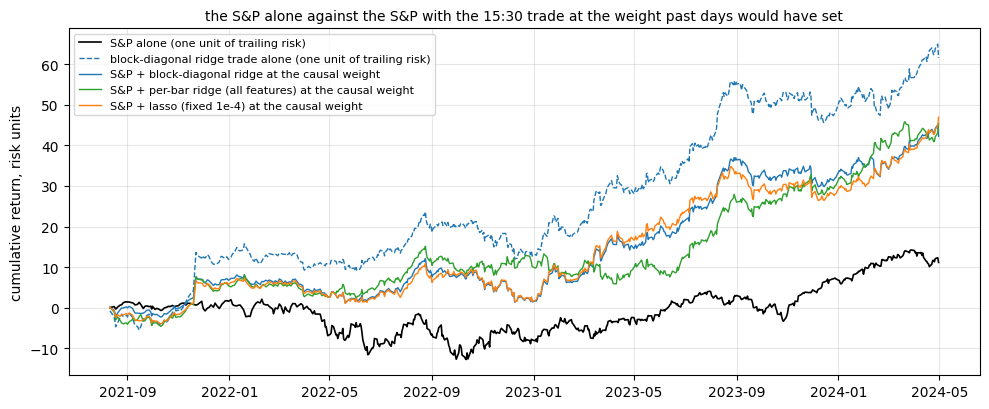

In [25]:
# --- the weight from past days only: expanding tangency on risk-scaled streams
PW_WARMUP = 252


def _causal_combo(u, m):
    t = pd.Series(u, index=pd.DatetimeIndex(common))
    s_ = pd.Series(m, index=pd.DatetimeIndex(common))
    sd_t = t.expanding(min_periods=PW_WARMUP).std().shift(1)
    sd_m = s_.expanding(min_periods=PW_WARMUP).std().shift(1)
    zt, zm = t / sd_t, s_ / sd_m  # one unit of trailing risk each
    # tangency on the standardized streams from strictly prior days: weights
    # proportional to R^-1 SR, long-only (a negative trailing Sharpe gets no risk)
    sr_t = (t.expanding(min_periods=PW_WARMUP).mean() / sd_t).shift(1).clip(lower=0.0)
    sr_m = (s_.expanding(min_periods=PW_WARMUP).mean() / sd_m).shift(1).clip(lower=0.0)
    rho = t.expanding(min_periods=PW_WARMUP).corr(s_).shift(1)
    wt = ((sr_t - rho * sr_m) / (1.0 - rho ** 2)).clip(lower=0.0)
    wm = ((sr_m - rho * sr_t) / (1.0 - rho ** 2)).clip(lower=0.0)
    share = (wt / (wt + wm)).where((wt + wm) > 0.0, 0.0)
    combo = (1.0 - share) * zm + share * zt
    ok = combo.notna() & zm.notna()
    # the same weight in dollars: premium per $100 of index (undefined when the trade takes all the risk)
    usd = (100.0 * share * sd_m / ((1.0 - share) * sd_t)).where(share < 1.0)
    return combo[ok], zm[ok], share[ok], rho[ok], usd[ok], t[ok], s_[ok], zt[ok]


pwc_rows, _combo_paths = [], {}
for tag in MODEL_ORDER:
    pxc = books[tag].loc[common]
    u = (pxc["pos"].astype(float) * pxc["R"].astype(float)).to_numpy()
    combo, alone, share, rho_tr, usd, u_sc, m_sc, trade_alone = _causal_combo(u, _m)
    n_c = len(combo)
    idx_c = asl.circular_block_bootstrap_idx(np.random.default_rng([PAIR_SEED, n_c]), n_c, PAIR_BLOCK, PAIR_B)
    dc, da = combo.to_numpy()[idx_c], alone.to_numpy()[idx_c]
    d_sr = (dc.mean(axis=1) / dc.std(axis=1, ddof=1) - da.mean(axis=1) / da.std(axis=1, ddof=1)) * np.sqrt(asl.PERIODS_PER_YEAR)
    # the S&P over the trade's own window, 15:30 to the close, on the same scored days
    _wd = pd.DatetimeIndex(u_sc.index)
    _same = (pxc.loc[_wd, "S_close"].astype(float) / pxc.loc[_wd, "S"].astype(float) - 1.0).to_numpy()
    _uu, _mm = u_sc.to_numpy(), m_sc.to_numpy()
    pwc_rows.append({"forecast": LABEL[tag], "scored days": n_c, "first day": str(combo.index[0].date()),
                     "correlation with S&P, 15:30→close": float(np.corrcoef(_uu, _same)[0, 1]),
                     "correlation with |S&P, 15:30→close|": float(np.corrcoef(_uu, np.abs(_same))[0, 1]),
                     "correlation with S&P, close-to-close": float(np.corrcoef(_uu, _mm)[0, 1]),
                     "correlation with |S&P, close-to-close|": float(np.corrcoef(_uu, np.abs(_mm))[0, 1]),
                     "trailing correlation (mean)": float(rho_tr.mean()),
                     "mean risk share": float(share.mean()), "last risk share": float(share.iloc[-1]),
                     "premium $ per $100 S&P (median)": float(usd.median()),
                     "premium $ per $100 S&P (last)": float(usd.iloc[-1]),
                     "Sharpe S&P alone": _sharpe_ann(alone), "Sharpe combination": _sharpe_ann(combo),
                     "dSharpe": _sharpe_ann(combo) - _sharpe_ann(alone),
                     "ci_lo": float(np.percentile(d_sr, 2.5)), "ci_hi": float(np.percentile(d_sr, 97.5))})
    _combo_paths[tag] = (combo, alone, trade_alone)
pwc_tab = pd.DataFrame(pwc_rows).set_index("forecast")
pwc_tab.to_csv(OUT / "portfolio_weights_causal.csv")
print(f"the weight from past days only (expanding tangency, {PW_WARMUP}-session warm-up, risk-scaled, long-only), midpoint fills;")
print(f"Sharpe of the combination against the S&P alone on the same scored days, paired block bootstrap (blocks {PAIR_BLOCK}, {PAIR_B} draws)")
with pd.option_context("display.width", 250, "display.max_columns", 20):
    print(pwc_tab.round(3).to_string())
print("saved", OUT / "portfolio_weights_causal.csv")

fig, ax = plt.subplots(figsize=(10, 4.2))
_c0, _a0, _t0 = _combo_paths["blk2"]
ax.plot(_a0.index, _a0.cumsum(), color="k", lw=1.2, label="S&P alone (one unit of trailing risk)")
ax.plot(_t0.index, _t0.cumsum(), color="C0", lw=1.0, ls="--",
        label=f"{LABEL['blk2']} trade alone (one unit of trailing risk)")
for tag, c in (("blk2", "C0"), ("sub_ridge", "C2"), ("lasso_f", "C1")):
    if tag in _combo_paths:
        _c, _, _ = _combo_paths[tag]
        ax.plot(_c.index, _c.cumsum(), color=c, lw=1.0, label=f"S&P + {LABEL[tag]} at the causal weight")
ax.set_ylabel("cumulative return, risk units")
ax.set_title("the S&P alone against the S&P with the 15:30 trade at the weight past days would have set", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "portfolio_weights_causal.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "portfolio_weights_causal.png")
display(fig)
plt.close(fig)


**Reading (every number from the table above).**

- The trade barely moves with the index's direction. Over the 614
  scored days its daily correlation with the S&P's close-to-close
  return is between −0.04 and +0.03 for every forecast, and the
  trailing correlation the weight uses averages between −0.01 and
  +0.05. Almost all of the trade's risk is new risk to an S&P holder.
- That correlation is with the full day, not the last half hour. Over
  the trade's own window, 15:30 to the close, it is between −0.11 and
  +0.08 (block-diagonal ridge −0.04): the direction of the last half
  hour does not drive the trade either.
- The size of the last half hour's move does. The correlation with
  $|$S&P, 15:30→close$|$ is negative for every forecast, from −0.23 to
  −0.08 (block-diagonal ridge −0.14): the rule sells the straddle on
  most days, and a sold straddle loses when the index travels far in
  the last half hour. The size of the full-day move barely registers
  (−0.04 to +0.03).
- Past days put most of the risk budget in the trade: the mean risk
  share is 0.63 to 0.81 across forecasts. For the block-diagonal ridge
  it is 0.73 (0.72 on the last day). In dollars that is a median of
  \$4.32 of straddle premium per \$100 of S&P (\$3.08 on the last day).
- Block-diagonal ridge: over the 614 days from 2021-08-11 the S&P alone
  has Sharpe 0.40; with the trade at the past-days weight, 1.44. The
  gain is 1.04, with a 95% interval of −0.46 to +2.55.
- Every forecast's interval includes zero; the highest lower bound is
  −0.11 (per-bar elastic net, live-feasible set). The gain is large but
  not yet distinguishable from none on 614 days.

### What the trade's return moves with

Is the trade a bet on something else in disguise? The cell below
correlates the trade's daily return $u_d=q_dR_d$ (midpoint), for the
block-diagonal ridge and for the per-bar ridge on the live-feasible set,
with same-day moves of other markets, on the 866 days of §10 wherever
both exist:

- the S&P over the trade's own window (15:30 to the close) and
  close-to-close, and the size of each move, as in the table above but
  over all 866 days rather than the 614 scored ones;
- the VIX: its close-to-close change, and its change over the last half
  hour (15:30 to 16:00, from the panel's 30-minute VIX prints);
- the Nasdaq-100, the Russell 2000, the 10-year Treasury yield (its
  change, in points of the quoted yield), long Treasuries (TLT, total
  return), high-yield credit (HYG, total return) and the dollar index,
  all close-to-close from Yahoo daily closes, fetched once and cached
  with the pull date;
- the realized minus the implied variance of the traded half hour, the
  quantity the forecast gap $s$ tries to anticipate.

Each correlation carries a 95% interval from the circular block
bootstrap of days (blocks of 21 days, 2,000 draws). A change of exactly
zero cannot be told apart from a feed that did not update, so such a day
is dropped for that series; the cell prints how many.

In [26]:
XS_TICKERS = {"^VIX": "VIX", "^NDX": "Nasdaq-100", "^RUT": "Russell 2000", "^TNX": "10-year Treasury yield",
              "TLT": "long Treasuries (TLT)", "HYG": "high-yield credit (HYG)", "DX-Y.NYB": "dollar index"}
XS_START, XS_END = "2019-12-01", "2024-05-31"
XS_CACHE = OUT / "cross_asset_daily_closes.parquet"
if XS_CACHE.exists():
    xs_raw = pd.read_parquet(XS_CACHE)
    print("read", XS_CACHE.name, "pulled", xs_raw["pulled_utc"].iloc[0])
else:
    import yfinance as yf
    _rows = []
    _pulled = pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%dT%H:%MZ")
    for _tk in XS_TICKERS:
        _h = yf.download(_tk, start=XS_START, end=XS_END, auto_adjust=False, progress=False, multi_level_index=False)
        assert len(_h), _tk
        _rows.append(pd.DataFrame({"date": pd.DatetimeIndex(_h.index).tz_localize(None).normalize(), "ticker": _tk,
                                   "close": _h["Close"].to_numpy(float), "adj_close": _h["Adj Close"].to_numpy(float)}))
    xs_raw = pd.concat(_rows, ignore_index=True)
    xs_raw["pulled_utc"] = _pulled
    xs_raw.to_parquet(XS_CACHE, index=False)
    print("downloaded", len(XS_TICKERS), "tickers; saved", XS_CACHE.name, "pulled", _pulled)

_days = pd.DatetimeIndex(common)
_CM_TAGS = ("blk2", "sub_live_ridge")


def _own(tk, col):
    # one ticker's own Yahoo calendar, in date order
    _s = xs_raw.loc[xs_raw["ticker"] == tk].set_index("date")[col].sort_index()
    assert _s.index.is_unique and _s.notna().all(), tk
    return _s


# gate 1: the cached VIX close is the same number as the daily VIX feed the deck already holds
_v1d = pd.read_parquet(REPO / "data" / "free_feed" / "vix_1d_yahoo.parquet")
_v1d = pd.Series(_v1d["close"].to_numpy(float), index=pd.DatetimeIndex(_v1d["t"]).normalize())
assert _v1d.index.is_unique
_vx = _own("^VIX", "close")
_sh = _vx.index.intersection(_v1d.index)
_dv = float((_vx.loc[_sh] - _v1d.loc[_sh]).abs().max())
assert _dv == 0.0, _dv
print(f"gate: cached VIX close equals the daily VIX feed on all {len(_sh)} shared dates (max |difference| {_dv})")

# gate 2: the trade's daily return u = sign(s) position x R (midpoint entry to cash settlement)
_u = {}
for _t in _CM_TAGS:
    _b = books[_t].reindex(_days)
    _u[_t] = _b["pos"] * _b["R"]
    _ref = (rule_sizes(books[_t])["sign(s)"] * books[_t]["R"]).reindex(_days)
    assert _u[_t].notna().all() and np.array_equal(_u[_t].to_numpy(float), _ref.to_numpy(float)), _t
    # the signal is rv_hat - iv_var, so realized and implied variance are in the same units
    assert np.array_equal(_b["signal"].to_numpy(float), (_b["rv_hat"] - _b["iv_var"]).to_numpy(float)), _t
print(f"gate: u = sign(s) position x R on all {len(_days)} deck days for {' and '.join(LABEL[t] for t in _CM_TAGS)}")
_same_side = int((books[_CM_TAGS[0]]["pos"].reindex(_days) == books[_CM_TAGS[1]]["pos"].reindex(_days)).sum())
print(f"the two forecasts take the same side on {_same_side} of {len(_days)} days")

# the same-day series, each on the deck days
for _col in ("S", "S_close", "iv_var"):
    assert np.array_equal(books[_CM_TAGS[0]][_col].reindex(_days).to_numpy(float),
                          books[_CM_TAGS[1]][_col].reindex(_days).to_numpy(float)), _col
_rv = [models[_t]["rv_raw"].reindex(_days) for _t in _CM_TAGS]
assert np.array_equal(_rv[0].to_numpy(float), _rv[1].to_numpy(float)) and _rv[0].notna().all()
print("gate: S, S_close, iv_var and rv_raw are the same numbers in both forecasts' tables")
_bk = books[_CM_TAGS[0]].reindex(_days)
_r1530 = _bk["S_close"] / _bk["S"] - 1.0

# VIX 15:30 -> 16:00 from the panel's 30-minute Cboe prints (stamps naive ET, bar-end labelled)
_pan = pd.read_parquet(REPO / "data" / "vix_and_voldemand.parquet", columns=["endbartime", "vix"]).dropna(subset=["vix"])
_et = pd.DatetimeIndex(pd.to_datetime(_pan["endbartime"]))
assert _et.tz is None


def _panel_at(h, m):
    _k = (_et.hour == h) & (_et.minute == m)
    _s = pd.Series(_pan["vix"].to_numpy(float)[_k], index=_et[_k].normalize())
    assert _s.index.is_unique, (h, m)
    return _s


_vix_hh = (_panel_at(16, 0) - _panel_at(15, 30)).reindex(_days)


def _chg(tk, col):
    _s = _own(tk, col)
    return (_s - _s.shift(1)).reindex(_days)


def _ret(tk, col):
    _s = _own(tk, col)
    return (_s / _s.shift(1) - 1.0).reindex(_days)


# (label, series, stale check applies, size of row) ; the close-to-close changes are taken against the
# previous row of each ticker's own calendar, then read on the deck days
_rows_cm = [
    ("S&P 500 return, 15:30->close", _r1530, True, None),
    ("S&P 500 |return|, 15:30->close", None, None, 0),
    ("S&P 500 return, close-to-close", spx_r.reindex(_days), True, None),
    ("S&P 500 |return|, close-to-close", None, None, 2),
    ("VIX change, close-to-close (points)", _chg("^VIX", "close"), True, None),
    ("VIX change, 15:30->16:00 (panel)", _vix_hh, True, None),
    (f"{XS_TICKERS['^NDX']} return, close-to-close", _ret("^NDX", "close"), True, None),
    (f"{XS_TICKERS['^RUT']} return, close-to-close", _ret("^RUT", "close"), True, None),
    (f"{XS_TICKERS['^TNX']} change, close-to-close (points)", _chg("^TNX", "close"), True, None),
    (f"{XS_TICKERS['TLT']} total return, close-to-close", _ret("TLT", "adj_close"), True, None),
    (f"{XS_TICKERS['HYG']} total return, close-to-close", _ret("HYG", "adj_close"), True, None),
    (f"{XS_TICKERS['DX-Y.NYB']} return, close-to-close", _ret("DX-Y.NYB", "close"), True, None),
    ("realized minus implied variance, 15:30->16:00", _rv[0] - _bk["iv_var"], False, None),
]

# a change of exactly zero means the print repeated the previous one; a feed that did not update
# cannot be told from a market that did not move, so those days are dropped (never filled)
print("\ncoverage on the deck days (a repeated print = a change of exactly zero; repeated prints are DROPPED):")
_ser = []
for _lab, _s, _chk, _parent in _rows_cm:
    if _parent is not None:
        _s = _ser[_parent].abs()
        _ser.append(_s)
        continue
    _have = int(_s.notna().sum())
    _rep = _s.index[_s.eq(0.0)] if _chk else pd.DatetimeIndex([])
    _s = _s.mask(_s.eq(0.0)) if _chk else _s
    _ser.append(_s)
    _dates = ", ".join(str(d.date()) for d in _rep)
    print(f"  {_lab:<55s} print on {_have:3d} of {len(_days)}; repeated {len(_rep):2d}; used {int(_s.notna().sum()):3d}"
          + (f"  [{_dates}]" if len(_rep) else ""))


def _boot_corr(x, y, idx):
    _X = x[idx]
    _Y = y[idx]
    _X = _X - _X.mean(axis=1, keepdims=True)
    _Y = _Y - _Y.mean(axis=1, keepdims=True)
    return (_X * _Y).sum(axis=1) / np.sqrt((_X * _X).sum(axis=1) * (_Y * _Y).sum(axis=1))


_out = []
for _row, _s in zip(_rows_cm, _ser):
    _lab = _row[0]
    _ok = _s.notna().to_numpy()
    _n = int(_ok.sum())
    _x = _s.to_numpy(float)[_ok]
    _idx = asl.circular_block_bootstrap_idx(np.random.default_rng([PAIR_SEED, _n]), _n, PAIR_BLOCK, PAIR_B)
    _rec = {"series": _lab, "days": _n}
    for _t in _CM_TAGS:
        _y = _u[_t].to_numpy(float)[_ok]
        _lo, _hi = np.percentile(_boot_corr(_x, _y, _idx), [2.5, 97.5])
        _rec[f"{LABEL[_t]}: corr"] = float(np.corrcoef(_x, _y)[0, 1])
        _rec[f"{LABEL[_t]}: lo"] = float(_lo)
        _rec[f"{LABEL[_t]}: hi"] = float(_hi)
    _out.append(_rec)
cm_tab = pd.DataFrame(_out).set_index("series")
cm_tab.to_csv(OUT / "trade_return_comoves.csv")

print(f"\ncorrelation of the trade's daily return (sign(s), midpoint) with same-day moves; "
      f"95% circular block bootstrap ({PAIR_BLOCK}-day blocks, {PAIR_B} draws) in [lo, hi]:")
print(cm_tab.set_axis(pd.MultiIndex.from_tuples([("", "days")] + [(LABEL[_t], _k) for _t in _CM_TAGS for _k in ("corr", "lo", "hi")]),
                      axis=1).to_string(float_format=lambda v: f"{v:.3f}"))
print("saved", (OUT / "trade_return_comoves.csv").name)
for _t in _CM_TAGS:
    _ex = []
    for _lab in cm_tab.index:
        _rd = _interval_reading(cm_tab.at[_lab, f"{LABEL[_t]}: lo"], cm_tab.at[_lab, f"{LABEL[_t]}: hi"])
        if "excludes zero" in _rd:
            _ex.append(f"{_lab} ({_rd})")
    print(f"{LABEL[_t]}: interval excludes zero for {len(_ex)} of {len(cm_tab)} series" + (": " + "; ".join(_ex) if _ex else ""))

# the trade carries a side: on a long day a large move adds to u, on a short day it subtracts, so the
# unsigned payoff series can only show through u once they are multiplied by the side taken
_R = books[_CM_TAGS[0]]["R"].reindex(_days)
assert np.array_equal(_R.to_numpy(float), books[_CM_TAGS[1]]["R"].reindex(_days).to_numpy(float))
print(f"\ncheck on the two payoff rows (point correlations, all {len(_days)} days):")
for _t in _CM_TAGS:
    print(f"  {LABEL[_t]}: long on {int((books[_t]['pos'].reindex(_days) > 0).sum())} of {len(_days)} days")
for _k in (1, 12):
    _s = _ser[_k]
    _line = f"  {_rows_cm[_k][0]}: with the long straddle's own return R {np.corrcoef(_s, _R)[0, 1]:.3f}"
    for _t in _CM_TAGS:
        _p = books[_t]["pos"].reindex(_days)
        _line += f"; side x series with u, {LABEL[_t]} {np.corrcoef(_p * _s, _u[_t])[0, 1]:.3f}"
    print(_line)


read cross_asset_daily_closes.parquet pulled 2026-09-25T00:06Z
gate: cached VIX close equals the daily VIX feed on all 1131 shared dates (max |difference| 0.0)
gate: u = sign(s) position x R on all 866 deck days for block-diagonal ridge and per-bar ridge (live-feasible set)
the two forecasts take the same side on 720 of 866 days
gate: S, S_close, iv_var and rv_raw are the same numbers in both forecasts' tables

coverage on the deck days (a repeated print = a change of exactly zero; repeated prints are DROPPED):
  S&P 500 return, 15:30->close                            print on 866 of 866; repeated  0; used 866
  S&P 500 return, close-to-close                          print on 866 of 866; repeated  0; used 866
  VIX change, close-to-close (points)                     print on 866 of 866; repeated  5; used 861  [2020-06-10, 2021-06-07, 2021-09-03, 2022-08-30, 2023-11-28]
  VIX change, 15:30->16:00 (panel)                        print on 812 of 866; repeated 17; used 795  [2020-06-30, 202


correlation of the trade's daily return (sign(s), midpoint) with same-day moves; 95% circular block bootstrap (21-day blocks, 2000 draws) in [lo, hi]:
                                                            block-diagonal ridge               per-bar ridge (live-feasible set)             
                                                       days                 corr     lo     hi                              corr     lo    hi
series                                                                                                                                       
S&P 500 return, 15:30->close                            866               -0.060 -0.173  0.019                            -0.068 -0.181 0.017
S&P 500 |return|, 15:30->close                          866               -0.109 -0.206 -0.001                            -0.091 -0.200 0.018
S&P 500 return, close-to-close                          866                0.001 -0.059  0.050                            -0.001 -0.058 0.

**Reading (every number from the cell above).**

- **Almost nothing registers.** For the block-diagonal ridge the only
  interval that excludes zero is the size of the S&P's 15:30-to-close
  move, −0.11 (−0.21 to −0.001, a knife edge). For the per-bar ridge
  none of the 13 does.
- **No hidden market bet.** Every close-to-close series — the S&P, the
  Nasdaq-100, the Russell 2000, the VIX, the 10-year yield, TLT, HYG and
  the dollar — correlates with the trade between −0.05 and +0.03, every
  interval including zero. These are full-day moves while the trade
  lives in the last half hour, which would dilute a link; the two
  same-window rows are larger but still include zero (S&P 15:30 to the
  close −0.06 and −0.07; VIX 15:30 to 16:00 +0.06 and +0.04).
- **The payoff rows are small because the trade carries a side.** The
  long straddle's own return correlates 0.49 with the size of the last
  half hour's move. The trade is long on 346 (per-bar ridge: 348) of the
  866 days and short on the rest, so a large move adds on some days and
  subtracts on others. Multiplied by the side taken, the size of the
  move correlates 0.41 with the trade's return. The realized minus the
  implied variance of the half hour tracks the straddle's own return
  only weakly on this measure (0.10).
- The two columns are not independent evidence: the two forecasts take
  the same side on 720 of the 866 days.

## 19. Checking one row by hand

The columns of a single row map onto the construction as follows.

- `K_c >= S` and `K_p <= S` at 15:30: the call strike sits at or
  above the spot and the put strike at or below it.
- `entry` is the 15:30 midpoint quote of the straddle, `mid_c + mid_p`.
- `exit` is the cash settlement,
  `max(S_close - K_c, 0) + max(K_p - S_close, 0)`, with `S_close`
  the official close from yfinance `^GSPC`.
- `R` is `exit/entry - 1`.
- `yhat` is the forecast on the fitted scale, $\widehat{\sqrt{RV/B}}$;
  `rv_hat = (m^2 + s2) * B` converts it to a 30-minute variance.
- The quoted implied volatility is hourly, so
  `iv_30 = iv_hourly / sqrt(2)` and `iv_var = iv_30**2`.
- `signal = rv_hat - iv_var`; the variance risk premium is
  $\mathrm{VRP}=-s$. The sign(s) position `pos` is $+1$
  when the signal is positive and $-1$ otherwise.
- `S_close` and `S_1600_tape` are ex-post columns kept for settlement
  and for the tape check; no signal reads them.

The cell below prints one row of the block-diagonal ridge table with
every quantity above, so the check can be done by hand.

In [27]:
row = (books["blk2"].loc[common]
       .join(models["blk2"].drop(columns=["rv_hat"], errors="ignore"), how="left")
       .iloc[[len(common) // 2]])
cols = [c for c in ["S", "K_c", "K_p", "entry", "exit", "R", "yhat", "m", "s2", "baseline", "rv_hat",
                    "iv_hourly", "iv_30", "iv_var", "signal", "pos", "S_close", "S_1600_tape"] if c in row.columns]
print(row[cols].T.to_string())
print("checks: R = exit/entry - 1 ->", float(row["exit"].iloc[0] / row["entry"].iloc[0] - 1.0),
      "| iv_var = iv_hourly^2/2 ->", float(row["iv_hourly"].iloc[0] ** 2 / 2.0),
      "| signal = rv_hat - iv_var ->", float(row["rv_hat"].iloc[0] - row["iv_var"].iloc[0]))
if {"m", "s2", "baseline"} <= set(row.columns):
    print("check: rv_hat = (m^2 + s2) * B ->", float((row["m"].iloc[0] ** 2 + row["s2"].iloc[0]) * row["baseline"].iloc[0]))


              2022-08-05
S            4135.149902
K_c          4140.000000
K_p          4135.000000
entry           4.700000
exit            5.189941
R               0.104243
yhat            0.724391
baseline        0.000006
rv_hat          0.000003
iv_hourly       0.002838
iv_30           0.002007
iv_var          0.000004
signal         -0.000001
pos            -1.000000
S_close      4145.189941
S_1600_tape  4144.799805
checks: R = exit/entry - 1 -> 0.10424284119055272 | iv_var = iv_hourly^2/2 -> 4.027278151479321e-06 | signal = rv_hat - iv_var -> -6.945625034434757e-07


---

*Housekeeping note (2026-09-02, not analysis).* Repo state to clean up
later. The two working directories are worktrees of one repo on sibling
branches that diverged at `5db8240`: this branch
(`grok/0dte-professor-notes`, +48 as of 2026-09-04) carries all the notebook work and
the close-option writeup prose; `paper2` (+1, `d3809a4`) carries the
F$_t$-measurability scorer fixes and the honest options macros in
`writeup/generated/`. The writeup therefore has two truths pending
consolidation (both options narratives are parked, so nothing renders
wrong yet). Plan sketched: (a) merge this branch into `paper2` (merge,
not rebase) and fast-forward this branch to the merge; (b) fast-forward
local `main` (behind `origin/main` by 6 campaign-sync commits that are
already ancestors of `paper2`); (c) fix `paper2`'s upstream (tracks
`origin/main`, should be `origin/paper2`) and delete-or-archive the two
dead local branches (`edge-features-legibility`,
`prop-exploration-2026-07-02`, upstreams gone); (d) untrack LaTeX aux
and volatile `.hpc` state via `.gitignore` to stop the chronic dirty
tree; (e) review the real uncommitted diffs in `harxhar-clean`
(`experiments/run_geometry_local.py`, spec/pack jsons) before touching
anything. Open decision: one unified line vs keeping this branch as a
deliberate fork; delete vs archive for the dead branches.